In [240]:
import xarray as xr
import os
import numpy as np

# ============================================================
# 1. INPUT FOLDER
# ============================================================
folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent"

# list all yearly files
files = sorted([os.path.join(folder, f) 
                for f in os.listdir(folder) if f.startswith("hgt.") and f.endswith(".nc")])

print("Found", len(files), "files")
print("\n".join(files))

# ============================================================
# 2. FUNCTION TO EXTRACT ONLY 500 hPa HEIGHT
# ============================================================
def extract_hgt500(file_path):
    ds = xr.open_dataset(file_path)

    # select level = 500 hPa
    hgt_500 = ds['hgt'].sel(level=500)

    # return a new cleaned dataset
    return xr.Dataset(
        {
            "hgt_500": hgt_500
        },
        coords={
            "time": ds.time,
            "lat": ds.lat,
            "lon": ds.lon
        }
    )

# ============================================================
# 3. PROCESS ALL YEARS
# ============================================================
all_years = []

for f in files:
    print("Processing:", f)
    ds_500 = extract_hgt500(f)
    all_years.append(ds_500)

# ============================================================
# 4. MERGE ALL YEARS
# ============================================================
ds_final = xr.concat(all_years, dim="time")

print("Final merged shape:", ds_final.hgt_500.shape)

# ============================================================
# 5. SAVE TO NETCDF
# ============================================================
out_file = os.path.join(folder, "hgt_500_1982_2019.nc")
ds_final.to_netcdf(out_file)

print("\nSaved final file to:", out_file)


Found 37 files
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1982.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1983.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1984.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1985.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1986.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1987.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1988.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1989.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1990.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1991.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1992.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1993.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1994.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.1995.nc
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt.199

In [242]:
import xarray as xr

file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt_500_1982_2019.nc"

# Open dataset
ds = xr.open_dataset(file_path)

# Print structure
print(ds)


<xarray.Dataset> Size: 568MB
Dimensions:  (time: 13514, lat: 73, lon: 144)
Coordinates:
    level    float32 4B ...
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 108kB 1982-01-01 1982-01-02 ... 2019-12-31
Data variables:
    hgt_500  (time, lat, lon) float32 568MB ...


In [244]:
import xarray as xr
import numpy as np

# ========= FILES =========
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt_500_1982_2019.nc"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt_500hPa_1982_2019_daily_anom.nc"

# ========= OPEN =========
ds = xr.open_dataset(in_file, engine="netcdf4") 
ds = xr.decode_cf(ds)
ds["time"] = ds.time

# Identify variable name
if "hgt_500" in ds.data_vars:
    hgt500 = ds["hgt_500"]
else:
    hgt500 = ds["hgt"]

# ========= CHECK YEARS =========
years = ds.time.dt.year
unique_years = np.unique(years)

print("\nYear  -> Days")
for y in unique_years:
    print(f"{y}: {(years == y).sum().item()} days")

# ========= DAILY CLIMATOLOGY =========
# group by day-of-year and take mean across all years
hgt_clim = hgt500.groupby("time.dayofyear").mean("time")

# ========= DAILY ANOMALIES =========
hgt_anom = hgt500.groupby("time.dayofyear") - hgt_clim

# ========= OUTPUT DATASET =========
ds_out = xr.Dataset(
    {
        "hgt_500_anom": hgt_anom
    },
    coords={
        "time": ds.time,
        "lat": ds.lat,
        "lon": ds.lon
    }
)

ds_out.to_netcdf(out_file)

print("\nDONE — Anomalies saved:")
print(out_file)



Year  -> Days
1982: 365 days
1983: 365 days
1984: 366 days
1985: 365 days
1986: 365 days
1987: 365 days
1988: 366 days
1989: 365 days
1990: 365 days
1991: 365 days
1992: 366 days
1993: 365 days
1994: 365 days
1995: 365 days
1996: 366 days
1997: 365 days
1998: 365 days
1999: 365 days
2000: 366 days
2001: 365 days
2002: 365 days
2003: 365 days
2004: 366 days
2005: 365 days
2006: 365 days
2007: 365 days
2008: 366 days
2009: 365 days
2011: 365 days
2012: 366 days
2013: 365 days
2014: 365 days
2015: 365 days
2016: 366 days
2017: 365 days
2018: 365 days
2019: 365 days

DONE — Anomalies saved:
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Geopotent\hgt_500hPa_1982_2019_daily_anom.nc


In [15]:
import pandas as pd

# ==== 1. File paths ====
daily_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Daily_Summary_CDHW_Events.xlsx"
cont_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Direction_With_Continent.xlsx"

# ==== 2. Read files ====
df_daily = pd.read_excel(daily_file)
df_cont  = pd.read_excel(cont_file)

# ==== 3. Make sure Event ID has the same type in both ====

df_daily['Event ID'] = df_daily['Event ID'].astype(int)
df_cont['Event ID']  = df_cont['Event ID'].astype(int)

# ==== 4. Merge continent info onto the daily table ====
df_merged = df_daily.merge(df_cont, on='Event ID', how='left')

# ==== 5. Fix Date column format ====
# Convert to datetime and then to YYYY-MM-DD string (no time part)
df_merged['Date'] = pd.to_datetime(df_merged['Date'], errors='coerce').dt.strftime('%Y-%m-%d')

# ==== 6. Save result ====
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Daily_Summary_CDHW_Events_with_Continent.xlsx"
df_merged.to_excel(out_file, index=False)

print("Done. Saved:", out_file)


Done. Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Daily_Summary_CDHW_Events_with_Continent.xlsx


Mean = 12.323392718822618
Sigma = 12.209457913461275


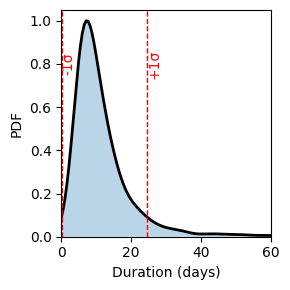

In [28]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ====== PATHS ======
day_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America"

# ====== READ DAY FILES ======
records = []

for fname in os.listdir(day_folder):
    if fname.lower().endswith(".xlsx") and "Day_" in fname:
        m = re.search(r"Day_(\d+)", fname)
        if not m:
            continue
        day = int(m.group(1))
        df_day = pd.read_excel(os.path.join(day_folder, fname))
        n_events = df_day["Event ID"].nunique()
        records.append((day, n_events))

df_counts = pd.DataFrame(records, columns=["day", "n_events"]).sort_values("day")

# ====== RECONSTRUCT DURATIONS ======
max_day = df_counts["day"].max()
survival = np.zeros(max_day + 2, dtype=int)

for d, n in zip(df_counts["day"], df_counts["n_events"]):
    survival[d] = n

durations = []
for d in range(1, max_day + 1):
    n_d = survival[d]
    n_next = survival[d + 1] if d + 1 <= max_day else 0
    durations.extend([d] * max(n_d - n_next, 0))

durations = np.array(durations)

# ====== KDE ======
kde = gaussian_kde(durations)
x = np.linspace(0, max_day + 1, 300)
pdf = kde(x)
pdf_scaled = pdf / pdf.max()

# ====== MEAN & SIGMA ======
mu = durations.mean()
sigma = durations.std()

left_1sigma = mu - sigma
right_1sigma = mu + sigma

print("Mean =", mu)
print("Sigma =", sigma)

# ====== PLOT ======
plt.figure(figsize=(3, 3))
plt.plot(x, pdf_scaled, linewidth=2, color="black")
plt.fill_between(x, 0, pdf_scaled, alpha=0.3)

# === 1-SIGMA LINES ===
plt.axvline(left_1sigma, color="red", linestyle="--", linewidth=1)
plt.axvline(right_1sigma, color="red", linestyle="--", linewidth=1)

plt.text(left_1sigma, 0.8, "-1σ", color="red", rotation=90, va="center")
plt.text(right_1sigma, 0.8, "+1σ", color="red", rotation=90, va="center")

plt.ylabel("PDF")
plt.xlabel("Duration (days)")

plt.xlim(0, 60)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()


In [54]:
import pandas as pd
import numpy as np

# ====== INPUT & OUTPUT ======
in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Daily_Summary_Continent.xlsx"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_km.xlsx"

# ====== READ DATA ======
df = pd.read_excel(in_file)

# Ensure sorting by date for each event
df = df.sort_values(["Event ID", "Date"])

# ====== HAVERSINE DISTANCE FUNCTION ======
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (np.sin(dlat / 2) ** 2 +
         np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# ====== COMPUTE FOR EACH EVENT ======
output = []

for eid, d in df.groupby("Event ID"):
    
    # ---- Start ----
    lat_s = d.iloc[0]["Latitude"]
    lon_s = d.iloc[0]["Longitude"]

    # ---- End ----
    lat_e = d.iloc[-1]["Latitude"]
    lon_e = d.iloc[-1]["Longitude"]

    # ---- Continent ----
    continent = d.iloc[0]["Continent"]  # same for entire event

    # ---- Distance ----
    dist_km = haversine(lat_s, lon_s, lat_e, lon_e)

    output.append([eid, continent, dist_km])

# ====== SAVE OUTPUT ======
out_df = pd.DataFrame(output, columns=["Event ID", "Continent", "Displacement_km"])
out_df.to_excel(out_file, index=False)

print("Saved displacement file to:")
print(out_file)


Saved displacement file to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_km.xlsx


In [57]:
import os
import shutil

base_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection"

# ==== VARIABLE PREFIX SUBFOLDER NAME ====
var_folders = {
    "air":  "Temperature",
    "uwnd": "UWind",
    "vwnd": "VWind",
    "shum": "SpecificHumidity"
}

# Years 
start_year = 1982
end_year   = 2019
target_years = set(range(start_year, end_year + 1))

var_years = {var: set() for var in var_folders.keys()}

# ==== CREATE SUBFOLDERS (IF THEY DON'T EXIST) ====
for var, folder_name in var_folders.items():
    out_dir = os.path.join(base_dir, folder_name)
    os.makedirs(out_dir, exist_ok=True)

# ==== SCAN FILES, MOVE THEM, AND RECORD YEARS ====
for fname in os.listdir(base_dir):
    if not fname.lower().endswith(".nc"):
        continue  # skip non-netcdf files

    # Example filename: "air.1982.nc"
    parts = fname.split(".")
    if len(parts) < 3:
        print(f"Skipping file with unexpected name format: {fname}")
        continue

    var_prefix = parts[0]   # e.g., "air", "uwnd", "vwnd", "shum"
    year_str   = parts[1]   # e.g., "1982"

        print(f"Unrecognized variable prefix, skipping: {fname}")
        continue

    # Parse year
    try:
        year = int(year_str)
    except ValueError:
        print(f"Could not parse year from {fname}, skipping.")
        continue

    # Record year for this variable
    var_years[var_prefix].add(year)

    # Move file into its corresponding subfolder
    src = os.path.join(base_dir, fname)
    dst_folder = os.path.join(base_dir, var_folders[var_prefix])
    dst = os.path.join(dst_folder, fname)


    shutil.move(src, dst)

# ==== CHECK FOR MISSING YEARS 1982–2019 ====
print("\nChecking years 1982–2019 for each variable:")
print("===========================================")




Checking years 1982–2019 for each variable:


In [58]:
import xarray as xr

# ====== FILE PATH ======
nc_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\SpecificHumidity\shum.1982.nc"

# ====== OPEN DATASET ======
ds = xr.open_dataset(nc_file)

# ====== PRINT BASIC INFO ======
print(ds)

# ====== PRINT VARIABLES ======
print("\nVariables:", list(ds.data_vars))

# ====== PRINT COORDINATES ======
print("\nCoordinates:", list(ds.coords))

# ====== SHOW FIRST FEW VALUES OF SPECIFIC HUMIDITY ======
var_name = list(ds.data_vars)[0]   # usually 'shum'
print("\nVariable head:")
print(ds[var_name].isel(time=0).values[:5, :5])  # first 5x5 grid at time=0


<xarray.Dataset> Size: 123MB
Dimensions:    (level: 8, lat: 73, lon: 144, time: 365, nbnds: 2)
Coordinates:
  * level      (level) float32 32B 1e+03 925.0 850.0 700.0 ... 500.0 400.0 300.0
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 3kB 1982-01-01 1982-01-02 ... 1982-12-31
Dimensions without coordinates: nbnds
Data variables:
    shum       (time, level, lat, lon) float32 123MB ...
    time_bnds  (time, nbnds) float64 6kB ...
Attributes:
    Conventions:    COARDS
    title:          mean daily NMC reanalysis (1982)
    description:    Data is from NMC initialized reanalysis\n(4x/day).  It co...
    platform:       Model
    history:        created 95/06/06 by Hoop (netCDF2.3)\nConverted to chunke...
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

Variables: ['shum'

In [59]:
print(ds.level.values)


[1000.  925.  850.  700.  600.  500.  400.  300.]


In [60]:
iimport os
import numpy as np
import xarray as xr

# ============================================================
# ROOT FOLDERS
# ============================================================
root = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection"

q_dir = os.path.join(root, "SpecificHumidity")   # shum.YYYY.nc
u_dir = os.path.join(root, "UWind")             # uwnd.YYYY.nc
v_dir = os.path.join(root, "VWind")             # vwnd.YYYY.nc

out_dir = os.path.join(root, "MoistureAdvection_850")
os.makedirs(out_dir, exist_ok=True)

# ============================================================
# CONSTANTS
# ============================================================
R = 6_371_000.0                # Earth radius (m)
deg2rad = np.pi / 180.0        # radians per degree


# ============================================================
# FUNCTION
# ============================================================
def compute_q_advection_850(year):
    """
    Compute horizontal specific-humidity advection at 850 hPa.

    Formula:
        q_adv = -(u * dq/dx + v * dq/dy)

    where:
        dq/dx = zonal specific-humidity gradient
        dq/dy = meridional specific-humidity gradient

    Output units:
        kg kg-1 s-1
    """

    print(f"Processing year {year}...")

    # --------------------------------------------------------
    # FILE PATHS
    # --------------------------------------------------------
    q_file = os.path.join(q_dir, f"shum.{year}.nc")
    u_file = os.path.join(u_dir, f"uwnd.{year}.nc")
    v_file = os.path.join(v_dir, f"vwnd.{year}.nc")

    # Check files exist
    for file in [q_file, u_file, v_file]:
        if not os.path.exists(file):
            raise FileNotFoundError(f"File not found: {file}")

    # --------------------------------------------------------
    # OPEN DATASETS
    # --------------------------------------------------------
    with (
        xr.open_dataset(q_file) as ds_q,
        xr.open_dataset(u_file) as ds_u,
        xr.open_dataset(v_file) as ds_v,
    ):

        # Variable names
        q_var = "shum"
        u_var = "uwnd"
        v_var = "vwnd"

        # ----------------------------------------------------
        # SELECT 850-hPa LEVEL
        # ----------------------------------------------------
        q850 = ds_q[q_var].sel(level=850)
        u850 = ds_u[u_var].sel(level=850)
        v850 = ds_v[v_var].sel(level=850)

        # ----------------------------------------------------
        # ALIGN TIME/LAT/LON COORDINATES
        # ----------------------------------------------------
        q850, u850, v850 = xr.align(
            q850,
            u850,
            v850,
            join="inner"
        )

        # ----------------------------------------------------
        # COORDINATES
        # ----------------------------------------------------
        lat = q850["lat"]

        # Latitude in radians
        phi = np.deg2rad(lat)

        # cos(latitude)
        cosphi = np.cos(phi)

        # ----------------------------------------------------
        # SPECIFIC-HUMIDITY GRADIENTS
        # ----------------------------------------------------
        # xarray differentiate() gives derivative with respect
        # to coordinate values, which are in degrees.
        #
        # Therefore:
        #     dqdlat = kg/kg per degree latitude
        #     dqdlon = kg/kg per degree longitude

        dqdlat = q850.differentiate("lat")
        dqdlon = q850.differentiate("lon")

        # ----------------------------------------------------
        # CONVERT FROM PER DEGREE TO PER METER
        # ----------------------------------------------------
        #
        # Meridional distance:
        #
        #     dy = R * dphi
        #
        # and
        #
        #     dphi = deg2rad * d(latitude degrees)
        #
        # Therefore:
        #
        #     dq/dy = (dq/dlat_degree) / (R * deg2rad)
        #
        # Zonal distance:
        #
        #     dx = R * cos(phi) * dlambda
        #
        # Therefore:
        #
        #     dq/dx =
        #     (dq/dlon_degree) /
        #     (R * cos(phi) * deg2rad)
        #

        dq_dy = dqdlat / (R * deg2rad)

        dq_dx = dqdlon / (
            R * cosphi * deg2rad
        )

        # ----------------------------------------------------
        # HORIZONTAL MOISTURE ADVECTION
        # ----------------------------------------------------
        #
        # Aq = -(u dq/dx + v dq/dy)
        #
        # Wind units:
        #     m s-1
        #
        # Gradient:
        #     kg kg-1 m-1
        #
        # Advection:
        #     kg kg-1 s-1
        #

        q_adv = -(
            u850 * dq_dx
            +
            v850 * dq_dy
        )

        q_adv.name = "q_adv_850"

        q_adv.attrs["long_name"] = (
            "Horizontal specific humidity advection at 850 hPa"
        )

        q_adv.attrs["standard_name"] = (
            "horizontal_specific_humidity_advection"
        )

        q_adv.attrs["units"] = "kg kg-1 s-1"

        q_adv.attrs["formula"] = (
            "-(u*dq/dx + v*dq/dy)"
        )

        q_adv.attrs["positive_values"] = (
            "Moisture advection increasing local specific humidity"
        )

        q_adv.attrs["negative_values"] = (
            "Dry-air advection decreasing local specific humidity"
        )

        # ----------------------------------------------------
        # OPTIONAL: PER-DAY VERSION
        # ----------------------------------------------------
        q_adv_day = q_adv * 86400.0

        q_adv_day.name = "q_adv_850_day"

        q_adv_day.attrs["long_name"] = (
            "Horizontal specific humidity advection at 850 hPa"
        )

        q_adv_day.attrs["units"] = "kg kg-1 day-1"

        q_adv_day.attrs["formula"] = (
            "-(u*dq/dx + v*dq/dy)"
        )

        # ----------------------------------------------------
        # LOAD RESULTS BEFORE SOURCE DATASETS CLOSE
        # ----------------------------------------------------
        q_adv = q_adv.load()
        q_adv_day = q_adv_day.load()

    # --------------------------------------------------------
    # BUILD OUTPUT DATASET
    # --------------------------------------------------------
    out_ds = xr.Dataset(
        {
            "q_adv_850": q_adv,
            "q_adv_850_day": q_adv_day,
        }
    )

    out_ds.attrs["description"] = (
        "850-hPa horizontal specific-humidity advection "
        "computed as -(u*dq/dx + v*dq/dy) from "
        "NCEP/NCAR Reanalysis 1."
    )

    out_ds.attrs["source_q"] = os.path.basename(q_file)
    out_ds.attrs["source_u"] = os.path.basename(u_file)
    out_ds.attrs["source_v"] = os.path.basename(v_file)

    out_ds.attrs["pressure_level"] = "850 hPa"

    out_ds.attrs["earth_radius_m"] = R

    return out_ds


# ============================================================
# LOOP OVER YEARS: 1982–2019
# ============================================================
for year in range(1982, 2020):

    out_ds = compute_q_advection_850(year)

    out_path = os.path.join(
        out_dir,
        f"q_adv_850_{year}.nc"
    )

    # Compression
    encoding = {
        "q_adv_850": {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        },
        "q_adv_850_day": {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        },
    }

    out_ds.to_netcdf(
        out_path,
        encoding=encoding
    )

    out_ds.close()

    print(f"Saved: {out_path}")


print("\nAll years completed successfully.")

Processing year 1982...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1982.nc
Processing year 1983...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1983.nc
Processing year 1984...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1984.nc
Processing year 1985...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1985.nc
Processing year 1986...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1986.nc
Processing year 1987...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1987.nc
Processing year 1988...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1988.nc
Processing year 1989...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1989.nc


In [61]:
import os
import numpy as np
import xarray as xr

# ============================================================
# ROOT FOLDERS
# ============================================================
root = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection"

T_dir = os.path.join(root, "Temperature")   # air.YYYY.nc
u_dir = os.path.join(root, "UWind")         # uwnd.YYYY.nc
v_dir = os.path.join(root, "VWind")         # vwnd.YYYY.nc

out_dir = os.path.join(root, "TempAdvection_850")
os.makedirs(out_dir, exist_ok=True)

# ============================================================
# CONSTANTS
# ============================================================
R = 6_371_000.0            # Earth radius (m)
deg2rad = np.pi / 180.0    # radians per degree


# ============================================================
# FUNCTION
# ============================================================
def compute_T_advection_850(year):
    """
    Compute 850-hPa horizontal temperature advection.

    Formula:
        T_adv = -(u * dT/dx + v * dT/dy)

    Output:
        T_adv_850      : K s-1
        T_adv_850_day  : K day-1
    """

    print(f"Processing year {year}...")

    # --------------------------------------------------------
    # FILE PATHS
    # --------------------------------------------------------
    T_file = os.path.join(T_dir, f"air.{year}.nc")
    u_file = os.path.join(u_dir, f"uwnd.{year}.nc")
    v_file = os.path.join(v_dir, f"vwnd.{year}.nc")

    # Check that all files exist
    for f in [T_file, u_file, v_file]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing file: {f}")

    # --------------------------------------------------------
    # OPEN DATASETS
    # --------------------------------------------------------
    with (
        xr.open_dataset(T_file) as ds_T,
        xr.open_dataset(u_file) as ds_u,
        xr.open_dataset(v_file) as ds_v,
    ):

        # Variable names
        T_var = "air"
        u_var = "uwnd"
        v_var = "vwnd"

        # ----------------------------------------------------
        # SELECT 850 hPa
        # ----------------------------------------------------
        T850 = ds_T[T_var].sel(level=850)
        u850 = ds_u[u_var].sel(level=850)
        v850 = ds_v[v_var].sel(level=850)

        # ----------------------------------------------------
        # ALIGN TIME / LAT / LON
        # ----------------------------------------------------
        T850, u850, v850 = xr.align(
            T850,
            u850,
            v850,
            join="inner"
        )

        # ----------------------------------------------------
        # LATITUDE METRIC
        # ----------------------------------------------------
        lat = T850["lat"]

        phi = np.deg2rad(lat)
        cosphi = np.cos(phi)

        # ----------------------------------------------------
        # TEMPERATURE GRADIENTS
        # ----------------------------------------------------
        # xarray differentiate() gives:
        #
        # dTdlat = K per degree latitude
        # dTdlon = K per degree longitude

        dTdlat = T850.differentiate("lat")
        dTdlon = T850.differentiate("lon")

        # ----------------------------------------------------
        # CORRECT DEGREE -> METER CONVERSION
        # ----------------------------------------------------
        #
        # 1 degree latitude =
        # R * (pi / 180) meters
        #
        # Therefore:
        #
        # dT/dy = dT/d(degree latitude)
        #         / [R * pi/180]
        #
        # dT/dx = dT/d(degree longitude)
        #         / [R * cos(phi) * pi/180]
        #

        dT_dy = dTdlat / (R * deg2rad)

        dT_dx = dTdlon / (
            R * cosphi * deg2rad
        )

        # ----------------------------------------------------
        # HORIZONTAL TEMPERATURE ADVECTION
        # ----------------------------------------------------
        #
        # A_T = -(u dT/dx + v dT/dy)
        #
        # Positive = warm-air advection
        # Negative = cold-air advection
        #

        T_adv = -(
            u850 * dT_dx
            +
            v850 * dT_dy
        )

        T_adv.name = "T_adv_850"

        T_adv.attrs["long_name"] = (
            "Horizontal temperature advection at 850 hPa"
        )

        T_adv.attrs["units"] = "K s-1"

        T_adv.attrs["formula"] = (
            "-(u*dT/dx + v*dT/dy)"
        )

        T_adv.attrs["interpretation"] = (
            "Positive values indicate warm-air advection; "
            "negative values indicate cold-air advection."
        )

        # ----------------------------------------------------
        # CONVERT TO K / DAY
        # ----------------------------------------------------
        T_adv_day = T_adv * 86400.0

        T_adv_day.name = "T_adv_850_day"

        T_adv_day.attrs["long_name"] = (
            "Horizontal temperature advection at 850 hPa"
        )

        T_adv_day.attrs["units"] = "K day-1"

        T_adv_day.attrs["formula"] = (
            "-(u*dT/dx + v*dT/dy)"
        )

        T_adv_day.attrs["interpretation"] = (
            "Positive values indicate warm-air advection; "
            "negative values indicate cold-air advection."
        )

        # Important:
        # load before source files are closed
        T_adv = T_adv.load()
        T_adv_day = T_adv_day.load()

    # --------------------------------------------------------
    # OUTPUT DATASET
    # --------------------------------------------------------
    out_ds = xr.Dataset(
        {
            "T_adv_850": T_adv,
            "T_adv_850_day": T_adv_day,
        }
    )

    out_ds.attrs["description"] = (
        "850-hPa horizontal temperature advection "
        "computed from NCEP/NCAR Reanalysis 1 as "
        "-(u*dT/dx + v*dT/dy)."
    )

    out_ds.attrs["source_T"] = os.path.basename(T_file)
    out_ds.attrs["source_u"] = os.path.basename(u_file)
    out_ds.attrs["source_v"] = os.path.basename(v_file)

    out_ds.attrs["pressure_level"] = "850 hPa"
    out_ds.attrs["earth_radius_m"] = R

    return out_ds


# ============================================================
# LOOP OVER YEARS: 1982–2019
# ============================================================
for year in range(1982, 2020):

    out_ds = compute_T_advection_850(year)

    out_path = os.path.join(
        out_dir,
        f"T_adv_850_{year}.nc"
    )

    # Optional compression
    encoding = {
        "T_adv_850": {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        },
        "T_adv_850_day": {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        },
    }

    out_ds.to_netcdf(
        out_path,
        encoding=encoding
    )

    out_ds.close()

    print(f"Saved: {out_path}")


print("\nAll years 1982–2019 completed successfully.")

Processing year 1982...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1982.nc
Processing year 1983...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1983.nc
Processing year 1984...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1984.nc
Processing year 1985...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1985.nc
Processing year 1986...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1986.nc
Processing year 1987...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1987.nc
Processing year 1988...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1988.nc
Processing year 1989...
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1989.nc
Processing year 1990...
Saved: D

In [62]:
import xarray as xr
import os

# ---------- Input folder ----------
folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850"

# Pattern to match all yearly files
pattern = os.path.join(folder, "q_adv_850_*.nc")

# ---------- Open and combine ----------
ds_merged = xr.open_mfdataset(
    pattern,
    combine='by_coords',
    parallel=True
)

# ---------- Output file ----------
out_file = os.path.join(folder, "q_adv_850_1982_2019.nc")

ds_merged.to_netcdf(out_file)

print("Combined dataset saved at:")
print(out_file)


Combined dataset saved at:
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1982_2019.nc


In [63]:
import xarray as xr
import os

# ---------- Input folder ----------
folder_T = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850"

# Match all yearly temp-advection files
pattern_T = os.path.join(folder_T, "T_adv_850_*.nc")

# ---------- Open and merge ----------
ds_T_merged = xr.open_mfdataset(
    pattern_T,
    combine="by_coords",
    parallel=True
)

# ---------- Output file ----------
out_T_file = os.path.join(folder_T, "T_adv_850_1982_2019.nc")
ds_T_merged.to_netcdf(out_T_file)

print("Combined temperature-advection dataset saved at:")
print(out_T_file)


Combined temperature-advection dataset saved at:
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1982_2019.nc


In [65]:
import xarray as xr

# ======= INPUT & OUTPUT FILES =======
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\NCEP_coupling_p_daily_1982_2019.nc"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\NCEP_coupling_p_daily_anom_1982_2019.nc"

# ======= OPEN FILE =======
ds = xr.open_dataset(in_file)

# extract variable p
p = ds["p"]

# ======= DAILY CLIMATOLOGY =======
# mean value for each calendar day (1–365)
p_clim = p.groupby("time.dayofyear").mean("time")

# ======= DAILY ANOMALIES =======
p_anom = p.groupby("time.dayofyear") - p_clim

# ======= SAVE TO NEW NETCDF =======
ds_out = xr.Dataset(
    {"p_anom": p_anom},
    coords={"time": ds.time, "lat": ds.lat, "lon": ds.lon}
)

ds_out.to_netcdf(out_file)

print("Saved anomalies to:")
print(out_file)


Saved anomalies to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\NCEP_coupling_p_daily_anom_1982_2019.nc


In [68]:
import xarray as xr

# ====== INPUT & OUTPUT ======
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_1982_2019.nc"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_daily_anom_1982_2019.nc"

# ====== OPEN DATASET ======
ds = xr.open_dataset(in_file)

# variable: q_adv_850 (time, lat, lon)
qadv = ds["q_adv_850"]

# ====== DAILY CLIMATOLOGY (BY DAY OF YEAR) ======
qadv_clim = qadv.groupby("time.dayofyear").mean("time")

# ====== DAILY ANOMALIES ======
qadv_anom = qadv.groupby("time.dayofyear") - qadv_clim

# optional: name & attrs
qadv_anom.name = "q_adv_850_anom"
qadv_anom.attrs["long_name"] = "daily anomaly of 850-hPa specific humidity advection"
qadv_anom.attrs["note"] = "anomaly relative to 1982–2019 daily climatology by day-of-year"

# ====== SAVE TO NETCDF ======
ds_out = xr.Dataset(
    {"q_adv_850_anom": qadv_anom},
    coords={"time": ds.time, "lat": ds.lat, "lon": ds.lon, "level": ds.level}
)

ds_out.to_netcdf(out_file)

print("Saved daily anomalies to:")
print(out_file)


Saved daily anomalies to:
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\MoistureAdvection_850\q_adv_850_daily_anom_1982_2019.nc


In [69]:
import xarray as xr

# ====== INPUT & OUTPUT ======
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_1982_2019.nc"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_daily_anom_1982_2019.nc"

# ====== OPEN DATASET ======
ds = xr.open_dataset(in_file)

# Variables inside:
#   T_adv_850 (time, lat, lon)
#   T_adv_850_day (time, lat, lon)

Tadv  = ds["T_adv_850"]
Tadv_day = ds["T_adv_850_day"]

# ====== DAILY CLIMATOLOGY ======
# mean of all years for each day-of-year (1..365/366)
Tadv_clim = Tadv.groupby("time.dayofyear").mean("time")
Tadv_day_clim = Tadv_day.groupby("time.dayofyear").mean("time")

# ====== DAILY ANOMALIES ======
Tadv_anom = Tadv.groupby("time.dayofyear") - Tadv_clim
Tadv_day_anom = Tadv_day.groupby("time.dayofyear") - Tadv_day_clim

# Assign attributes and names
Tadv_anom.name = "T_adv_850_anom"
Tadv_day_anom.name = "T_adv_850_day_anom"

Tadv_anom.attrs["description"] = "Daily anomaly of 850-hPa temperature advection"
Tadv_day_anom.attrs["description"] = "Daily anomaly of 850-hPa (daily-filtered) temperature advection"

# ====== SAVE OUTPUT ======
ds_out = xr.Dataset(
    {
        "T_adv_850_anom": Tadv_anom,
        "T_adv_850_day_anom": Tadv_day_anom
    },
    coords={"time": ds.time, "lat": ds.lat, "lon": ds.lon, "level": ds.level}
)

ds_out.to_netcdf(out_file)

print("\nSaved daily anomalies to:")
print(out_file)



Saved daily anomalies to:
D:\PhD_Research\Paper-3_CHDW_Migration\Data\Advection\TempAdvection_850\T_adv_850_daily_anom_1982_2019.nc


In [70]:
# -*- coding: utf-8 -*-
"""
Add continent info to each event based on starting latitude/longitude.

Input : Event_Displacement_Summary.xlsx
Output: Event_Displacement_Summary_with_continent.xlsx
"""

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os

# ---------------------------------------------------------------------
# 1. Paths 
# ---------------------------------------------------------------------
input_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary.xlsx"
output_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent.xlsx"

# ---------------------------------------------------------------------
# 2. Read the Excel
# ---------------------------------------------------------------------
df = pd.read_excel(input_file)

# Make sure the column names are exactly these; if not, adjust here
# Expected columns:
# "Event ID", "Duration", "Starting Latitude", "Ending Latitude",
# "Starting Longitude", "Ending Longitude"

print("Columns in file:", df.columns.tolist())

# ---------------------------------------------------------------------
# 3. Build GeoDataFrame with starting point
# ---------------------------------------------------------------------
# GeoPandas expects lon (x), lat (y)
gdf_events = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["Starting Longitude"], df["Starting Latitude"]),
    crs="EPSG:4326"   # WGS84
)

# ---------------------------------------------------------------------
# 4. Load world polygons (Natural Earth) and keep only continent + geometry
# ---------------------------------------------------------------------
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
world = world[["continent", "geometry"]]

# ---------------------------------------------------------------------
# 5. Spatial join: assign continent where the starting point falls
# ---------------------------------------------------------------------
# predicate="within" works for points inside polygons
gdf_joined = gpd.sjoin(
    gdf_events,
    world,
    how="left",
    predicate="within"
)

# gdf_joined now has a "continent" column from 'world'
df_out = pd.DataFrame(gdf_joined.drop(columns=["geometry", "index_right"]))

df_out.rename(columns={"continent": "Continent"}, inplace=True)

# ---------------------------------------------------------------------
# 6. Save to new Excel
# ---------------------------------------------------------------------
df_out.to_excel(output_file, index=False)
print(f"Saved file with continent column to:\n{output_file}")

# ---------------------------------------------------------------------
# 7. (Optional) Quick check: show how many events per continent
# ---------------------------------------------------------------------
print("\nEvent counts by continent:")
print(df_out["Continent"].value_counts(dropna=False))


Columns in file: ['Event ID', 'Duration', 'Starting Latitude', 'Ending Latitude', 'Starting Longitude', 'Ending Longitude']


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_25900\739067605.py:45: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


Saved file with continent column to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent.xlsx

Event counts by continent:
Continent
Africa           561
Asia             538
Europe           501
South America    453
North America    421
Oceania           96
NaN               13
Name: count, dtype: int64


In [71]:
nan_events = df_out[df_out["Continent"].isna()]
print(nan_events[["Event ID", "Starting Latitude", "Starting Longitude"]])


      Event ID  Starting Latitude  Starting Longitude
31         280         -34.115546          -58.392409
1135      7930          22.000000           31.657233
1139      7939          26.809859           34.809859
1419      9728          30.000000          122.000000
1688     11292          40.000000           16.898492
1714     11426          46.389492           51.377933
2254     14609          62.988466          -81.440600
2258     14613          59.186630          -68.373259
2335     14944          63.187770          -76.106475
2381     15141          62.000000          163.173848
2433     15300          64.000000          -83.229268
2435     15310          63.898279          -73.767606
2526     15860          64.876048          -86.774775


In [72]:
import numpy as np
import pandas as pd

# ---------- 1. Haversine distance ----------
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    r = 6371.0  # km
    return c * r

# ---------- 2. Bearing (0° = East, 90° = North, 180° = West, 270° = South) ----------
def calculate_bearing_cartesian(lat1, lon1, lat2, lon2):
    # no movement
    if (lat1 == lat2) and (lon1 == lon2):
        return np.nan

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    initial_bearing = np.arctan2(x, y)          # 0° = North, clockwise
    initial_bearing = np.degrees(initial_bearing)

    # convert to 0° = East, counter-clockwise
    compass_bearing = (90 - initial_bearing) % 360
    return compass_bearing

# ---------- 3. Read file ----------
df = pd.read_excel(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent.xlsx"
)

# ---------- 4. Distance & bearing ----------
df["Distance"] = df.apply(
    lambda x: haversine(x["Starting Longitude"], x["Starting Latitude"],
                        x["Ending Longitude"],   x["Ending Latitude"]),
    axis=1
)

df["Bearing"] = df.apply(
    lambda x: calculate_bearing_cartesian(x["Starting Latitude"], x["Starting Longitude"],
                                          x["Ending Latitude"],   x["Ending Longitude"]),
    axis=1
)

# ---------- 5. Map bearing → 4 directions (E, N, W, S) ----------
def bearing_to_4dir(b):
    if np.isnan(b):
        return "NoMove"
    # 0° = East; 90° = North; 180° = West; 270° = South
    if (b >= 315) or (b < 45):
        return "E"
    elif 45 <= b < 135:
        return "N"
    elif 135 <= b < 225:
        return "W"
    else:  # 225–315
        return "S"

df["Direction4"] = df["Bearing"].apply(bearing_to_4dir)

# ---------- 6. Save back ----------
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4.xlsx"
df.to_excel(out_file, index=False)
print("Saved:", out_file)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4.xlsx


In [81]:
import numpy as np
import pandas as pd

# ---------- 1. Haversine distance ----------
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    r = 6371.0  # km
    return c * r

# ---------- 2. Bearing (0° = East, 90° = North, 180° = West, 270° = South) ----------
def calculate_bearing_cartesian(lat1, lon1, lat2, lon2):
    # no movement
    if (lat1 == lat2) and (lon1 == lon2):
        return np.nan

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    initial_bearing = np.arctan2(x, y)          # 0° = North, clockwise
    initial_bearing = np.degrees(initial_bearing)

    # convert to 0° = East, counter-clockwise
    compass_bearing = (90 - initial_bearing) % 360
    return compass_bearing

# ---------- 3. Read file ----------
df = pd.read_excel(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent.xlsx"
)

# ---------- 4. Distance & bearing ----------
df["Distance"] = df.apply(
    lambda x: haversine(x["Starting Longitude"], x["Starting Latitude"],
                        x["Ending Longitude"],   x["Ending Latitude"]),
    axis=1
)

df["Bearing"] = df.apply(
    lambda x: calculate_bearing_cartesian(x["Starting Latitude"], x["Starting Longitude"],
                                          x["Ending Latitude"],   x["Ending Longitude"]),
    axis=1
)

# ---------- 5a. Map bearing → 4 directions (E, N, W, S) ----------
def bearing_to_4dir(b):
    if np.isnan(b):
        return "NoMove"
    # 0° = East; 90° = North; 180° = West; 270° = South
    if (b >= 315) or (b < 45):
        return "E"
    elif 45 <= b < 135:
        return "N"
    elif 135 <= b < 225:
        return "W"
    else:  # 225–315
        return "S"

df["Direction4"] = df["Bearing"].apply(bearing_to_4dir)

# ---------- 5b. Map bearing → 8 directions (E, NE, N, NW, W, SW, S, SE) ----------
def assign_direction_8(b):
    """
    Convert bearing (0°=East, 90°=North) into 8 directions:
    E, NE, N, NW, W, SW, S, SE
    """
    if pd.isna(b):
        return "NoMove"

    if (b >= 337.5) or (b < 22.5):
        return "E"
    elif 22.5 <= b < 67.5:
        return "NE"
    elif 67.5 <= b < 112.5:
        return "N"
    elif 112.5 <= b < 157.5:
        return "NW"
    elif 157.5 <= b < 202.5:
        return "W"
    elif 202.5 <= b < 247.5:
        return "SW"
    elif 247.5 <= b < 292.5:
        return "S"
    elif 292.5 <= b < 337.5:
        return "SE"
    else:
        return "Unknown"

df["Direction8"] = df["Bearing"].apply(assign_direction_8)

# ---------- 6. Save back ----------
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4_8.xlsx"
df.to_excel(out_file, index=False)
print("Saved:", out_file)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4_8.xlsx


In [77]:
import pandas as pd
import numpy as np

# ===== LOAD FILE =====
file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4.xlsx"
df = pd.read_excel(file)

# ===== CLEAN COLUMN NAMES =====
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Now duration column will be: df["duration"]
if "duration" not in df.columns:
    raise ValueError(f"Duration column not found! Columns available: {df.columns.tolist()}")

# Ensure numeric
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

# ===== FUNCTION FOR 70% RANGE =====
def compute_70pct_range(series):
    p15 = np.percentile(series, 15)
    p85 = np.percentile(series, 85)
    return p15, p85

print("\n===== 70% Duration Range by Continent =====\n")

for cont in df["continent"].unique():
    sub = df[df["continent"] == cont]["duration"].dropna()

    median_dur = sub.median()
    p15, p85 = compute_70pct_range(sub)

    print(f"Continent: {cont}")
    print(f"   Total events        : {len(sub)}")
    print(f"   Median duration     : {median_dur:.2f} days")
    print(f"   70% duration range  : {p15:.1f} → {p85:.1f} days")
    print(f"   Rounded range       : {int(round(p15))} – {int(round(p85))} days")
    print(f"   Median ±1 day range : {int(median_dur-1)} – {int(median_dur+1)} days\n")



===== 70% Duration Range by Continent =====

Continent: Africa
   Total events        : 528
   Median duration     : 11.00 days
   70% duration range  : 6.0 → 22.0 days
   Rounded range       : 6 – 22 days
   Median ±1 day range : 10 – 12 days

Continent: Asia
   Total events        : 512
   Median duration     : 9.00 days
   70% duration range  : 6.0 → 17.0 days
   Rounded range       : 6 – 17 days
   Median ±1 day range : 8 – 10 days

Continent: Europe
   Total events        : 495
   Median duration     : 7.00 days
   70% duration range  : 5.0 → 14.0 days
   Rounded range       : 5 – 14 days
   Median ±1 day range : 6 – 8 days

Continent: North America
   Total events        : 421
   Median duration     : 7.00 days
   70% duration range  : 5.0 → 13.0 days
   Rounded range       : 5 – 13 days
   Median ±1 day range : 6 – 8 days

Continent: Oceania
   Total events        : 89
   Median duration     : 8.00 days
   70% duration range  : 5.0 → 13.0 days
   Rounded range       : 5 – 13 da

Total NA events: 421
Cluster
0    158
1    182
2     81
Name: count, dtype: int64


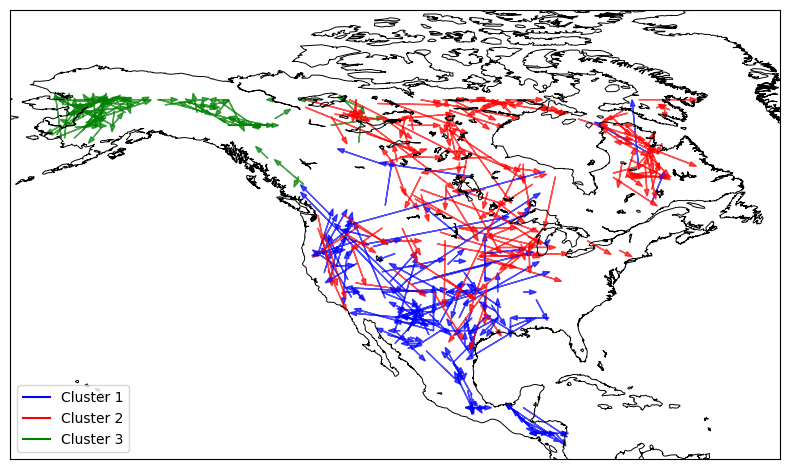

Clustered NA events saved to:
 D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx


In [178]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# =========================
# PATHS
# =========================
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Summary_with_continent_dir4_8.xlsx"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx"

# =========================
# LOAD DATA
# =========================
df = pd.read_excel(in_file)


df.columns = df.columns.str.strip()

# =========================
# SUBSET TO NORTH AMERICA ONLY
# =========================
df_na = df[df["Continent"] == "North America"].copy()
print("Total NA events:", len(df_na))

# =========================
# BUILD FEATURES: spatial + direction
#   - Starting lat, lon
#   - Horizontal movement components (u east, v north)
#     from Distance + Bearing
# =========================

# Ensure numeric
for col in ["Starting Latitude", "Starting Longitude", "Ending Latitude",
            "Ending Longitude", "Distance", "Bearing"]:
    df_na[col] = pd.to_numeric(df_na[col], errors="coerce")

# Compute movement components in km
# Bearing is clockwise from north:
#   v (north) = D * cos(theta)
#   u (east)  = D * sin(theta)
theta = np.deg2rad(df_na["Bearing"].values)
D     = df_na["Distance"].values

u_east  = D * np.sin(theta)   # +ve eastward, -ve westward
v_north = D * np.cos(theta)   # +ve northward, -ve southward

df_na["u_east_km"]  = u_east
df_na["v_north_km"] = v_north

# Feature matrix: location + vector
feature_cols = ["Starting Latitude", "Starting Longitude",
                "u_east_km", "v_north_km"]
X = df_na[feature_cols].values

# =========================
# STANDARDIZE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# K-MEANS CLUSTERING
# =========================
n_clusters = 3  # change to 4,5,... 
kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
df_na["Cluster"] = kmeans.fit_predict(X_scaled)

print(df_na["Cluster"].value_counts().sort_index())

# =========================
# PLOT ON MAP
# =========================
colors = {0: "blue", 1:"red" , 2: "green", 3: "orange", 4: "purple"}

plt.figure(figsize=(8, 6))
m = Basemap(
    projection="cyl",
    llcrnrlon=-170, urcrnrlon=-50,
    llcrnrlat=10,   urcrnrlat=80,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)

for _, row in df_na.iterrows():
    slat = row["Starting Latitude"]
    slon = row["Starting Longitude"]
    elat = row["Ending Latitude"]
    elon = row["Ending Longitude"]
    c    = int(row["Cluster"])

    col = colors[c]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    # straight arrow from start to end
    plt.arrow(xs, ys, xe - xs, ye - ys,
              color=col, alpha=0.7, linewidth=1,
              head_width=0.7)

# legend
for c in range(n_clusters):
    plt.plot([], [], color=colors[c], label=f"Cluster {c+1}")

plt.legend(loc="lower left")

plt.tight_layout()


plt.savefig(r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\NA-1.png",
            dpi=300, transparent=True, bbox_inches='tight')

plt.show()

# =========================
# SAVE CLUSTERED TABLE
# =========================
df_na.to_excel(out_file, index=False)
print("Clustered NA events saved to:\n", out_file)

Total events in file: 2477
Total North America events: 421
North America events after removing missing values: 421

Cluster validation metrics:
   K      Inertia  Silhouette_Score  Calinski_Harabasz_Score  \
0  2  1288.155293          0.274449               128.756939   
1  3   986.371429          0.292184               147.818932   
2  4   835.680269          0.310794               141.102341   
3  5   735.371697          0.312376               134.159832   
4  6   642.733619          0.318557               134.464896   
5  7   574.126862          0.333561               133.387325   
6  8   527.062179          0.301377               129.509068   

   Davies_Bouldin_Score  
0              1.164364  
1              1.294088  
2              1.248455  
3              1.255650  
4              1.151442  
5              1.077793  
6              1.098125  

Validation metrics saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\KMeans_Cluster_Va

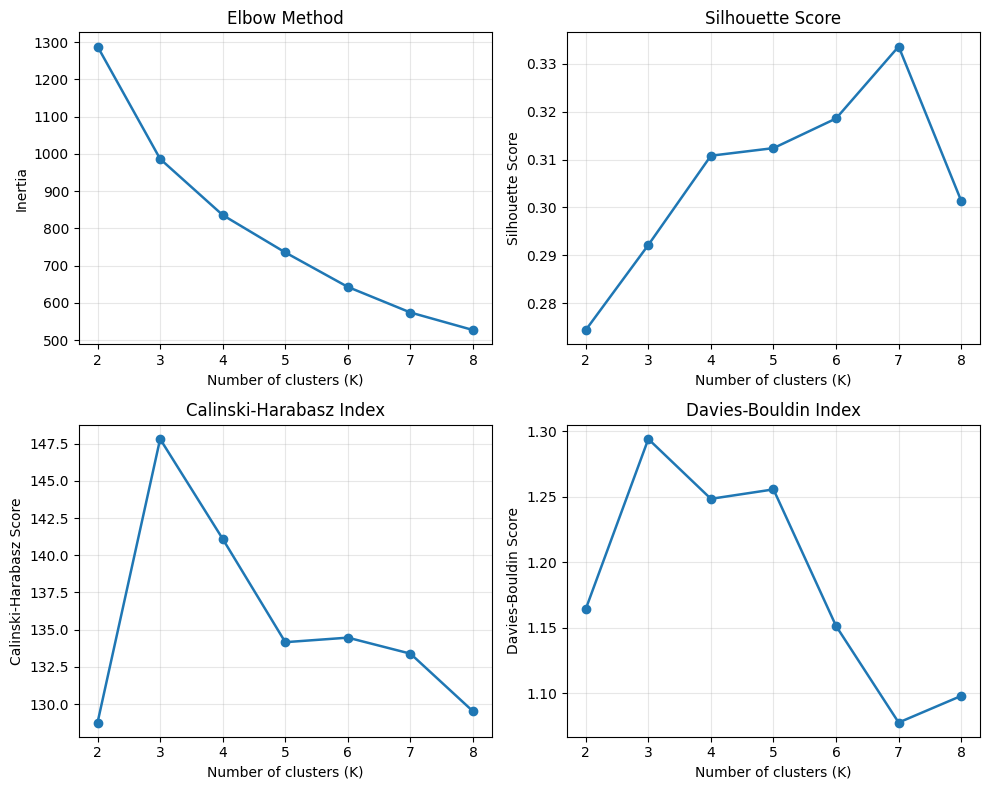


Validation plot saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\KMeans_Cluster_Validation.png

Final cluster counts:
Cluster_Label
1    158
2    182
3     81
Name: count, dtype: int64

Clustered North America events saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx


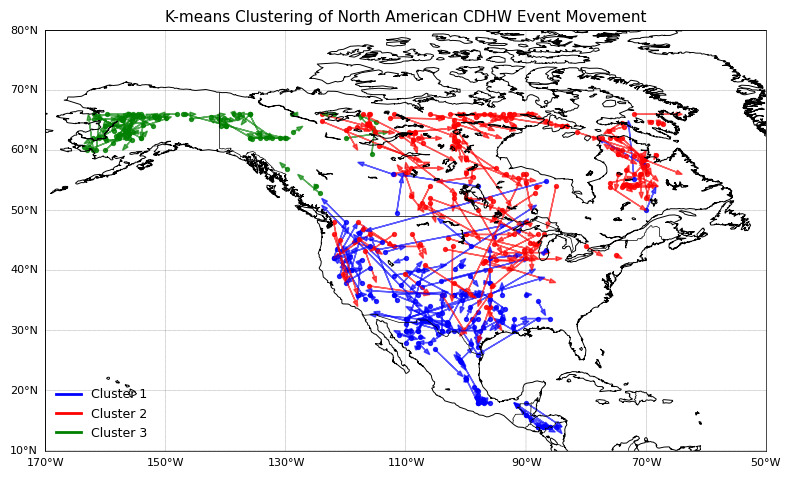


Final cluster map saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\NA_DirSpace_KMeans_Clusters_K3.png


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from mpl_toolkits.basemap import Basemap


# ============================================================
# PATHS
# ============================================================

in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_Summary_with_continent_dir4_8.xlsx"

out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx"

plot_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots"
os.makedirs(plot_dir, exist_ok=True)

validation_metrics_file = os.path.join(
    plot_dir,
    "KMeans_Cluster_Validation_Metrics.xlsx"
)

validation_plot_file = os.path.join(
    plot_dir,
    "KMeans_Cluster_Validation.png"
)

map_plot_file = os.path.join(
    plot_dir,
    "NA_DirSpace_KMeans_Clusters_K3.png"
)


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel(in_file)

# Clean column names
df.columns = df.columns.str.strip()

print("Total events in file:", len(df))


# ============================================================
# SUBSET TO NORTH AMERICA ONLY
# ============================================================

df_na = df[df["Continent"] == "North America"].copy()

print("Total North America events:", len(df_na))


# ============================================================
# MAKE REQUIRED COLUMNS NUMERIC
# ============================================================

required_cols = [
    "Starting Latitude",
    "Starting Longitude",
    "Ending Latitude",
    "Ending Longitude",
    "Distance",
    "Bearing"
]

for col in required_cols:
    df_na[col] = pd.to_numeric(df_na[col], errors="coerce")


# ============================================================
# COMPUTE MOVEMENT COMPONENTS
# Bearing is clockwise from north:
#   u_east  = Distance * sin(theta)
#   v_north = Distance * cos(theta)
# ============================================================

theta = np.deg2rad(df_na["Bearing"])
D = df_na["Distance"]

df_na["u_east_km"] = D * np.sin(theta)
df_na["v_north_km"] = D * np.cos(theta)


# ============================================================
# BUILD FEATURE MATRIX
# Location + movement direction/magnitude
# ============================================================

feature_cols = [
    "Starting Latitude",
    "Starting Longitude",
    "u_east_km",
    "v_north_km"
]

# Drop rows with missing feature values
df_na = df_na.dropna(subset=feature_cols).copy()

print("North America events after removing missing values:", len(df_na))

X = df_na[feature_cols].values


# ============================================================
# STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# CLUSTER VALIDATION FOR K = 2 TO 8
# ============================================================

K_range = range(2, 9)

inertia_list = []
silhouette_list = []
calinski_list = []
davies_list = []

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        n_init=50,
        random_state=42
    )

    labels_temp = kmeans_temp.fit_predict(X_scaled)

    inertia_list.append(kmeans_temp.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels_temp))
    calinski_list.append(calinski_harabasz_score(X_scaled, labels_temp))
    davies_list.append(davies_bouldin_score(X_scaled, labels_temp))


cluster_metrics = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia_list,
    "Silhouette_Score": silhouette_list,
    "Calinski_Harabasz_Score": calinski_list,
    "Davies_Bouldin_Score": davies_list
})

print("\nCluster validation metrics:")
print(cluster_metrics)

cluster_metrics.to_excel(validation_metrics_file, index=False)

print("\nValidation metrics saved to:")
print(validation_metrics_file)


# ============================================================
# PLOT CLUSTER VALIDATION METRICS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Elbow method
axes[0, 0].plot(
    cluster_metrics["K"],
    cluster_metrics["Inertia"],
    marker="o",
    linewidth=1.8
)
axes[0, 0].set_xlabel("Number of clusters (K)")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_title("Elbow Method")
axes[0, 0].grid(alpha=0.3)

# Silhouette score
axes[0, 1].plot(
    cluster_metrics["K"],
    cluster_metrics["Silhouette_Score"],
    marker="o",
    linewidth=1.8
)
axes[0, 1].set_xlabel("Number of clusters (K)")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].grid(alpha=0.3)

# Calinski-Harabasz score
axes[1, 0].plot(
    cluster_metrics["K"],
    cluster_metrics["Calinski_Harabasz_Score"],
    marker="o",
    linewidth=1.8
)
axes[1, 0].set_xlabel("Number of clusters (K)")
axes[1, 0].set_ylabel("Calinski-Harabasz Score")
axes[1, 0].set_title("Calinski-Harabasz Index")
axes[1, 0].grid(alpha=0.3)

# Davies-Bouldin score
axes[1, 1].plot(
    cluster_metrics["K"],
    cluster_metrics["Davies_Bouldin_Score"],
    marker="o",
    linewidth=1.8
)
axes[1, 1].set_xlabel("Number of clusters (K)")
axes[1, 1].set_ylabel("Davies-Bouldin Score")
axes[1, 1].set_title("Davies-Bouldin Index")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    validation_plot_file,
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

print("\nValidation plot saved to:")
print(validation_plot_file)


# ============================================================
# FINAL K-MEANS CLUSTERING
# Selected K = 3 based on balance between validation metrics
# and physical interpretability
# ============================================================

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    n_init=50,
    random_state=42
)

df_na["Cluster"] = kmeans.fit_predict(X_scaled)

# Make cluster labels start from 1 instead of 0
df_na["Cluster_Label"] = df_na["Cluster"] + 1

print("\nFinal cluster counts:")
print(df_na["Cluster_Label"].value_counts().sort_index())


# ============================================================
# SAVE CLUSTERED TABLE
# ============================================================

df_na.to_excel(out_file, index=False)

print("\nClustered North America events saved to:")
print(out_file)


# ============================================================
# PLOT FINAL CLUSTERS ON MAP
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green",
    3: "orange",
    4: "purple",
    5: "brown",
    6: "magenta",
    7: "cyan"
}

plt.figure(figsize=(8, 6))

m = Basemap(
    projection="cyl",
    llcrnrlon=-170,
    urcrnrlon=-50,
    llcrnrlat=10,
    urcrnrlat=80,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)
m.drawcountries(linewidth=0.5)
m.drawmapboundary(linewidth=0.5)

# Optional: draw parallels and meridians
m.drawparallels(
    np.arange(10, 81, 10),
    labels=[1, 0, 0, 0],
    linewidth=0.2,
    fontsize=8
)

m.drawmeridians(
    np.arange(-170, -49, 20),
    labels=[0, 0, 0, 1],
    linewidth=0.2,
    fontsize=8
)

for _, row in df_na.iterrows():

    slat = row["Starting Latitude"]
    slon = row["Starting Longitude"]
    elat = row["Ending Latitude"]
    elon = row["Ending Longitude"]
    c = int(row["Cluster"])

    col = colors[c]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    # Arrow from start to end
    plt.arrow(
        xs,
        ys,
        xe - xs,
        ye - ys,
        color=col,
        alpha=0.65,
        linewidth=1.0,
        head_width=0.7,
        head_length=1.0,
        length_includes_head=True
    )

    # Optional: starting point
    plt.scatter(
        xs,
        ys,
        s=8,
        color=col,
        alpha=0.8
    )


# Legend
for c in range(n_clusters):
    plt.plot(
        [],
        [],
        color=colors[c],
        linewidth=2,
        label=f"Cluster {c + 1}"
    )

plt.legend(
    loc="lower left",
    frameon=False,
    fontsize=9
)

plt.title(
    "K-means Clustering of North American CDHW Event Movement",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    map_plot_file,
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

print("\nFinal cluster map saved to:")
print(map_plot_file)

Total events: 182
Kept after direction filter: 54


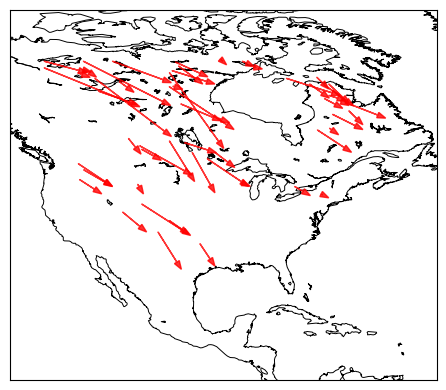

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ============================================================
# 1. LOAD EVENT MIGRATION FILE
# ============================================================
file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx"
df = pd.read_excel(file)

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Direction column
direction_col = "direction8" if "direction8" in df.columns else "direction4"

# ======== USER CLUSTER DIRECTION FILTER ========
cluster_dir_map = {1: "SE"}  
df = df[df["cluster"].isin(cluster_dir_map.keys())]

df["keep_flag"] = df.apply(
    lambda r: r[direction_col] == cluster_dir_map[r["cluster"]],
    axis=1
)
df_keep = df[df["keep_flag"]]

print("Total events:", len(df))
print("Kept after direction filter:", len(df_keep))

# ============================================================
# 2. SETUP BASEMAP PLOT
# ============================================================
plt.figure(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-130, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)

# ============================================================
# 3. EVENT MIGRATION ARROWS (red)
# ============================================================
for _, row in df_keep.iterrows():
    slon = row["starting longitude"]
    slat = row["starting latitude"]
    elon = row["ending longitude"]
    elat = row["ending latitude"]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    plt.arrow(xs, ys, xe - xs, ye - ys,
              length_includes_head=True,
              head_width=1.0,
              head_length=1.5,
              color="red",
              alpha=0.8,
              zorder=15)   # red arrows on top



# ============================================================
# 5. SAVE & SHOW
# ============================================================
plt.tight_layout()
plt.savefig(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\NA_drought_event_combined.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()


Total events in cluster 1: 182
Kept with directions SE or E: 89


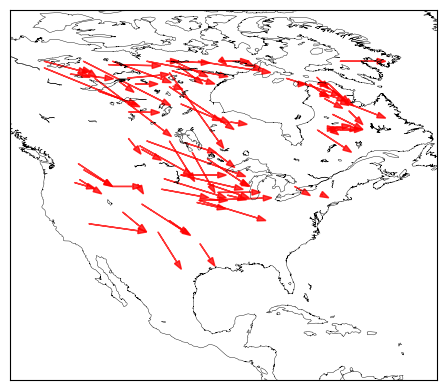

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ======== LOAD FILE ========
file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx"
df = pd.read_excel(file)

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Direction column (4- or 8-bin)
direction_col = "direction8" if "direction8" in df.columns else "direction4"

# ======== FILTER: CLUSTER + DIRECTIONS (SE and E) ========
# keep only cluster 1
df = df[df["cluster"] == 1].copy()

wanted_dirs = ["SE", "E"]

# make sure direction strings are clean
df[direction_col] = df[direction_col].astype(str).str.strip().str.upper()

# keep only rows where direction is SE or E
df_keep = df[df[direction_col].isin(wanted_dirs)].copy()

print("Total events in cluster 1:", len(df))
print("Kept with directions SE or E:", len(df_keep))

# ======== PLOT ========
plt.figure(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-130, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)

# Colors by direction, not by cluster
dir_colors = {
    "SE": "red",
    "E":  "red"
}

for _, row in df_keep.iterrows():
    slon = row["starting longitude"]
    slat = row["starting latitude"]
    elon = row["ending longitude"]
    elat = row["ending latitude"]
    ddir = row[direction_col]   # SE or E

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    plt.arrow(xs, ys, xe - xs, ye - ys,
              length_includes_head=True,
              head_width=1.0,
              head_length=1.5,
              color=dir_colors.get(ddir, "k"),
              alpha=0.8)

plt.tight_layout()

plt.savefig(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\NA_SE_vs_E.png",
    dpi=300, transparent=True, bbox_inches='tight'
)

plt.show()


After direction & cluster filter: 54 events
Events inside USA polygon: 28
Saved filtered events to: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Cluster1_SE_in_USA.xlsx


C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3473: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


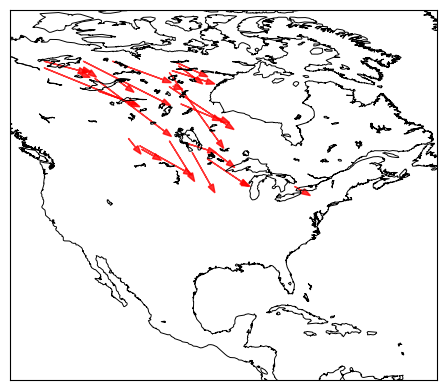

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import geopandas as gpd

# ========= PATHS =========
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx"
usa_shp  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\REGIONAL_Area\USA.shp"
out_excel = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Cluster1_SE_in_USA.xlsx"

# ========= LOAD EVENTS =========
df = pd.read_excel(in_file)
df.columns = [c.strip().lower() for c in df.columns]

direction_col = "direction8" if "direction8" in df.columns else "direction4"

cluster_dir_map = {1: "SE"}
df = df[df["cluster"].isin(cluster_dir_map.keys())]
df["keep_flag"] = df.apply(
    lambda r: r[direction_col] == cluster_dir_map[r["cluster"]],
    axis=1
)
df_keep = df[df["keep_flag"]].copy()

print("After direction & cluster filter:", len(df_keep), "events")

# ========= LOAD USA SHAPEFILE & SPATIAL FILTER =========
usa = gpd.read_file(usa_shp)
usa = usa.to_crs("EPSG:4326")   # ensure lon/lat

# make points from starting locations
gdf_pts = gpd.GeoDataFrame(
    df_keep,
    geometry=gpd.points_from_xy(df_keep["starting longitude"], df_keep["starting latitude"]),
    crs="EPSG:4326"
)

# spatial join: keep only points inside USA polygon
gdf_in = gpd.sjoin(gdf_pts, usa, how="inner", op="within")

# drop geometry/join columns for pure table
df_in_usa = gdf_in.drop(columns=[c for c in gdf_in.columns if c.startswith("index_") or c == "geometry"])

print("Events inside USA polygon:", len(df_in_usa))

# save to Excel
df_in_usa.to_excel(out_excel, index=False)
print("Saved filtered events to:", out_excel)

# ========= PLOT ONLY EVENTS INSIDE USA =========
plt.figure(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-130, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l"
)
m.drawcoastlines(linewidth=0.7)


colors = {1: "red", 2: "blue", 3: "green"}

for _, row in df_in_usa.iterrows():
    slon = row["starting longitude"]
    slat = row["starting latitude"]
    elon = row["ending longitude"]
    elat = row["ending latitude"]
    cl   = row["cluster"]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    plt.arrow(xs, ys, xe - xs, ye - ys,
              length_includes_head=True,
              head_width=1.0,
              head_length=1.5,
              color=colors.get(cl, "k"),
              alpha=0.8)

plt.tight_layout()
plt.show()


In [184]:
import pandas as pd

# ======== PATHS (EDIT DAILY FILE NAME IF NEEDED) ========
cluster_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_Cluster1_SE_in_USA.xlsx"
daily_file   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Daily_Summary_Continent.xlsx"
out_file     = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA.xlsx"

# ======== READ FILES ========
df_cluster = pd.read_excel(cluster_file)
df_daily   = pd.read_excel(daily_file)

# make column names lower + stripped (handles 'Event ID' vs 'event id')
df_cluster.columns = [c.strip().lower() for c in df_cluster.columns]
df_daily.columns   = [c.strip().lower() for c in df_daily.columns]

# ======== GET EVENT IDS FROM CLUSTER FILE ========
# assumes column is named 'event id' after lowering
event_col = "event id"
if event_col not in df_cluster.columns:
    print("Available columns in cluster file:", df_cluster.columns)
    raise SystemExit("Couldn't find 'event id' column in cluster file.")

event_ids = df_cluster[event_col].unique()

# ======== FILTER DAILY FILE TO ONLY THESE EVENTS ========
df_daily_sel = df_daily[df_daily[event_col].isin(event_ids)].copy()

# keep only desired columns
cols_wanted = [
    "date",
    "duration",
    "total voxels",
    "total severity",
    "maximum severity",
    "latitude",
    "longitude",
    "voxelsperday"
]

missing = [c for c in cols_wanted if c not in df_daily_sel.columns]
if missing:
    print("Missing columns in daily file:", missing)
    raise SystemExit("Check column names in daily summary file.")

df_out = df_daily_sel[[event_col] + cols_wanted]

# ======== SAVE TO EXCEL ========
df_out.to_excel(out_file, index=False)
print("Saved daily info for Cluster-1 SE events to:")
print(out_file)

# (optional) quick check
print(df_out.head())


Saved daily info for Cluster-1 SE events to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA.xlsx
       event id        date  duration  total voxels  total severity  \
25549     11950  2018-05-23         7            28            6.00   
25550     11950  2018-05-24         7            28           22.33   
25551     11950  2018-05-25         7            28           29.63   
25552     11950  2018-05-26         7            28           37.29   
25553     11950  2018-05-27         7            28           24.20   

       maximum severity   latitude  longitude  voxelsperday  
25549              6.00  50.000000 -98.000000             1  
25550              7.69  47.516346 -95.829825             4  
25551              8.13  47.219035 -96.264597             5  
25552              8.98  45.124698 -95.391258             7  
25553              6.59  44.027273 -95.744628             5  


In [256]:
import xarray as xr

# ===== READ NETCDF IN ONE STEP =====
ds = xr.open_dataset(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\NCEP_coupling_p_daily_anom_1982_2019.nc",
    engine="netcdf4"
)

print(ds)


<xarray.Dataset> Size: 746MB
Dimensions:    (lat: 70, lon: 192, time: 13879)
Coordinates:
  * lat        (lat) float32 280B 65.71 63.81 61.9 60.0 ... -61.9 -63.81 -65.71
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) datetime64[ns] 111kB 1982-01-01 1982-01-02 ... 2019-12-31
    dayofyear  (time) int64 111kB ...
Data variables:
    p_anom     (time, lat, lon) float32 746MB ...


In [250]:
import xarray as xr
import pandas as pd
import numpy as np
import os

# ============================================================
# 1. FILE PATHS (EDIT ONLY IF NAMES CHANGE)
# ============================================================
nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\hgt_500hPa_1982_2019_daily_anom.nc"

event_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA.xlsx"

out_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism"
out_file = os.path.join(out_folder, "Z500_max_trajectory_Cluster1_SE_in_USA_10days.xlsx")

# search radius and lead days
RADIUS_KM = 1000.0
MAX_LEAD_DAYS = 10   # Day 0 ... Day 10  (11 days total)

# ============================================================
# 2. OPEN NETCDF AND QUICKLY REVIEW
# ============================================================
ds = xr.open_dataset(nc_path)

print("===== DATASET SUMMARY =====")
print(ds)

print("\n===== DIMENSIONS (sizes) =====")
for dim, size in ds.sizes.items():
    print(f"{dim}: {size}")

print("\n===== COORDINATES (first few values if 1D) =====")
for coord in ds.coords:
    arr = ds[coord].values
    if arr.ndim == 0:
        print(f"{coord}: {arr}")
    elif arr.ndim == 1:
        print(f"{coord}: {arr[:5]} ...")
    else:
        print(f"{coord}: shape={arr.shape}")

if "hgt_500_anom" not in ds.data_vars:
    raise ValueError("Variable 'hgt_500_anom' not found in dataset!")

hgt = ds["hgt_500_anom"]
time_da = ds["time"]
lat_da = ds["lat"]
lon_da = ds["lon"]

print("\nTime range in NetCDF:")
print("  Start:", str(time_da.values[0]))
print("  End  :", str(time_da.values[-1]))

# ============================================================
# 3. READ EVENT FILE & GET FIRST DAY OF EACH EVENT
# ============================================================
df_evt = pd.read_excel(event_path)

# Standardize column names if needed
df_evt.columns = [c.strip().lower() for c in df_evt.columns]

# Expecting columns: 'event id', 'date', 'latitude', 'longitude'
# Rename to simpler names
rename_map = {}
for col in df_evt.columns:
    if "event" in col and "id" in col:
        rename_map[col] = "event_id"
    elif col == "date":
        rename_map[col] = "date"
    elif "lat" in col:
        rename_map[col] = "lat"
    elif "lon" in col:
        rename_map[col] = "lon"
df_evt = df_evt.rename(columns=rename_map)

required_cols = ["event_id", "date", "lat", "lon"]
missing = [c for c in required_cols if c not in df_evt.columns]
if missing:
    raise ValueError(f"Missing required columns in event file: {missing}")

df_evt["date"] = pd.to_datetime(df_evt["date"])

# Sort so groupby().first() gives earliest date
df_evt = df_evt.sort_values(["event_id", "date"])

# One row per event: earliest date + centroid lat/lon
df_first = df_evt.groupby("event_id", as_index=False).first()

print("\nNumber of events:", len(df_first))
print(df_first.head())

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================
EARTH_RADIUS_KM = 6371.0

def lon_to_0_360(lon_deg):
    """Convert longitude from [-180,180] to [0,360]."""
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert longitude from [0,360] to [-180,180]."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    """
    Compute great-circle distance (km) between a single point (lat0, lon0)
    and 2D arrays lat2d, lon2d (all in degrees).
    """
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat / 2.0)**2 + np.cos(lat0_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# Create 2D lat/lon grids once to re-use
lon2d, lat2d = np.meshgrid(lon_da.values, lat_da.values)

# NEW: same longitudes but in [-180,180] for easy USA box selection
lon2d_m180 = lon_to_minus180_180(lon2d)  # works with arrays

# NEW: bounding box for "CONUS+Canada" style domain
BBOX_LON_MIN = -130.0
BBOX_LON_MAX = -55.0
BBOX_LAT_MIN = 10.0
BBOX_LAT_MAX = 75.0

# ============================================================
# 5. TRACK Z500 MAX FOR EACH EVENT FOR DAY 0 → DAY 10
# ============================================================
records = []

for idx, row in df_first.iterrows():
    event_id = row["event_id"]
    start_date = row["date"]
    # centroid from file (day 0 center for the SEARCH)
    center_lat = float(row["lat"])
    center_lon = float(row["lon"])
    center_lon_0360 = lon_to_0_360(center_lon)

    # For each event, 
    curr_center_lat = center_lat
    curr_center_lon = center_lon_0360

    print(f"\nProcessing event {event_id}, start date {start_date.date()} ...")

    for lead in range(0, MAX_LEAD_DAYS + 1):  # 0..10
        this_date = start_date + pd.Timedelta(days=lead)

        # If this_date outside of ERA5 time span, stop for this event
        if (this_date < pd.to_datetime(str(time_da.values[0]))) or \
           (this_date > pd.to_datetime(str(time_da.values[-1]))):
            print(f"  Lead {lead}: date {this_date.date()} outside time range → stop.")
            break

        # Extract hgt anomalies on that day (2D: lat, lon)
        try:
            hgt_day = hgt.sel(time=this_date)
        except KeyError:
            # If exact date not found
            print(f"  Lead {lead}: date {this_date.date()} not found in time axis → stop.")
            break

        # Compute distance from current search center (in [0,360] lon space)
        dist_km = haversine_km(curr_center_lat, curr_center_lon, lat2d, lon2d)

        # NEW: region mask for the desired US domain (in [-180,180] lon, lat range)
        region_mask = (
            (lat2d >= BBOX_LAT_MIN) & (lat2d <= BBOX_LAT_MAX) &
            (lon2d_m180 >= BBOX_LON_MIN) & (lon2d_m180 <= BBOX_LON_MAX)
        )

        # Mask points beyond radius AND outside region
        mask = (dist_km <= RADIUS_KM) & region_mask

        if not np.any(mask):
            print(f"  Lead {lead}: no grid points within {RADIUS_KM} km "
                  f"inside [{BBOX_LON_MIN},{BBOX_LON_MAX}] × [{BBOX_LAT_MIN},{BBOX_LAT_MAX}] → stop.")
            break

        # Apply mask to hgt field
        hgt_vals = hgt_day.values
        hgt_masked = np.where(mask, hgt_vals, np.nan)

        # Find index of maximum Z500 anomaly in this radius+domain
        try:
            flat_index = np.nanargmax(hgt_masked)
        except ValueError:
            # all NaNs
            print(f"  Lead {lead}: all masked values are NaN → stop.")
            break

        iy, ix = np.unravel_index(flat_index, hgt_masked.shape)
        zmax_val = hgt_vals[iy, ix]
        zmax_lat = float(lat_da.values[iy])
        zmax_lon_0360 = float(lon_da.values[ix])
        zmax_lon_m180_180 = lon_to_minus180_180(zmax_lon_0360)

        # Save record
        records.append({
            "event_id": event_id,
            "lead_day": lead,
            "date": this_date.date(),
            "z500_max_lat": zmax_lat,
            "z500_max_lon": zmax_lon_m180_180,
            "z500_max_value": zmax_val,
            "search_center_lat": curr_center_lat,
            "search_center_lon_0_360": curr_center_lon
        })

        # Update search center for next day (moving with the high-pressure center)
        curr_center_lat = zmax_lat
        curr_center_lon = zmax_lon_0360

        print(f"  Lead {lead}: date {this_date.date()}, "
              f"Zmax at ({zmax_lat:.2f}, {zmax_lon_m180_180:.2f}), value={zmax_val:.2f}")

# ============================================================
# 6. SAVE OUTPUT
# ============================================================
df_out = pd.DataFrame.from_records(records)

print("\nSaving output to:", out_file)
df_out.to_excel(out_file, index=False)
print("Done.")


===== DATASET SUMMARY =====
<xarray.Dataset> Size: 568MB
Dimensions:       (lat: 73, lon: 144, time: 13514)
Coordinates:
    level         float32 4B ...
  * lat           (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon           (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time          (time) datetime64[ns] 108kB 1982-01-01 ... 2019-12-31
    dayofyear     (time) int64 108kB ...
Data variables:
    hgt_500_anom  (time, lat, lon) float32 568MB ...

===== DIMENSIONS (sizes) =====
lat: 73
lon: 144
time: 13514

===== COORDINATES (first few values if 1D) =====
level: 500.0
lat: [90.  87.5 85.  82.5 80. ] ...
lon: [ 0.   2.5  5.   7.5 10. ] ...
time: ['1982-01-01T00:00:00.000000000' '1982-01-02T00:00:00.000000000'
 '1982-01-03T00:00:00.000000000' '1982-01-04T00:00:00.000000000'
 '1982-01-05T00:00:00.000000000'] ...
dayofyear: [1 2 3 4 5] ...

Time range in NetCDF:
  Start: 1982-01-01T00:00:00.000000000
  End  : 2019-12-31T00:00:00.000000000

Numbe

In [251]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import os

# ============================================================
# INPUT FILE
# ============================================================
in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Z500_max_trajectory_Cluster1_SE_in_USA_10days.xlsx"

out_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism"

MAX_LEAD_DAYS = 10   # Day 0..10

# ============================================================
# 1. Read input
# ============================================================
df = pd.read_excel(in_file)
df.columns = [c.strip().lower() for c in df.columns]
df = df.sort_values(["event_id", "lead_day"])

# Keep only full 0..10 trajectories
needed_leads = set(range(0, MAX_LEAD_DAYS + 1))

def has_full_leads(x):
    return set(x.values.tolist()) == needed_leads

valid_eids = (
    df.groupby("event_id")["lead_day"]
      .apply(has_full_leads)
)

valid_eids = valid_eids[valid_eids].index.tolist()
df_full = df[df["event_id"].isin(valid_eids)].copy()

# ============================================================
# 2. Build feature matrix for k-means
# ============================================================
features = []
event_ids = []

for eid, grp in df_full.groupby("event_id"):
    grp = grp.sort_values("lead_day")
    lat_seq = grp["z500_max_lat"].values
    lon_seq = grp["z500_max_lon"].values
    feat = np.concatenate([lat_seq, lon_seq])
    features.append(feat)
    event_ids.append(eid)

X = np.vstack(features)

# ============================================================
# 3. K-means clustering (2 clusters)
# ============================================================
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)

cluster_map = dict(zip(event_ids, labels))
df["cluster"] = df["event_id"].map(cluster_map)

# Drop rows where event doesn’t belong to any cluster
df_cluster = df.dropna(subset=["cluster"]).copy()
df_cluster["cluster"] = df_cluster["cluster"].astype(int)

# ============================================================
# 4. Compute mean / std trajectory per cluster
# ============================================================
agg = (
    df_cluster.groupby(["cluster", "lead_day"])
    .agg(
        mean_lat=("z500_max_lat", "mean"),
        mean_lon=("z500_max_lon", "mean"),
        std_lat=("z500_max_lat", "std"),
        std_lon=("z500_max_lon", "std"),
        mean_value=("z500_max_value", "mean"),
        std_value=("z500_max_value", "std"),
        n_events=("event_id", "nunique")
    )
    .reset_index()
)

# ============================================================
# 5. Save separate Excel files for each cluster
# ============================================================
for cluster_id in sorted(df_cluster["cluster"].unique()):

    df_traj = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    df_mean = agg[agg["cluster"] == cluster_id].copy()

    traj_file = os.path.join(out_folder, f"Cluster_{cluster_id}_trajectories.xlsx")
    mean_file = os.path.join(out_folder, f"Cluster_{cluster_id}_mean_std.xlsx")

    df_traj.to_excel(traj_file, index=False)
    df_mean.to_excel(mean_file, index=False)

    print(f"Saved: {traj_file}")
    print(f"Saved: {mean_file}")

print("\nAll cluster files created successfully.")


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_0_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_0_mean_std.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_1_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_1_mean_std.xlsx

All cluster files created successfully.


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import os

# ============================================================
# INPUTS
# ============================================================
in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\Z500_max_trajectory_Cluster1_SE_in_USA_10days.xlsx"
out_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America"

MAX_LEAD_DAYS = 10   # must have lead_day = 0..10
N_CLUSTERS = 2
RANDOM_STATE = 42
N_INIT = 20

os.makedirs(out_folder, exist_ok=True)

# ============================================================
# 1) READ + CLEAN
# ============================================================
df = pd.read_excel(in_file)
df.columns = [c.strip().lower() for c in df.columns]

required_cols = ["event_id", "lead_day", "z500_max_lat", "z500_max_lon"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nFound: {list(df.columns)}")

df = df.sort_values(["event_id", "lead_day"]).copy()

# ============================================================
# 2) KEEP ONLY EVENTS WITH FULL 0..MAX_LEAD_DAYS TRAJECTORY
# ============================================================
needed_leads = set(range(0, MAX_LEAD_DAYS + 1))

def has_full_leads(series):
    vals = pd.to_numeric(series, errors="coerce").dropna().astype(int).tolist()
    return set(vals) == needed_leads

valid_eids = (
    df.groupby("event_id")["lead_day"]
      .apply(has_full_leads)
)
valid_eids = valid_eids[valid_eids].index.tolist()

df_full = df[df["event_id"].isin(valid_eids)].copy()
if df_full.empty:
    raise ValueError("No events have complete lead_day sequence 0..10. Check lead_day values.")

# ============================================================
# 3) BUILD FEATURE MATRIX (lat sequence + lon sequence)
# ============================================================
features = []
event_ids = []

for eid, grp in df_full.groupby("event_id"):
    grp = grp.sort_values("lead_day")
    lat_seq = grp["z500_max_lat"].to_numpy(dtype=float)
    lon_seq = grp["z500_max_lon"].to_numpy(dtype=float)

    if len(lat_seq) != (MAX_LEAD_DAYS + 1) or len(lon_seq) != (MAX_LEAD_DAYS + 1):
        continue  # safety

    feat = np.concatenate([lat_seq, lon_seq])
    features.append(feat)
    event_ids.append(eid)

if len(features) == 0:
    raise ValueError("No valid feature vectors built. Check data for missing lat/lon.")

X = np.vstack(features)

# ============================================================
# 4) KMEANS CLUSTERING
# ============================================================
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
labels = kmeans.fit_predict(X)

# Map event_id -> cluster label
cluster_map = dict(zip(event_ids, labels))

# Add cluster back to full dataframe (only events that were clustered)
df["cluster"] = df["event_id"].map(cluster_map)
df_cluster = df.dropna(subset=["cluster"]).copy()
df_cluster["cluster"] = df_cluster["cluster"].astype(int)

# ============================================================
# 5) MEAN / STD TRAJECTORY PER CLUSTER (OPTIONAL)
# ============================================================
agg_cols = ["z500_max_value"] if "z500_max_value" in df_cluster.columns else []
agg_dict = {
    "mean_lat": ("z500_max_lat", "mean"),
    "mean_lon": ("z500_max_lon", "mean"),
    "std_lat":  ("z500_max_lat", "std"),
    "std_lon":  ("z500_max_lon", "std"),
    "n_events": ("event_id", "nunique"),
}
if "z500_max_value" in df_cluster.columns:
    agg_dict.update({
        "mean_value": ("z500_max_value", "mean"),
        "std_value":  ("z500_max_value", "std"),
    })

agg = (
    df_cluster.groupby(["cluster", "lead_day"])
    .agg(**agg_dict)
    .reset_index()
)

# ============================================================
# 6) SAVE: (A) EVENT_ID -> CLUSTER MAPPING TABLE
# ============================================================
mapping_df = (
    pd.DataFrame({"event_id": event_ids, "cluster": labels})
    .sort_values(["cluster", "event_id"])
    .reset_index(drop=True)
)

map_file = os.path.join(out_folder, "EventID_Cluster_Mapping.xlsx")
mapping_df.to_excel(map_file, index=False)

# ============================================================
# 7) SAVE: (B) TWO-COLUMN LIST (cluster0 IDs | cluster1 IDs)
# ============================================================
c0 = sorted([eid for eid, lab in zip(event_ids, labels) if lab == 0])
c1 = sorted([eid for eid, lab in zip(event_ids, labels) if lab == 1])

max_len = max(len(c0), len(c1))
c0 += [np.nan] * (max_len - len(c0))
c1 += [np.nan] * (max_len - len(c1))

two_col_df = pd.DataFrame({
    "event_id_cluster_0": c0,
    "event_id_cluster_1": c1
})

two_col_file = os.path.join(out_folder, "EventIDs_ByCluster_TwoColumns.xlsx")
two_col_df.to_excel(two_col_file, index=False)

# ============================================================
# 8) SAVE: (C) PER-CLUSTER TRAJECTORIES + MEAN/STD (LIKE BEFORE)
# ============================================================
for cluster_id in sorted(df_cluster["cluster"].unique()):
    df_traj = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    df_mean = agg[agg["cluster"] == cluster_id].copy()

    traj_file = os.path.join(out_folder, f"Cluster_{cluster_id}_trajectories.xlsx")
    mean_file = os.path.join(out_folder, f"Cluster_{cluster_id}_mean_std.xlsx")

    df_traj.to_excel(traj_file, index=False)
    df_mean.to_excel(mean_file, index=False)

    print(f"Saved: {traj_file}")
    print(f"Saved: {mean_file}")

print("\nDONE ")
print("Saved mapping table:", map_file)
print("Saved two-column list:", two_col_file)


C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\Cluster_0_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\Cluster_0_mean_std.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\Cluster_1_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\Cluster_1_mean_std.xlsx

DONE 
Saved mapping table: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\EventID_Cluster_Mapping.xlsx
Saved two-column list: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\\North_America\EventIDs_ByCluster_TwoColumns.xlsx


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
BASE_DIR = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America"

CLUSTER_FILE = os.path.join(BASE_DIR, "EventIDs_ByCluster_TwoColumns.xlsx")
DISP_FILE    = os.path.join(BASE_DIR, "Event_Displacement_NA_DirSpace_Clusters.xlsx")

OUT_DIR = os.path.join(BASE_DIR, "Plots")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_FIG = os.path.join(OUT_DIR, "BoxWhisker_Distance_Cluster0_vs_Cluster1_4x3.png")

# ============================================================
# READ DATA
# ============================================================
cids = pd.read_excel(CLUSTER_FILE)
disp = pd.read_excel(DISP_FILE)

c0 = pd.to_numeric(cids["cluster_0"], errors="coerce").dropna().astype(int)
c1 = pd.to_numeric(cids["cluster_1"], errors="coerce").dropna().astype(int)

disp = disp.rename(columns={"Event ID": "event_id"})
disp["Distance"] = pd.to_numeric(disp["Distance"], errors="coerce")

d0 = disp.loc[disp["event_id"].isin(c0), "Distance"].dropna()
d1 = disp.loc[disp["event_id"].isin(c1), "Distance"].dropna()

# ============================================================
# PROPER BOX–WHISKER PLOT (PAPER STYLE)
# ============================================================
plt.figure(figsize=(4, 3))

box = plt.boxplot(
    [d0, d1],
    widths=0.5,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='o', markersize=5),
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='.', alpha=0.6)
)

# clean grayscale fill (journal friendly)
for b in box["boxes"]:
    b.set_facecolor("#DDDDDD")

plt.xticks([1, 2], ["Cluster 0", "Cluster 1"])
plt.ylabel("Distance (km)")
plt.title("Event displacement distance")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300)
plt.close()

print("Saved paper-style box-whisker plot:", OUT_FIG)


Saved paper-style box-whisker plot: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Plots\BoxWhisker_Distance_Cluster0_vs_Cluster1_4x3.png


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
BASE_DIR = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America"
CLUSTER_FILE = os.path.join(BASE_DIR, "EventIDs_ByCluster_TwoColumns.xlsx")
DISP_FILE    = os.path.join(BASE_DIR, "Event_Displacement_NA_DirSpace_Clusters.xlsx")

OUT_DIR = os.path.join(BASE_DIR, "Plots")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_FIG = os.path.join(OUT_DIR, "Boxplot_Distance_Cluster0_vs_Cluster1_4x3.png")

# ============================================================
# READ
# ============================================================
cids = pd.read_excel(CLUSTER_FILE)
cids.columns = [c.strip().lower() for c in cids.columns]   # cluster_0, cluster_1

disp = pd.read_excel(DISP_FILE)
if "Event ID" in disp.columns:
    disp = disp.rename(columns={"Event ID": "event_id"})
elif "event id" in disp.columns:
    disp = disp.rename(columns={"event id": "event_id"})
elif "event_id" not in disp.columns:
    raise ValueError(f"Could not find Event ID column in displacement file. Columns: {list(disp.columns)}")

disp["event_id"] = pd.to_numeric(disp["event_id"], errors="coerce")
disp["Distance"] = pd.to_numeric(disp["Distance"], errors="coerce")

c0_ids = pd.to_numeric(cids["cluster_0"], errors="coerce").dropna().astype(int).unique()
c1_ids = pd.to_numeric(cids["cluster_1"], errors="coerce").dropna().astype(int).unique()

d0 = disp.loc[disp["event_id"].isin(c0_ids), "Distance"].dropna().to_numpy()
d1 = disp.loc[disp["event_id"].isin(c1_ids), "Distance"].dropna().to_numpy()

if len(d0) == 0 or len(d1) == 0:
    raise ValueError(f"No distances found. len(cluster_0)={len(d0)}, len(cluster_1)={len(d1)}")

# ============================================================
# PLOT: TWO BOXPLOTS (SIZE 4x3) + COLORS
# ============================================================
fig, ax = plt.subplots(figsize=(3, 3))

purple = "#7B2CBF"
yellow = "#F2C300"

bp = ax.boxplot(
    [d0, d1],
    widths=0.55,
    patch_artist=True,
    whis=1.5,
    showmeans=False,
    showfliers=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
    flierprops=dict(marker=".", markersize=4, alpha=0.6, markeredgecolor="black")
)

# color the boxes
bp["boxes"][0].set_facecolor(purple)
bp["boxes"][1].set_facecolor(yellow)
bp["boxes"][0].set_alpha(0.85)
bp["boxes"][1].set_alpha(0.85)

ax.set_xticks([1, 2])
ax.set_xticklabels([f"Migratory", f"Localized"])

ax.set_ylabel("Migrtaion Distance (km)")
ax.grid(axis="y", alpha=0.0)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, transparent=True)
plt.close()

print("Saved:", OUT_FIG)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Plots\Boxplot_Distance_Cluster0_vs_Cluster1_4x3.png


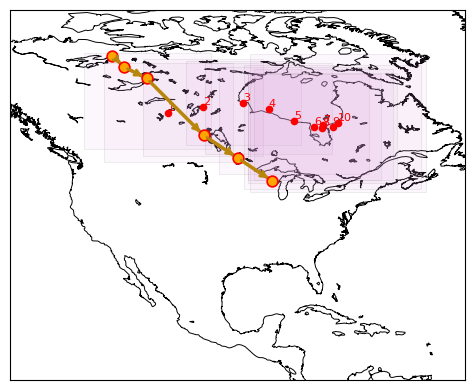

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# 1. Read cluster-0 mean/std file
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_0_mean_std.xlsx"

df0 = pd.read_excel(mean_file0)

# keep only cluster 0 (should already be), and sort by lead_day
df0 = df0[df0["cluster"] == 0].copy()
df0 = df0.sort_values("lead_day")

# Extract arrays
lead  = df0["lead_day"].values
mlat  = df0["mean_lat"].values
mlon  = df0["mean_lon"].values
slat  = df0["std_lat"].values
slon  = df0["std_lon"].values

# ============================================================
# 2. Base map over USA
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l",
    ax=ax
)

m.drawcoastlines(linewidth=0.7)

# GRID OFF + no tick labels
ax.set_xticks([])
ax.set_yticks([])

# ============================================================
# 3. Plot uncertainty boxes (smaller, lighter, black outline)
# ============================================================
shrink_factor = 1  

for lon_c, lat_c, dlon, dlat in zip(mlon, mlat, slon, slat):
    if np.isnan(dlon) or np.isnan(dlat):
        continue

    dlon_s = dlon * shrink_factor
    dlat_s = dlat * shrink_factor

    lon0 = lon_c - dlon_s
    lat0 = lat_c - dlat_s
    width  = 2 * dlon_s
    height = 2 * dlat_s

    rect = Rectangle(
        (lon0, lat0),
        width,
        height,
        facecolor="plum",
        alpha=0.078,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )
    ax.add_patch(rect)

# ============================================================
# 4. Plot mean trajectory points + labels
# ============================================================

# --- All red points for Day 1–10 only (skip Day 0) ---
m.scatter(mlon[1:], mlat[1:], s=20, c="red", zorder=10)


# --- Label red points with numbers 1–10 (skip 0) ---
for ld, lon, lat in zip(lead, mlon, mlat):
    if ld == 0:
        continue  # skip day 0
    ax.text(lon, lat,
            str(ld),
            color="red",
            fontsize=8,
            ha="left",    # slight shift for readability
            va="bottom",
            zorder=13)

# ============================================================
# 5. Decorations
# ============================================================
# ============================================================
# 6. Drought Path Overlay (Darkgoldenrod line + orange circles)
# ============================================================

# Manual drought path points
d_lat = np.array([67, 65, 63, 53, 49, 45])
d_lon = np.array([-117, -115, -111, -101, -95, -89])

# Convert lon/lat to map coords
dx, dy = m(d_lon, d_lat)

# ---- Plot drought trajectory line ----
m.plot(dx, dy, color="darkgoldenrod", linewidth=2.5, zorder=20)

# ---- Plot circle markers ----
m.scatter(
    d_lon, d_lat,
    s=60,
    facecolor="orange",
    edgecolor="red",
    linewidth=1.2,
    zorder=21
)

# ---- Add arrows between each drought point ----
for i in range(len(d_lon)-1):
    x1, y1 = dx[i], dy[i]
    x2, y2 = dx[i+1], dy[i+1]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="darkgoldenrod",
            lw=2,
            shrinkA=3,
            shrinkB=3
        ),
        zorder=22
    )


plt.tight_layout()
plt.show()


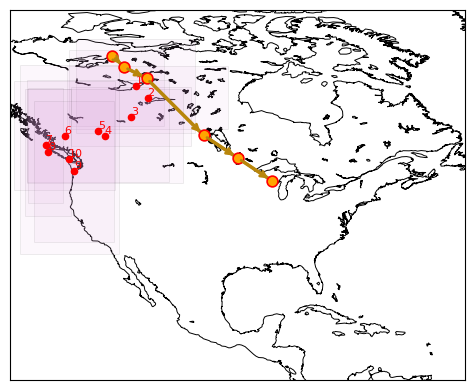

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# 1. Read cluster-0 mean/std file
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_1_mean_std.xlsx"

df0 = pd.read_excel(mean_file0)

# keep only cluster 0 (should already be), and sort by lead_day
df0 = df0[df0["cluster"] == 1].copy()
df0 = df0.sort_values("lead_day")

# Extract arrays
lead  = df0["lead_day"].values
mlat  = df0["mean_lat"].values
mlon  = df0["mean_lon"].values
slat  = df0["std_lat"].values
slon  = df0["std_lon"].values

# ============================================================
# 2. Base map over USA
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l",
    ax=ax
)

m.drawcoastlines(linewidth=0.7)

# GRID OFF + no tick labels
ax.set_xticks([])
ax.set_yticks([])

# ============================================================
# 3. Plot uncertainty boxes (smaller, lighter, black outline)
# ============================================================
shrink_factor = 1  

for lon_c, lat_c, dlon, dlat in zip(mlon, mlat, slon, slat):
    if np.isnan(dlon) or np.isnan(dlat):
        continue

    dlon_s = dlon * shrink_factor
    dlat_s = dlat * shrink_factor

    lon0 = lon_c - dlon_s
    lat0 = lat_c - dlat_s
    width  = 2 * dlon_s
    height = 2 * dlat_s

    rect = Rectangle(
        (lon0, lat0),
        width,
        height,
        facecolor="plum",
        alpha=0.078,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )
    ax.add_patch(rect)

# ============================================================
# 4. Plot mean trajectory points + labels
# ============================================================

# --- All red points for Day 1–10 only (skip Day 0) ---
m.scatter(mlon[1:], mlat[1:], s=20, c="red", zorder=10)


# --- Label red points with numbers 1–10 (skip 0) ---
for ld, lon, lat in zip(lead, mlon, mlat):
    if ld == 0:
        continue  # skip day 0
    ax.text(lon, lat,
            str(ld),
            color="red",
            fontsize=8,
            ha="left",    # slight shift for readability
            va="bottom",
            zorder=13)

# ============================================================
# 5. Decorations
# ============================================================
# ============================================================
# 6. Drought Path Overlay (Darkgoldenrod line + orange circles)
# ============================================================

# Manual drought path points
d_lat = np.array([67, 65, 63, 53, 49, 45])
d_lon = np.array([-117, -115, -111, -101, -95, -89])

# Convert lon/lat to map coords
dx, dy = m(d_lon, d_lat)

# ---- Plot drought trajectory line ----
m.plot(dx, dy, color="darkgoldenrod", linewidth=2.5, zorder=20)

# ---- Plot circle markers ----
m.scatter(
    d_lon, d_lat,
    s=60,
    facecolor="orange",
    edgecolor="red",
    linewidth=1.2,
    zorder=21
)

# ---- Add arrows between each drought point ----
for i in range(len(d_lon)-1):
    x1, y1 = dx[i], dy[i]
    x2, y2 = dx[i+1], dy[i+1]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="darkgoldenrod",
            lw=2,
            shrinkA=3,
            shrinkB=3
        ),
        zorder=22
    )


plt.tight_layout()
plt.show()


In [257]:
import xarray as xr
import pandas as pd
import numpy as np
import os

# ============================================================
# 1. FILE PATHS (EDIT ONLY IF NAMES CHANGE)
# ============================================================
nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\NCEP_coupling_p_daily_anom_1982_2019.nc"

event_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA.xlsx"

out_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism"
out_file = os.path.join(out_folder, "CouplingP_max_trajectory_Cluster1_SE_in_USA_10days.xlsx")

# search radius and lead days
RADIUS_KM = 1000.0
MAX_LEAD_DAYS = 10   # Day 0 ... Day 10  (11 days total)

# ============================================================
# 2. OPEN NETCDF AND QUICKLY REVIEW
# ============================================================
ds = xr.open_dataset(nc_path)

print("===== DATASET SUMMARY =====")
print(ds)

print("\n===== DIMENSIONS (sizes) =====")
for dim, size in ds.sizes.items():
    print(f"{dim}: {size}")

print("\n===== COORDINATES (first few values if 1D) =====")
for coord in ds.coords:
    arr = ds[coord].values
    if arr.ndim == 0:
        print(f"{coord}: {arr}")
    elif arr.ndim == 1:
        print(f"{coord}: {arr[:5]} ...")
    else:
        print(f"{coord}: shape={arr.shape}")

if "p_anom" not in ds.data_vars:
    raise ValueError("Variable 'p_anom' not found in dataset!")

p_anom = ds["p_anom"]
time_da = ds["time"]
lat_da = ds["lat"]
lon_da = ds["lon"]

print("\nTime range in NetCDF:")
print("  Start:", str(time_da.values[0]))
print("  End  :", str(time_da.values[-1]))

# ============================================================
# 3. READ EVENT FILE & GET FIRST DAY OF EACH EVENT
# ============================================================
df_evt = pd.read_excel(event_path)

# Standardize column names if needed
df_evt.columns = [c.strip().lower() for c in df_evt.columns]

# Expecting columns: 'event id', 'date', 'latitude', 'longitude'
# Rename to simpler names
rename_map = {}
for col in df_evt.columns:
    if "event" in col and "id" in col:
        rename_map[col] = "event_id"
    elif col == "date":
        rename_map[col] = "date"
    elif "lat" in col:
        rename_map[col] = "lat"
    elif "lon" in col:
        rename_map[col] = "lon"
df_evt = df_evt.rename(columns=rename_map)

required_cols = ["event_id", "date", "lat", "lon"]
missing = [c for c in required_cols if c not in df_evt.columns]
if missing:
    raise ValueError(f"Missing required columns in event file: {missing}")

df_evt["date"] = pd.to_datetime(df_evt["date"])

# Sort so groupby().first() gives earliest date
df_evt = df_evt.sort_values(["event_id", "date"])

# One row per event: earliest date + centroid lat/lon
df_first = df_evt.groupby("event_id", as_index=False).first()

print("\nNumber of events:", len(df_first))
print(df_first.head())

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================
EARTH_RADIUS_KM = 6371.0

def lon_to_0_360(lon_deg):
    """Convert longitude from [-180,180] to [0,360]."""
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert longitude from [0,360] to [-180,180]."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    """
    Compute great-circle distance (km) between a single point (lat0, lon0)
    and 2D arrays lat2d, lon2d (all in degrees).
    """
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat / 2.0)**2 + np.cos(lat0_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# Create 2D lat/lon grids once to re-use
lon2d, lat2d = np.meshgrid(lon_da.values, lat_da.values)

# same longitudes but in [-180,180] for easy USA box selection
lon2d_m180 = lon_to_minus180_180(lon2d)  # works with arrays

# bounding box for "CONUS+Canada" style domain
BBOX_LON_MIN = -130.0
BBOX_LON_MAX = -55.0
BBOX_LAT_MIN = 10.0
BBOX_LAT_MAX = 75.0

# ============================================================
# 5. TRACK MAX p_anom FOR EACH EVENT FOR DAY 0 → DAY 10
# ============================================================
records = []

for idx, row in df_first.iterrows():
    event_id = row["event_id"]
    start_date = row["date"]
    # centroid from file (day 0 center for the SEARCH)
    center_lat = float(row["lat"])
    center_lon = float(row["lon"])
    center_lon_0360 = lon_to_0_360(center_lon)

    # For each event,
    curr_center_lat = center_lat
    curr_center_lon = center_lon_0360

    print(f"\nProcessing event {event_id}, start date {start_date.date()} ...")

    for lead in range(0, MAX_LEAD_DAYS + 1):  # 0..10
        this_date = start_date + pd.Timedelta(days=lead)

        # If this_date outside of time span, stop for this event
        if (this_date < pd.to_datetime(str(time_da.values[0]))) or \
           (this_date > pd.to_datetime(str(time_da.values[-1]))):
            print(f"  Lead {lead}: date {this_date.date()} outside time range → stop.")
            break

        # Extract p_anom on that day (2D: lat, lon)
        try:
            p_day = p_anom.sel(time=this_date)
        except KeyError:
            print(f"  Lead {lead}: date {this_date.date()} not found in time axis → stop.")
            break

        # Compute distance from current search center (in [0,360] lon space)
        dist_km = haversine_km(curr_center_lat, curr_center_lon, lat2d, lon2d)

        # region mask for the desired US domain (in [-180,180] lon, lat range)
        region_mask = (
            (lat2d >= BBOX_LAT_MIN) & (lat2d <= BBOX_LAT_MAX) &
            (lon2d_m180 >= BBOX_LON_MIN) & (lon2d_m180 <= BBOX_LON_MAX)
        )

        # Mask points beyond radius AND outside region
        mask = (dist_km <= RADIUS_KM) & region_mask

        if not np.any(mask):
            print(f"  Lead {lead}: no grid points within {RADIUS_KM} km "
                  f"inside [{BBOX_LON_MIN},{BBOX_LON_MAX}] × [{BBOX_LAT_MIN},{BBOX_LAT_MAX}] → stop.")
            break

        # Apply mask to p_anom field
        p_vals = p_day.values
        p_masked = np.where(mask, p_vals, np.nan)


        # Find index of maximum p_anom in this radius+domain
        try:
            flat_index = np.nanargmax(p_masked)
        except ValueError:
            # all NaNs
            print(f"  Lead {lead}: all masked values are NaN → stop.")
            break

        iy, ix = np.unravel_index(flat_index, p_masked.shape)
        pmax_val = p_vals[iy, ix]
        pmax_lat = float(lat_da.values[iy])
        pmax_lon_0360 = float(lon_da.values[ix])
        pmax_lon_m180_180 = lon_to_minus180_180(pmax_lon_0360)

        # Save record
        records.append({
            "event_id": event_id,
            "lead_day": lead,
            "date": this_date.date(),
            "p_max_lat": pmax_lat,
            "p_max_lon": pmax_lon_m180_180,
            "p_max_value": pmax_val,
            "search_center_lat": curr_center_lat,
            "search_center_lon_0_360": curr_center_lon
        })

        # Update search center for next day (moving with the max coupling signal)
        curr_center_lat = pmax_lat
        curr_center_lon = pmax_lon_0360

        print(f"  Lead {lead}: date {this_date.date()}, "
              f"p_max at ({pmax_lat:.2f}, {pmax_lon_m180_180:.2f}), value={pmax_val:.4f}")

# ============================================================
# 6. SAVE OUTPUT
# ============================================================
df_out = pd.DataFrame.from_records(records)

print("\nSaving output to:", out_file)
df_out.to_excel(out_file, index=False)
print("Done.")


===== DATASET SUMMARY =====
<xarray.Dataset> Size: 746MB
Dimensions:    (lat: 70, lon: 192, time: 13879)
Coordinates:
  * lat        (lat) float32 280B 65.71 63.81 61.9 60.0 ... -61.9 -63.81 -65.71
  * lon        (lon) float32 768B 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) datetime64[ns] 111kB 1982-01-01 1982-01-02 ... 2019-12-31
    dayofyear  (time) int64 111kB ...
Data variables:
    p_anom     (time, lat, lon) float32 746MB ...

===== DIMENSIONS (sizes) =====
lat: 70
lon: 192
time: 13879

===== COORDINATES (first few values if 1D) =====
lat: [65.7125 63.8079 61.9033 59.9986 58.0939] ...
lon: [0.    1.875 3.75  5.625 7.5  ] ...
time: ['1982-01-01T00:00:00.000000000' '1982-01-02T00:00:00.000000000'
 '1982-01-03T00:00:00.000000000' '1982-01-04T00:00:00.000000000'
 '1982-01-05T00:00:00.000000000'] ...
dayofyear: [1 2 3 4 5] ...

Time range in NetCDF:
  Start: 1982-01-01T00:00:00.000000000
  End  : 2019-12-31T00:00:00.000000000

Number of events: 25
   event_id   

In [258]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import os

# ============================================================
# INPUT / OUTPUT
# ============================================================
in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_max_trajectory_Cluster1_SE_in_USA_10days.xlsx"

out_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism"

MAX_LEAD_DAYS = 10   # Day 0..10

# ============================================================
# 1. Read input
# ============================================================
df = pd.read_excel(in_file)
df.columns = [c.strip().lower() for c in df.columns]
df = df.sort_values(["event_id", "lead_day"])

# Keep only full 0..10 trajectories
needed_leads = set(range(0, MAX_LEAD_DAYS + 1))

def has_full_leads(x):
    return set(x.values.tolist()) == needed_leads

valid_eids = (
    df.groupby("event_id")["lead_day"]
      .apply(has_full_leads)
)

valid_eids = valid_eids[valid_eids].index.tolist()
df_full = df[df["event_id"].isin(valid_eids)].copy()

print(f"Total events: {df['event_id'].nunique()}, "
      f"events with full 0–{MAX_LEAD_DAYS} days: {len(valid_eids)}")

# ============================================================
# 2. Build feature matrix for k-means
#    (use p_max_lat / p_max_lon instead of z500)
# ============================================================
features = []
event_ids = []

for eid, grp in df_full.groupby("event_id"):
    grp = grp.sort_values("lead_day")
    lat_seq = grp["p_max_lat"].values
    lon_seq = grp["p_max_lon"].values
    feat = np.concatenate([lat_seq, lon_seq])  # [lat0..lat10, lon0..lon10]
    features.append(feat)
    event_ids.append(eid)

X = np.vstack(features)

# ============================================================
# 3. K-means clustering (2 clusters)
# ============================================================
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)

cluster_map = dict(zip(event_ids, labels))
df["cluster"] = df["event_id"].map(cluster_map)

# Drop rows where event doesn’t belong to any cluster
df_cluster = df.dropna(subset=["cluster"]).copy()
df_cluster["cluster"] = df_cluster["cluster"].astype(int)

# ============================================================
# 4. Compute mean / std trajectory per cluster
#    using p_max_* variables
# ============================================================
agg = (
    df_cluster.groupby(["cluster", "lead_day"])
    .agg(
        mean_lat=("p_max_lat", "mean"),
        mean_lon=("p_max_lon", "mean"),
        std_lat=("p_max_lat", "std"),
        std_lon=("p_max_lon", "std"),
        mean_value=("p_max_value", "mean"),
        std_value=("p_max_value", "std"),
        n_events=("event_id", "nunique")
    )
    .reset_index()
)

# ============================================================
# 5. Save separate Excel files for each cluster
# ============================================================
for cluster_id in sorted(df_cluster["cluster"].unique()):

    df_traj = df_cluster[df_cluster["cluster"] == cluster_id].copy()
    df_mean = agg[agg["cluster"] == cluster_id].copy()

    traj_file = os.path.join(out_folder, f"CouplingP_Cluster_{cluster_id}_trajectories.xlsx")
    mean_file = os.path.join(out_folder, f"CouplingP_Cluster_{cluster_id}_mean_std.xlsx")

    df_traj.to_excel(traj_file, index=False)
    df_mean.to_excel(mean_file, index=False)

    print(f"Saved: {traj_file}")
    print(f"Saved: {mean_file}")

print("\nAll coupling-P cluster files created successfully.")


Total events: 25, events with full 0–10 days: 25
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_0_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_0_mean_std.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_1_trajectories.xlsx
Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_1_mean_std.xlsx

All coupling-P cluster files created successfully.


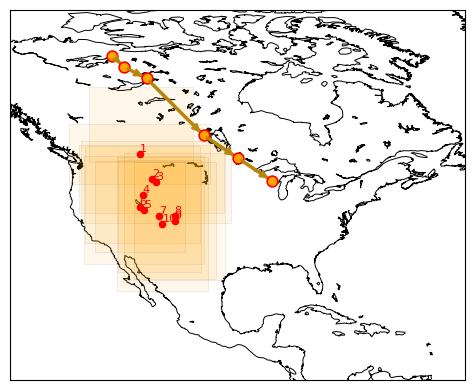

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# 1. Read cluster-0 mean/std file
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_0_mean_std.xlsx"

df0 = pd.read_excel(mean_file0)

# keep only cluster 0, and sort by lead_day
df0 = df0[df0["cluster"] == 0].copy()
df0 = df0.sort_values("lead_day")

# Extract arrays
lead  = df0["lead_day"].values
mlat  = df0["mean_lat"].values
mlon  = df0["mean_lon"].values
slat  = df0["std_lat"].values
slon  = df0["std_lon"].values

# ============================================================
# 2. Base map over USA
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l",
    ax=ax
)

m.drawcoastlines(linewidth=0.7)

# GRID OFF + no tick labels
ax.set_xticks([])
ax.set_yticks([])

# ============================================================
# 3. Plot uncertainty boxes (smaller, lighter, black outline)
# ============================================================
shrink_factor = 1.0 

for lon_c, lat_c, dlon, dlat in zip(mlon, mlat, slon, slat):
    if np.isnan(dlon) or np.isnan(dlat):
        continue

    dlon_s = dlon * shrink_factor
    dlat_s = dlat * shrink_factor

    lon0 = lon_c - dlon_s
    lat0 = lat_c - dlat_s
    width  = 2 * dlon_s
    height = 2 * dlat_s

    rect = Rectangle(
        (lon0, lat0),
        width,
        height,
        facecolor="orange",
        alpha=0.078,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )
    ax.add_patch(rect)

# ============================================================
# 4. Plot mean trajectory points + labels
# ============================================================

# --- All red points for Day 1–10 only (skip Day 0) ---
m.scatter(mlon[1:], mlat[1:], s=20, c="red", zorder=10)


# --- Label red points with numbers 1–10 (skip 0) ---
for ld, lon, lat in zip(lead, mlon, mlat):
    if ld == 0:
        continue  # skip day 0
    ax.text(lon, lat,
            str(ld),
            color="red",
            fontsize=8,
            ha="left",    # slight shift for readability
            va="bottom",
            zorder=13)

# ============================================================
# 5. Decorations
# ============================================================
# ============================================================
# 6. Drought Path Overlay (Darkgoldenrod line + orange circles)
# ============================================================

# Manual drought path points
d_lat = np.array([67, 65, 63, 53, 49, 45])
d_lon = np.array([-117, -115, -111, -101, -95, -89])

# Convert lon/lat to map coords
dx, dy = m(d_lon, d_lat)

# ---- Plot drought trajectory line ----
m.plot(dx, dy, color="darkgoldenrod", linewidth=2.5, zorder=20)

# ---- Plot circle markers ----
m.scatter(
    d_lon, d_lat,
    s=60,
    facecolor="orange",
    edgecolor="red",
    linewidth=1.2,
    zorder=21
)

# ---- Add arrows between each drought point ----
for i in range(len(d_lon)-1):
    x1, y1 = dx[i], dy[i]
    x2, y2 = dx[i+1], dy[i+1]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="darkgoldenrod",
            lw=2,
            shrinkA=3,
            shrinkB=3
        ),
        zorder=22
    )


plt.tight_layout()
plt.show()


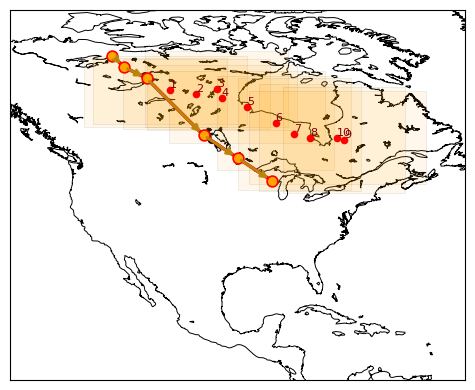

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# 1. Read cluster-0 mean/std file
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\CouplingP_Cluster_1_mean_std.xlsx"

df0 = pd.read_excel(mean_file0)

# keep only cluster 0 (should already be), and sort by lead_day
df0 = df0[df0["cluster"] == 1].copy()
df0 = df0.sort_values("lead_day")

# Extract arrays
lead  = df0["lead_day"].values
mlat  = df0["mean_lat"].values
mlon  = df0["mean_lon"].values
slat  = df0["std_lat"].values
slon  = df0["std_lon"].values

# ============================================================
# 2. Base map over USA
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l",
    ax=ax
)

m.drawcoastlines(linewidth=0.7)

# GRID OFF + no tick labels
ax.set_xticks([])
ax.set_yticks([])

# ============================================================
# 3. Plot uncertainty boxes (smaller, lighter, black outline)
# ============================================================
shrink_factor = 1 

for lon_c, lat_c, dlon, dlat in zip(mlon, mlat, slon, slat):
    if np.isnan(dlon) or np.isnan(dlat):
        continue

    dlon_s = dlon * shrink_factor
    dlat_s = dlat * shrink_factor

    lon0 = lon_c - dlon_s
    lat0 = lat_c - dlat_s
    width  = 2 * dlon_s
    height = 2 * dlat_s

    rect = Rectangle(
        (lon0, lat0),
        width,
        height,
        facecolor="orange",
        alpha=0.078,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )
    ax.add_patch(rect)

# ============================================================
# 4. Plot mean trajectory points + labels
# ============================================================

# --- All red points for Day 1–10 only (skip Day 0) ---
m.scatter(mlon[1:], mlat[1:], s=20, c="red", zorder=10)


# --- Label red points with numbers 1–10 (skip 0) ---
for ld, lon, lat in zip(lead, mlon, mlat):
    if ld == 0:
        continue  # skip day 0
    ax.text(lon, lat,
            str(ld),
            color="maroon",
            fontsize=8,
            ha="left",    # slight shift for readability
            va="bottom",
            zorder=13)

# ============================================================
# 5. Decorations
# ============================================================
# ============================================================
# 6. Drought Path Overlay (Darkgoldenrod line + orange circles)
# ============================================================

# Manual drought path points
d_lat = np.array([67, 65, 63, 53, 49, 45])
d_lon = np.array([-117, -115, -111, -101, -95, -89])

# Convert lon/lat to map coords
dx, dy = m(d_lon, d_lat)

# ---- Plot drought trajectory line ----
m.plot(dx, dy, color="red", linewidth=2.5, zorder=20)

# ---- Plot circle markers ----
m.scatter(
    d_lon, d_lat,
    s=60,
    facecolor="orange",
    edgecolor="red",
    linewidth=1.2,
    zorder=21
)

# ---- Add arrows between each drought point ----
for i in range(len(d_lon)-1):
    x1, y1 = dx[i], dy[i]
    x2, y2 = dx[i+1], dy[i+1]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="darkgoldenrod",
            lw=2,
            shrinkA=3,
            shrinkB=3
        ),
        zorder=22
    )


plt.tight_layout()
plt.show()


In [12]:
#!/usr/bin/env python
import numpy as np
from osgeo import gdal
import netCDF4
gdal.UseExceptions()

# ========= PATHS =========
tif_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\Global-AI_ET0_v3_annual\ai_v3_yr.tif"
nc_out   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_v3_yr.nc"

# ========= OPEN TIF =========
ds = gdal.Open(tif_path)
a  = ds.ReadAsArray()          # shape (nlat, nlon)
nlat, nlon = a.shape

gt = ds.GetGeoTransform()      # (x0, dx, 0, y0, 0, dy)
# Build lon/lat at **cell centers** (half-pixel shift)
lon = np.arange(nlon) * gt[1] + gt[0] + gt[1]/2.0
lat = np.arange(nlat) * gt[5] + gt[3] + gt[5]/2.0

# gdal arrays usually go from top→bottom; flip so lat is ascending (south→north)
lat = lat[::-1]
data = np.flipud(a)

# If dataset is scaled (AI * 10000), undo scaling here:
data = data.astype("float32")
data[data == ds.GetRasterBand(1).GetNoDataValue()] = np.nan
data = data * 0.0001   # comment this line out if not scaled

# ========= CREATE NETCDF =========
nc = netCDF4.Dataset(nc_out, "w", clobber=True)

# dimensions
nc.createDimension("lat", nlat)
nc.createDimension("lon", nlon)

# coordinate vars
lato = nc.createVariable("lat", "f4", ("lat",))
lato.units = "degrees_north"
lato.standard_name = "latitude"
lato.long_name = "latitude"
lato.axis = "Y"
lato[:] = lat

lono = nc.createVariable("lon", "f4", ("lon",))
lono.units = "degrees_east"
lono.standard_name = "longitude"
lono.long_name = "longitude"
lono.axis = "X"
lono[:] = lon

# CRS container (WGS84 lon/lat)
crs = nc.createVariable("crs", "i4")
crs.long_name = "Lon/Lat Coords in WGS84"
crs.grid_mapping_name = "latitude_longitude"
crs.longitude_of_prime_meridian = 0.0
crs.semi_major_axis = 6378137.0
crs.inverse_flattening = 298.257223563

# data variable
ai = nc.createVariable("ai", "f4", ("lat", "lon"),
                       zlib=True, fill_value=-9999)
ai.units = "1"  # dimensionless aridity index
ai.long_name = "Global Aridity Index"
ai.standard_name = "aridity_index"
ai.grid_mapping = "crs"
ai.missing_value = -9999.0

# write data (replace NaNs with fill)
out = data.copy()
out[np.isnan(out)] = -9999.0
ai[:, :] = out

# global attributes
nc.Conventions = "CF-1.6"
nc.title = "Global Aridity Index (AI v3)"
nc.source = "Global-AI_ET0_v3_annual GeoTIFF"
nc.history = "Converted from GeoTIFF to NetCDF"

nc.close()
print("Saved NetCDF:", nc_out)


Saved NetCDF: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_v3_yr.nc


In [15]:
import xarray as xr
import numpy as np

# -----------------------
# Load big NetCDF (lazy loading)
# -----------------------
nc_big = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_v3_yr.nc"
ds = xr.open_dataset(nc_big, chunks={"lat": 1000, "lon": 1000})  # chunked: safe

ai = ds["ai"]

# -----------------------
# Global grid size:
# 360° / 43200 = 1/120° ≈ 0.008333°
# For 2° we need: 2° / (1/120°) = 240 pixels
# -----------------------
lat_factor = 240
lon_factor = 240

# -----------------------
# Downscale to 2° using mean
# -----------------------
ai_2deg = ai.coarsen(lat=lat_factor, lon=lon_factor, boundary="trim").mean()

# -----------------------
# Fix lat/lon centers manually
# -----------------------
lat_new = np.linspace(-89, 89, ai_2deg.shape[0])
lon_new = np.linspace(-179, 179, ai_2deg.shape[1])

ai_2deg = ai_2deg.assign_coords(lat=lat_new, lon=lon_new)

# -----------------------
# Save new small NetCDF
# -----------------------
out_nc = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_2deg.nc"
ai_2deg.to_dataset(name="AI").to_netcdf(out_nc)

print("Saved:", out_nc)
print("Shape:", ai_2deg.shape)


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_12120\1789899346.py:8: UserWarning: Failed to load chunk manager entrypoint dask due to No module named 'xarray.core.daskmanager'. Skipping.
  ds = xr.open_dataset(nc_big, chunks={"lat": 1000, "lon": 1000})  # chunked: safe
C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_2deg.nc
Shape: (90, 180)


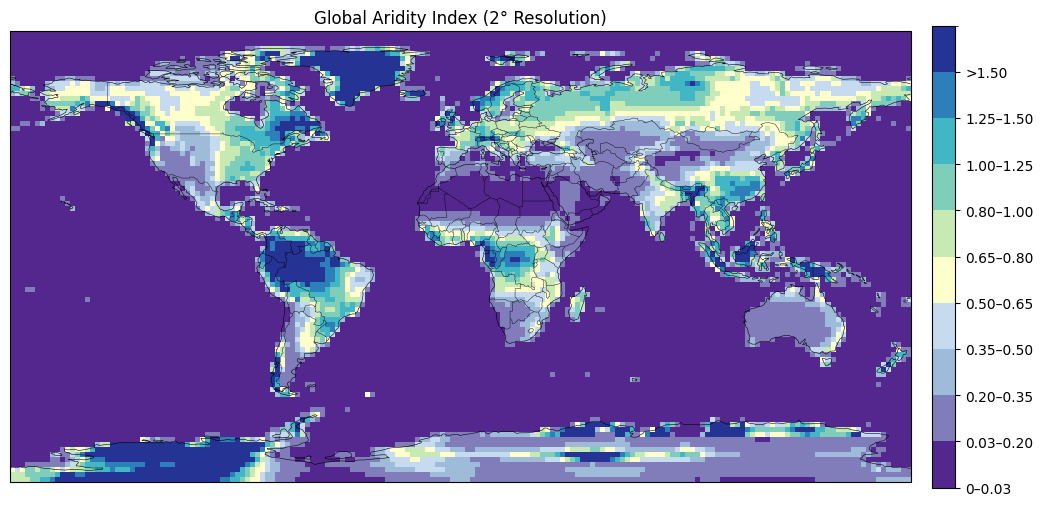

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

ds = xr.open_dataset(r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Aridity\ai_2deg.nc")
ai = ds["AI"]

bins = [0,0.03,0.20,0.35,0.50,0.65,0.80,1.00,1.25,1.50,100]

cmap = ListedColormap([
    "#54278f","#807dba","#9ebcda","#c6dbef",
    "#ffffcc","#c7e9b4","#7fcdbb","#41b6c4",
    "#2c7fb8","#253494"
])

norm = BoundaryNorm(bins, len(cmap.colors))

plt.figure(figsize=(14,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

mesh = ax.pcolormesh(ds.lon, ds.lat, ai, cmap=cmap, norm=norm)

cbar = plt.colorbar(mesh, pad=0.02)
cbar.set_ticks([0,0.03,0.20,0.35,0.50,0.65,0.80,1.00,1.25,1.50])
cbar.set_ticklabels([
    "0–0.03","0.03–0.20","0.20–0.35","0.35–0.50",
    "0.50–0.65","0.65–0.80","0.80–1.00",
    "1.00–1.25","1.25–1.50",">1.50"
])

plt.title("Global Aridity Index (2° Resolution)")
plt.show()


In [1]:
#Moisture and Heat advection 

In [5]:
import xarray as xr

nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\T_adv_850_daily_anom_1982_2019.nc"

# ------------------------------------------------
# 2. Open the dataset
# ------------------------------------------------
ds = xr.open_dataset(nc_path)

# ------------------------------------------------
# 3. Print basic info
# ------------------------------------------------
print(ds)              # full dataset summary
print("\nVariables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

# Example: if main variable is named 'q_adv'
# q = ds['q_adv']
# print(q)


<xarray.Dataset> Size: 1GB
Dimensions:             (lat: 73, lon: 144, time: 13879)
Coordinates:
    level               float32 4B ...
  * lat                 (lat) float32 292B 90.0 87.5 85.0 ... -85.0 -87.5 -90.0
  * lon                 (lon) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * time                (time) datetime64[ns] 111kB 1982-01-01 ... 2019-12-31
    dayofyear           (time) int64 111kB ...
Data variables:
    T_adv_850_anom      (time, lat, lon) float32 584MB ...
    T_adv_850_day_anom  (time, lat, lon) float32 584MB ...

Variables: ['T_adv_850_anom', 'T_adv_850_day_anom']
Coordinates: ['level', 'lat', 'lon', 'time', 'dayofyear']


In [4]:
import pandas as pd
import xarray as xr
import numpy as np

# paths
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA.xlsx"
nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\q_adv_850_daily_anom_1982_2019.nc"
out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_adv_850.xlsx"

# read excel
df = pd.read_excel(excel_path)
df['date'] = pd.to_datetime(df['date'])

# open NetCDF
ds = xr.open_dataset(nc_path)
da_q = ds['q_adv_850_anom']

# function
def get_moisture_adv(row):
    lat = float(row['latitude'])
    lon = float(row['longitude'])
    date = pd.to_datetime(row['date'])
    lon360 = (lon + 360) % 360
    try:
        val = da_q.sel(time=date, method='nearest') \
                  .sel(lat=lat, lon=lon360, method='nearest') \
                  .values
        return float(val)
    except:
        return np.nan

# compute
df['moisture_advection'] = df.apply(get_moisture_adv, axis=1)

# FIX DATE FORMAT
df['date'] = df['date'].dt.strftime('%Y-%m-%d')

# save
df.to_excel(out_path, index=False)
print("Saved:", out_path)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_adv_850.xlsx


In [6]:
import pandas as pd
import xarray as xr
import numpy as np

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
# input: the file that already has moisture_advection
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_adv_850.xlsx"

# NetCDF with temperature advection
nc_T_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\T_adv_850_daily_anom_1982_2019.nc"

# output: new file with both moisture + heat advection
out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_and_T_adv_850.xlsx"

# ------------------------------------------------------------
# 2. READ EXCEL
# ------------------------------------------------------------
df = pd.read_excel(excel_path)
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 3. OPEN NetCDF (T advection)
# ------------------------------------------------------------
ds_T = xr.open_dataset(nc_T_path)

da_T = ds_T['T_adv_850_anom']

# ------------------------------------------------------------
# 4. FUNCTION TO GET HEAT ADVECTION FOR ONE ROW
# ------------------------------------------------------------
def get_heat_adv(row):
    lat = float(row['latitude'])
    lon = float(row['longitude'])
    date = pd.to_datetime(row['date'])

    # convert lon from [-180, 180] to [0, 360] to match NetCDF
    lon360 = (lon + 360.0) % 360.0

    try:
        val = da_T.sel(time=date, method='nearest') \
                 .sel(lat=lat, lon=lon360, method='nearest') \
                 .values
        return float(val)
    except Exception:
        return np.nan

# ------------------------------------------------------------
# 5. APPLY TO ALL ROWS
# ------------------------------------------------------------
print("Extracting T_adv_850_anom for each event...")
df['heat_advection'] = df.apply(get_heat_adv, axis=1)

# ------------------------------------------------------------
# 6. CLEAN DATE FORMAT AND SAVE
# ------------------------------------------------------------
df['date'] = df['date'].dt.strftime('%Y-%m-%d')
df.to_excel(out_path, index=False)

print("Done! Saved file to:")
print(out_path)


Extracting T_adv_850_anom for each event...
Done! Saved file to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_and_T_adv_850.xlsx


In [8]:
import pandas as pd
import xarray as xr
import numpy as np

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_with_q_adv_850.xlsx"

q_nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\q_adv_850_daily_anom_1982_2019.nc"
T_nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\T_adv_850_daily_anom_1982_2019.nc"

out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX.xlsx"

R_EARTH_KM = 6371.0
RADIUS_KM  = 1000.0

# ------------------------------------------------------------
# 2. READ EXCEL
# ------------------------------------------------------------
df = pd.read_excel(excel_path)
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 3. OPEN NetCDFs AND BUILD GRID
# ------------------------------------------------------------
ds_q = xr.open_dataset(q_nc_path)
ds_T = xr.open_dataset(T_nc_path)

da_q = ds_q['q_adv_850_anom']       # (time, lat, lon)
da_T = ds_T['T_adv_850_anom']       # or 'T_adv_850_day_anom' 

lats = ds_q['lat']
lons = ds_q['lon']

# make 2D lon/lat grids as xarray.DataArray for easy masking
lon2d, lat2d = xr.broadcast(lons, lats)   # both are (lat, lon)

# ------------------------------------------------------------
# 4. HELPER: DISTANCE MASK AS xarray.DataArray
# ------------------------------------------------------------
def make_radius_mask(lat0_deg, lon0_deg):
    """
    Return xarray.DataArray[lat, lon] = True inside 1000 km
    """
    lat0 = np.deg2rad(lat0_deg)
    lon0 = np.deg2rad(lon0_deg)

    latg = np.deg2rad(lat2d)
    long = np.deg2rad(lon2d)

    dlat = latg - lat0
    dlon = long - lon0
    dlon = (dlon + np.pi) % (2 * np.pi) - np.pi  # wrap

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat0) * np.cos(latg) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    dist_km = R_EARTH_KM * c

    mask = dist_km <= RADIUS_KM
    # mask already has dims (lat, lon) and coords from lat2d/lon2d
    return mask

# ------------------------------------------------------------
# 5. MAIN FUNCTION: MONTHLY 1000 km EXTREMES
# ------------------------------------------------------------
def get_monthly_extremes(row):
    lat_ev = float(row['latitude'])
    lon_ev = float(row['longitude'])
    date_ev = pd.to_datetime(row['date'])

    # convert to [0,360] to match NetCDF longitudes
    lon_ev_360 = (lon_ev + 360.0) % 360.0

    # select whole month easily: "YYYY-MM"
    month_str = f"{date_ev.year:04d}-{date_ev.month:02d}"

    try:
        sub_q = da_q.sel(time=month_str)       # all days of that month
        sub_T = da_T.sel(time=month_str)
    except Exception:
        return pd.Series({
            'moisture_adv_min_neg_1000km_month': np.nan,
            'heat_adv_max_pos_1000km_month': np.nan
        })

    # radius mask
    mask = make_radius_mask(lat_ev, lon_ev_360)

    # apply mask over lat/lon
    sub_q_masked = sub_q.where(mask)
    sub_T_masked = sub_T.where(mask)

    # moisture: most negative (minimum)
    if np.all(np.isnan(sub_q_masked)):
        min_q = np.nan
    else:
        min_q = float(sub_q_masked.min(skipna=True).values)

    # heat: most positive (maximum)
    if np.all(np.isnan(sub_T_masked)):
        max_T = np.nan
    else:
        max_T = float(sub_T_masked.max(skipna=True).values)

    return pd.Series({
        'moisture_adv_min_neg_1000km_month': min_q,
        'heat_adv_max_pos_1000km_month': max_T
    })

# ------------------------------------------------------------
# 6. APPLY
# ------------------------------------------------------------
print("Recomputing monthly 1000 km extremes…")
ext = df.apply(get_monthly_extremes, axis=1)

# overwrite / create columns
df['moisture_adv_min_neg_1000km_month'] = ext['moisture_adv_min_neg_1000km_month']
df['heat_adv_max_pos_1000km_month']     = ext['heat_adv_max_pos_1000km_month']

# tidy date for Excel
df['date'] = df['date'].dt.strftime('%Y-%m-%d')

df.to_excel(out_path, index=False)
print("Done. Saved:", out_path)


Recomputing monthly 1000 km extremes…
Done. Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX.xlsx


In [9]:
import pandas as pd

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
in_path  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX.xlsx"

out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX_with_daycount.xlsx"

# ------------------------------------------------------------
# 2. READ EXCEL
# ------------------------------------------------------------
df = pd.read_excel(in_path)

# make sure date is datetime so sorting is correct
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 3. SORT
# ------------------------------------------------------------
df = df.sort_values(['event id', 'date'])

# ------------------------------------------------------------
# 4. ADD DAY COUNT PER EVENT
# ------------------------------------------------------------
# cumcount() starts from 0, so +1 → 1,2,3,...
df['day_count'] = df.groupby('event id').cumcount() + 1


df['date'] = df['date'].dt.strftime('%Y-%m-%d')

# ------------------------------------------------------------
# 5. SAVE
# ------------------------------------------------------------
df.to_excel(out_path, index=False)
print("Saved:", out_path)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX_with_daycount.xlsx


In [14]:
import pandas as pd

# Paths
main_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Cluster1_SE_in_USA_monthly_1000km_adv_FIX_with_daycount.xlsx"

cluster0_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_0_trajectories.xlsx"
cluster1_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Cluster_1_trajectories.xlsx"

out_standing = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Standing.xlsx"
out_propagating = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Propagating.xlsx"

# Load
df_main = pd.read_excel(main_file)
df0 = pd.read_excel(cluster0_file)
df1 = pd.read_excel(cluster1_file)

# Unique event IDs
standing_ids = df0['event_id'].unique()
propagating_ids = df1['event_id'].unique()

print("Standing IDs:", standing_ids)
print("Propagating IDs:", propagating_ids)

# 🔥 FIX: Use the exact header name from the Excel file
df_standing = df_main[df_main['event id'].isin(standing_ids)]
df_propagating = df_main[df_main['event id'].isin(propagating_ids)]

df_standing.to_excel(out_standing, index=False)
df_propagating.to_excel(out_propagating, index=False)

print("Saved:")
print("Standing →", out_standing)
print("Propagating →", out_propagating)


Standing IDs: [11950 11955 11958 11990 12625 13032 13058 13334 13350 13574 13971 13981
 14284 14923 15261 15262 15289 15291]
Propagating IDs: [12650 13048 13358 13614 15246 15293]
Saved:
Standing → D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Standing.xlsx
Propagating → D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Propagating.xlsx


In [16]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
in_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Standing.xlsx"

out_moist = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_moisture_adv_1000km_6points.xlsx"
out_heat  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_heat_adv_1000km_6points.xlsx"

# 6 composite centers
d_lat = np.array([67, 65, 63, 53, 49, 45], dtype=float)
d_lon = np.array([-117, -115, -111, -101, -95, -89], dtype=float)

R_EARTH_KM = 6371.0
RADIUS_KM  = 1000.0

# ------------------------------------------------------------
# 2. READ EVENT-DAY FILE
# ------------------------------------------------------------
df = pd.read_excel(in_path)

# make sure numeric
df['latitude']  = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)
df['day_count'] = df['day_count'].astype(int)

# ------------------------------------------------------------
# 3. HAVERSINE DISTANCE (VECTOR)
# ------------------------------------------------------------
def distance_km_vec(lat_ev, lon_ev, lat0, lon0):
    """
    lat_ev, lon_ev: arrays of event lat/lon in degrees
    lat0, lon0: center in degrees
    returns distance (km) for each event to center
    """
    lat_ev_rad = np.deg2rad(lat_ev)
    lon_ev_rad = np.deg2rad(lon_ev)
    lat0_rad   = np.deg2rad(lat0)
    lon0_rad   = np.deg2rad(lon0)

    dlat = lat_ev_rad - lat0_rad
    dlon = lon_ev_rad - lon0_rad
    dlon = (dlon + np.pi) % (2 * np.pi) - np.pi  # wrap

    a = np.sin(dlat/2.0)**2 + np.cos(lat_ev_rad)*np.cos(lat0_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return R_EARTH_KM * c

# ------------------------------------------------------------
# 4. LOOP OVER 6 POINTS AND BUILD COMPOSITES
# ------------------------------------------------------------
rows_moist = []
rows_heat  = []

lat_ev_all = df['latitude'].values
lon_ev_all = df['longitude'].values

for i in range(len(d_lat)):
    lat0 = d_lat[i]
    lon0 = d_lon[i]

    # distance from all event-days to this center
    dist = distance_km_vec(lat_ev_all, lon_ev_all, lat0, lon0)

    # select those within 1000 km
    mask = dist <= RADIUS_KM
    df_near = df[mask].copy()

    if df_near.empty:
        # no events near this center; skip
        continue

    # group by lead day
    g = df_near.groupby('day_count')

    for day, sub in g:
        # moisture composite (mean of monthly min-neg)
        mean_moist = sub['moisture_adv_min_neg_1000km_month'].mean()

        # heat composite (mean of monthly max-pos)
        mean_heat  = sub['heat_adv_max_pos_1000km_month'].mean()

        n_samples  = len(sub)

        rows_moist.append({
            'point_id':   i+1,
            'center_lat': lat0,
            'center_lon': lon0,
            'day_count':  day,
            'mean_moisture_adv_min_neg_1000km_month': mean_moist,
            'n_samples':  n_samples
        })

        rows_heat.append({
            'point_id':   i+1,
            'center_lat': lat0,
            'center_lon': lon0,
            'day_count':  day,
            'mean_heat_adv_max_pos_1000km_month': mean_heat,
            'n_samples':  n_samples
        })

# ------------------------------------------------------------
# 5. TO DATAFRAMES & SAVE
# ------------------------------------------------------------
df_moist = pd.DataFrame(rows_moist).sort_values(['point_id', 'day_count'])
df_heat  = pd.DataFrame(rows_heat).sort_values(['point_id', 'day_count'])

df_moist.to_excel(out_moist, index=False)
df_heat.to_excel(out_heat,  index=False)

print("Saved moisture composites to:", out_moist)
print("Saved heat composites to:", out_heat)


Saved moisture composites to: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_moisture_adv_1000km_6points.xlsx
Saved heat composites to: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_heat_adv_1000km_6points.xlsx


In [17]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
in_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Propagating.xlsx"

out_mo
ist = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_moisture_adv_1000km_6points.xlsx"
out_heat  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_heat_adv_1000km_6points.xlsx"

# 6 composite centers
d_lat = np.array([67, 65, 63, 53, 49, 45], dtype=float)
d_lon = np.array([-117, -115, -111, -101, -95, -89], dtype=float)

R_EARTH_KM = 6371.0
RADIUS_KM  = 1000.0

# ------------------------------------------------------------
# 2. READ EVENT-DAY FILE
# ------------------------------------------------------------
df = pd.read_excel(in_path)

# make sure numeric
df['latitude']  = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)
df['day_count'] = df['day_count'].astype(int)

# ------------------------------------------------------------
# 3. HAVERSINE DISTANCE (VECTOR)
# ------------------------------------------------------------
def distance_km_vec(lat_ev, lon_ev, lat0, lon0):
    """
    lat_ev, lon_ev: arrays of event lat/lon in degrees
    lat0, lon0: center in degrees
    returns distance (km) for each event to center
    """
    lat_ev_rad = np.deg2rad(lat_ev)
    lon_ev_rad = np.deg2rad(lon_ev)
    lat0_rad   = np.deg2rad(lat0)
    lon0_rad   = np.deg2rad(lon0)

    dlat = lat_ev_rad - lat0_rad
    dlon = lon_ev_rad - lon0_rad
    dlon = (dlon + np.pi) % (2 * np.pi) - np.pi  # wrap

    a = np.sin(dlat/2.0)**2 + np.cos(lat_ev_rad)*np.cos(lat0_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return R_EARTH_KM * c

# ------------------------------------------------------------
# 4. LOOP OVER 6 POINTS AND BUILD COMPOSITES
# ------------------------------------------------------------
rows_moist = []
rows_heat  = []

lat_ev_all = df['latitude'].values
lon_ev_all = df['longitude'].values

for i in range(len(d_lat)):
    lat0 = d_lat[i]
    lon0 = d_lon[i]

    # distance from all event-days to this center
    dist = distance_km_vec(lat_ev_all, lon_ev_all, lat0, lon0)

    # select those within 1000 km
    mask = dist <= RADIUS_KM
    df_near = df[mask].copy()

    if df_near.empty:
        # no events near this center; skip
        continue

    # group by lead day
    g = df_near.groupby('day_count')

    for day, sub in g:
        # moisture composite (mean of monthly min-neg)
        mean_moist = sub['moisture_adv_min_neg_1000km_month'].mean()

        # heat composite (mean of monthly max-pos)
        mean_heat  = sub['heat_adv_max_pos_1000km_month'].mean()

        n_samples  = len(sub)

        rows_moist.append({
            'point_id':   i+1,
            'center_lat': lat0,
            'center_lon': lon0,
            'day_count':  day,
            'mean_moisture_adv_min_neg_1000km_month': mean_moist,
            'n_samples':  n_samples
        })

        rows_heat.append({
            'point_id':   i+1,
            'center_lat': lat0,
            'center_lon': lon0,
            'day_count':  day,
            'mean_heat_adv_max_pos_1000km_month': mean_heat,
            'n_samples':  n_samples
        })

# ------------------------------------------------------------
# 5. TO DATAFRAMES & SAVE
# ------------------------------------------------------------
df_moist = pd.DataFrame(rows_moist).sort_values(['point_id', 'day_count'])
df_heat  = pd.DataFrame(rows_heat).sort_values(['point_id', 'day_count'])

df_moist.to_excel(out_moist, index=False)
df_heat.to_excel(out_heat,  index=False)

print("Saved moisture composites to:", out_moist)
print("Saved heat composites to:", out_heat)


Saved moisture composites to: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_moisture_adv_1000km_6points.xlsx
Saved heat composites to: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_heat_adv_1000km_6points.xlsx


In [45]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------------------
in_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Propagating.xlsx"
out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_daywise_mean_std.xlsx"

# ------------------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------------------
df = pd.read_excel(in_path)

df = df[['event id','day_count',
         'moisture_adv_min_neg_1000km_month',
         'heat_adv_max_pos_1000km_month']]

df.columns = ['event_id','day_count','moisture','heat']

# ------------------------------------------------------------------------
# 3. GROUP BY DAY (1 → 10)
# ------------------------------------------------------------------------
def percentile(x, p):
    return np.percentile(x.dropna(), p)

result = df.groupby('day_count').agg(
    mean_moist = ('moisture', 'mean'),
    std_moist  = ('moisture', 'std'),
    mean_heat  = ('heat', 'mean'),
    std_heat   = ('heat', 'std'),
    n_samples  = ('event_id', 'count'),

    # ---- NEW percentile stats ----
    moist_p05 = ('moisture', lambda x: percentile(x, 5)),
    moist_p25 = ('moisture', lambda x: percentile(x, 25)),
    moist_p50 = ('moisture', lambda x: percentile(x, 50)),  # median
    moist_p75 = ('moisture', lambda x: percentile(x, 75)),
    moist_p95 = ('moisture', lambda x: percentile(x, 95)),

    heat_p05 = ('heat', lambda x: percentile(x, 5)),
    heat_p25 = ('heat', lambda x: percentile(x, 25)),
    heat_p50 = ('heat', lambda x: percentile(x, 50)),
    heat_p75 = ('heat', lambda x: percentile(x, 75)),
    heat_p95 = ('heat', lambda x: percentile(x, 95)),
).reset_index()

# keep ≤10 days
result = result[result['day_count'] <= 10]

# ------------------------------------------------------------------------
# 4. ADD 95% CI FOR THE MEAN (still useful)
# ------------------------------------------------------------------------
result['sem_moist'] = result['std_moist'] / np.sqrt(result['n_samples'])
result['sem_heat']  = result['std_heat']  / np.sqrt(result['n_samples'])

result['moist_CI95_lower'] = result['mean_moist'] - 1.96 * result['sem_moist']
result['moist_CI95_upper'] = result['mean_moist'] + 1.96 * result['sem_moist']

result['heat_CI95_lower'] = result['mean_heat'] - 1.96 * result['sem_heat']
result['heat_CI95_upper'] = result['mean_heat'] + 1.96 * result['sem_heat']

# ------------------------------------------------------------------------
# 5. SAVE
# ------------------------------------------------------------------------
result.to_excel(out_path, index=False)

print("Saved with percentiles + 95% CI:", out_path)


Saved with percentiles + 95% CI: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Propagating_daywise_mean_std.xlsx


In [44]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------------------
in_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Daily_Standing.xlsx"
out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_daywise_mean_std.xlsx"

# ------------------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------------------
df = pd.read_excel(in_path)

df = df[['event id','day_count',
         'moisture_adv_min_neg_1000km_month',
         'heat_adv_max_pos_1000km_month']]

df.columns = ['event_id','day_count','moisture','heat']

# ------------------------------------------------------------------------
# 3. GROUP BY DAY (1 → 10)
# ------------------------------------------------------------------------
def percentile(x, p):
    return np.percentile(x.dropna(), p)

result = df.groupby('day_count').agg(
    mean_moist = ('moisture', 'mean'),
    std_moist  = ('moisture', 'std'),
    mean_heat  = ('heat', 'mean'),
    std_heat   = ('heat', 'std'),
    n_samples  = ('event_id', 'count'),

    # ---- NEW percentile stats ----
    moist_p05 = ('moisture', lambda x: percentile(x, 5)),
    moist_p25 = ('moisture', lambda x: percentile(x, 25)),
    moist_p50 = ('moisture', lambda x: percentile(x, 50)),  # median
    moist_p75 = ('moisture', lambda x: percentile(x, 75)),
    moist_p95 = ('moisture', lambda x: percentile(x, 95)),

    heat_p05 = ('heat', lambda x: percentile(x, 5)),
    heat_p25 = ('heat', lambda x: percentile(x, 25)),
    heat_p50 = ('heat', lambda x: percentile(x, 50)),
    heat_p75 = ('heat', lambda x: percentile(x, 75)),
    heat_p95 = ('heat', lambda x: percentile(x, 95)),
).reset_index()

# keep ≤10 days
result = result[result['day_count'] <= 10]

# ------------------------------------------------------------------------
# 4. ADD 95% CI FOR THE MEAN (still useful)
# ------------------------------------------------------------------------
result['sem_moist'] = result['std_moist'] / np.sqrt(result['n_samples'])
result['sem_heat']  = result['std_heat']  / np.sqrt(result['n_samples'])

result['moist_CI95_lower'] = result['mean_moist'] - 1.96 * result['sem_moist']
result['moist_CI95_upper'] = result['mean_moist'] + 1.96 * result['sem_moist']

result['heat_CI95_lower'] = result['mean_heat'] - 1.96 * result['sem_heat']
result['heat_CI95_upper'] = result['mean_heat'] + 1.96 * result['sem_heat']

# ------------------------------------------------------------------------
# 5. SAVE
# ------------------------------------------------------------------------
result.to_excel(out_path, index=False)

print("Saved with percentiles + 95% CI:", out_path)


Saved with percentiles + 95% CI: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Standing_daywise_mean_std.xlsx


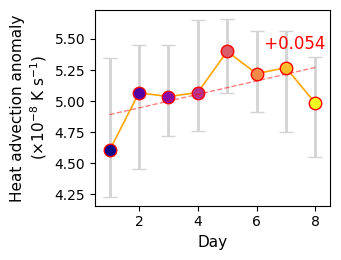

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_HeatAdvection_Days1to8_LinearFit_300dpi.png
Linear fit: slope=0.0543286, intercept=4.83635  (units after scaling)


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Standing_HeatAdvection_Days1to8_LinearFit_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

med = df["heat_p50"].values * SCALE
q25 = df["heat_p25"].values * SCALE
q75 = df["heat_p75"].values * SCALE

# ============================================================
# LINEAR FIT (RED LINE)
# ============================================================
# y = slope*x + intercept
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

# --- errorbars + points
for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt='o',
        color=c,
        ecolor='lightgrey',
        markersize=9,
        markerfacecolor=c,
        markeredgecolor='red',
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# --- connect medians (orange)
ax.plot(days, med, color='orange', linewidth=1.2, zorder=2)

# --- linear trend line (RED)
ax.plot(days, fit_y, color='red', linewidth=1, zorder=4,linestyle='--', alpha=0.5)

# ============================================================
# WRITE SLOPE + EQUATION ON PLOT
# ============================================================
eq_text = f" +{slope:.2g} "
ax.text(
    0.7, 0.87, eq_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    color="red"
)

# ============================================================
# AXES LABELS
# ============================================================
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel(
    "Heat advection anomaly\n($\\times 10^{-8}$ K s$^{-1}$)",
    fontsize=11
)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE (300 DPI)
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g}  (units after scaling)")


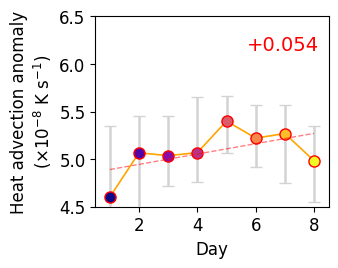

Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_HeatAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png
Linear fit: slope=0.0543286, intercept=4.83635 (after scaling)


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Standing_HeatAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png")

# figure size 
FIG_W, FIG_H = 3.2, 2.5

Y_LIM = (4.5, 6.5)
Y_TICKS = [4.5, 5.0, 5.5, 6.0, 6.5]  # 3 labels (clean)

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].to_numpy(dtype=float)
med  = df["heat_p50"].to_numpy(dtype=float) * SCALE
q25  = df["heat_p25"].to_numpy(dtype=float) * SCALE
q75  = df["heat_p75"].to_numpy(dtype=float) * SCALE

# ============================================================
# LINEAR FIT
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT (same style as before)
# ============================================================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt='o',
        color=c,
        ecolor='lightgrey',
        markersize=8,
        markerfacecolor=c,
        markeredgecolor='red',
        elinewidth=1.8,
        capsize=4,
        zorder=3
    )

# connect medians (orange)
ax.plot(days, med, color='orange', linewidth=1.2, zorder=2)

# linear trend (red dashed)
ax.plot(days, fit_y, color='red', linewidth=1, linestyle='--', alpha=0.5, zorder=4)

# slope text
ax.text(
    0.65, 0.9, f"{slope:+.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="red"
)

# ============================================================
# AXES (keep labels like previous)
# ============================================================
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel("Heat advection anomaly\n($\\times 10^{-8}$ K s$^{-1}$)", fontsize=12)

ax.set_xlim(0.5, 8.5)

ax.set_ylim(*Y_LIM)
ax.set_yticks(Y_TICKS)

ax.tick_params(labelsize=12)
ax.grid(False)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0)

plt.tight_layout(pad=0.05)
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g} (after scaling)")


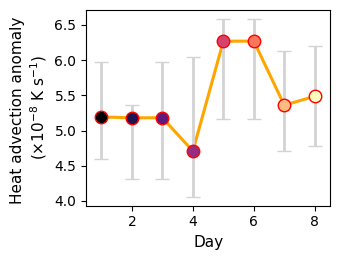

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_300dpi.png


In [91]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Propagating_HeatAdvection_Days1to8_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)]

days = df["day_count"].values.astype(float)

med = df["heat_p50"].values * SCALE
q25 = df["heat_p25"].values * SCALE
q75 = df["heat_p75"].values * SCALE

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.magma
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="red",   # NO outline
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# connect medians
ax.plot(days, med, color="orange", linewidth=2.2, zorder=2)

ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel("Heat advection anomaly \n($\\times 10^{-8}$ K s$^{-1}$)", fontsize=11)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


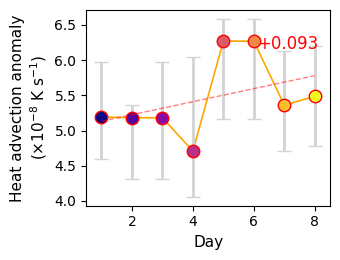

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_LinearFit_300dpi.png
Linear fit: slope=0.092551, intercept=5.04005  (units after scaling)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Propagating_HeatAdvection_Days1to8_LinearFit_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

med = df["heat_p50"].values * SCALE
q25 = df["heat_p25"].values * SCALE
q75 = df["heat_p75"].values * SCALE

# ============================================================
# LINEAR FIT (RED DASHED LINE)
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

# --- error bars + points
for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt='o',
        color=c,
        ecolor='lightgrey',
        markersize=9,
        markerfacecolor=c,
        markeredgecolor='red',
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# --- connect medians (orange)
ax.plot(days, med, color='orange', linewidth=1.2, zorder=2)

# --- linear trend line (red dashed)
ax.plot(
    days, fit_y,
    color='red',
    linewidth=1,
    linestyle='--',
    alpha=0.5,
    zorder=4
)

# ============================================================
# WRITE SLOPE ON PLOT
# ============================================================
eq_text = f"+{slope:.2g}"
ax.text(
    0.7, 0.87, eq_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    color="red"
)

# ============================================================
# AXES LABELS
# ============================================================
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel(
    "Heat advection anomaly\n($\\times 10^{-8}$ K s$^{-1}$)",
    fontsize=11
)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE (300 DPI)
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g}  (units after scaling)")


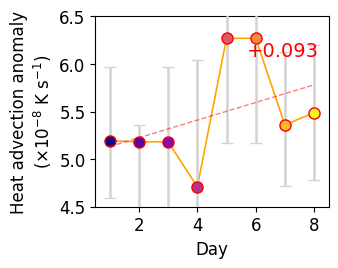

Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png
Linear fit: slope=0.092551, intercept=5.04005 (after scaling)


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS (MATCH STANDING EXACTLY)
# ============================================================
SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Propagating_HeatAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png")

# SAME plot size
FIG_W, FIG_H = 3.2, 2.5

# SAME y-axis range + ticks
Y_LIM = (4.5, 6.5)
Y_TICKS = [4.5, 5.0, 5.5, 6.0, 6.5]

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].to_numpy(dtype=float)
med  = df["heat_p50"].to_numpy(dtype=float) * SCALE
q25  = df["heat_p25"].to_numpy(dtype=float) * SCALE
q75  = df["heat_p75"].to_numpy(dtype=float) * SCALE

# ============================================================
# LINEAR FIT
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT (MATCH STANDING)
# ============================================================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt='o',
        color=c,
        ecolor='lightgrey',
        markersize=8,          # SAME
        markerfacecolor=c,
        markeredgecolor='red',
        elinewidth=1.8,        # SAME
        capsize=4,             # SAME
        zorder=3
    )

# connect medians (orange) — SAME
ax.plot(days, med, color='orange', linewidth=1.2, zorder=2)

# linear trend (red dashed) — SAME
ax.plot(days, fit_y, color='red', linewidth=1, linestyle='--', alpha=0.5, zorder=4)

# slope text — SAME (position, font, format)
ax.text(
    0.65, 0.87, f"{slope:+.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="red"
)

# ============================================================
# AXES (MATCH STANDING)
# ============================================================
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel("Heat advection anomaly\n($\\times 10^{-8}$ K s$^{-1}$)", fontsize=12)

ax.set_xlim(0.5, 8.5)

ax.set_ylim(*Y_LIM)
ax.set_yticks(Y_TICKS)

ax.tick_params(labelsize=12)
ax.grid(False)

# transparent background — SAME
ax.set_facecolor("none")
fig.patch.set_alpha(0)

# ============================================================
# SAVE
# ============================================================
plt.tight_layout(pad=0.05)
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g} (after scaling)")


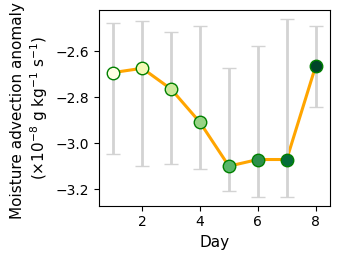

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_MoistAdvection_Days1to8_300dpi.png


In [95]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Standing_MoistAdvection_Days1to8_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)]

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s, then ×1e8
moist_p50_g = df["moist_p50"].values * 1000.0
moist_p25_g = df["moist_p25"].values * 1000.0
moist_p75_g = df["moist_p75"].values * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",   # NO outline
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# connect medians
ax.plot(days, med, color="orange", linewidth=2.2, zorder=2)

ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel("Moisture advection anomaly \n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)", fontsize=11)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


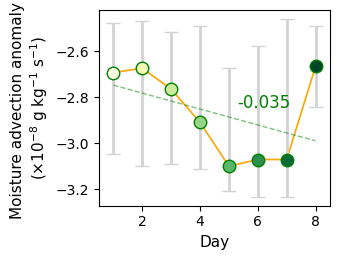

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_MoistAdvection_Days1to8_LinearFit_300dpi.png
Linear fit: slope=-0.0346931, intercept=-2.71241  (units after scaling)


In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Standing_MoistAdvection_Days1to8_LinearFit_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s, then ×1e8
moist_p50_g = df["moist_p50"].values * 1000.0
moist_p25_g = df["moist_p25"].values * 1000.0
moist_p75_g = df["moist_p75"].values * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# LINEAR FIT (RED DASHED LINE)
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# --- connect medians (orange)
ax.plot(days, med, color="orange", linewidth=1.2, zorder=2)

# --- linear trend line (red dashed)
ax.plot(days, fit_y, color="green", linewidth=1, linestyle="--", alpha=0.5, zorder=4)

# --- slope text 
eq_text = f"{slope:.2g}"
ax.text(
    0.6, 0.57, eq_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    color="green"
)

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel(
    "Moisture advection anomaly \n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=11
)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g}  (units after scaling)")


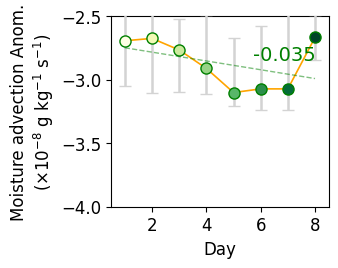

Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png
Linear fit: slope=-0.0346931, intercept=-2.71241 (after scaling)


In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Standing_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png")

FIG_W, FIG_H = 3.2, 2.5

Y_TICKS = [-2.5, -3.0, -3.5, -4.0]
Y_LIM = (min(Y_TICKS), max(Y_TICKS))  # (-4.0, -2.5) after sorting below

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].to_numpy(dtype=float)

# moisture advection: kg/kg/s → g/kg/s, then ×1e8
moist_p50_g = df["moist_p50"].to_numpy(dtype=float) * 1000.0
moist_p25_g = df["moist_p25"].to_numpy(dtype=float) * 1000.0
moist_p75_g = df["moist_p75"].to_numpy(dtype=float) * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# LINEAR FIT
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m, yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=8,
        markerfacecolor=c,
        markeredgecolor="green",
        elinewidth=1.8,
        capsize=4,
        zorder=3
    )

# connect medians (orange)
ax.plot(days, med, color="orange", linewidth=1.2, zorder=2)

# trend (green dashed)
ax.plot(days, fit_y, color="green", linewidth=1, linestyle="--", alpha=0.5, zorder=4)

# slope text (same style)
ax.text(
    0.65, 0.85, f"{slope:+.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="green"
)

# ============================================================
# AXES (same label style)
# ============================================================
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel("Moisture advection Anom.\n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)", fontsize=12)

ax.set_xlim(0.5, 8.5)

# IMPORTANT: ylim must be (lower, upper)
ax.set_ylim(min(Y_TICKS), max(Y_TICKS))
ax.set_yticks(Y_TICKS)

ax.tick_params(labelsize=12)
ax.grid(False)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0)

plt.tight_layout(pad=0.05)
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g} (after scaling)")


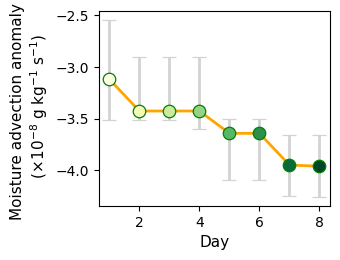

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

SCALE = 1e8  # rescale from ~1e-8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
df = pd.read_excel(path).sort_values("day_count")

days = df["day_count"].values.astype(float)

# ---- moisture advection: convert from kg/kg/s → g/kg/s, then scale ×1e8 ----
moist_p50_kg = df["moist_p50"].values      # kg/kg/s
moist_p25_kg = df["moist_p25"].values
moist_p75_kg = df["moist_p75"].values

moist_p50_g = moist_p50_kg * 1000.0       # g/kg/s
moist_p25_g = moist_p25_kg * 1000.0
moist_p75_g = moist_p75_kg * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

fig, ax = plt.subplots(figsize=(3.5, 2.7))

# plot errorbars (25–75) + median point, one day at a time with its own color
for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])
    
    ax.errorbar(
        d, m, yerr=yerr,
        fmt='o',
        color=c,
        ecolor='lightgrey',
        markersize=9,
        markerfacecolor=c,
        markeredgecolor='green',
        markeredgewidth=0.9,
        elinewidth=2,
        capsize=5
    )

# connect medians with a single orange line
ax.plot(days, med, color='orange', linewidth=2, zorder=2)

ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel("Moisture advection anomaly \n ($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)", fontsize=11)

plt.tight_layout()
plt.show()


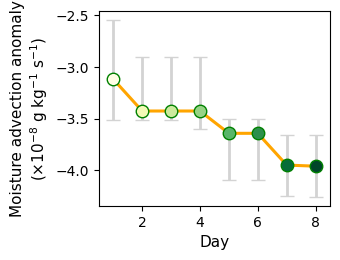

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_MoistAdvection_Days1to8_300dpi.png


In [100]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Propagating_MoistAdvection_Days1to8_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)]

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s → ×1e8
moist_p50 = df["moist_p50"].values * 1000.0 * SCALE
moist_p25 = df["moist_p25"].values * 1000.0 * SCALE
moist_p75 = df["moist_p75"].values * 1000.0 * SCALE

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, moist_p50, moist_p25, moist_p75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",   # NO outline
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# ---- connect medians
ax.plot(days, moist_p50, color="orange", linewidth=2.2, zorder=2)

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel(
    "Moisture advection anomaly\n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=11
)

ax.set_xlim(0.5, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE (300 DPI)
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


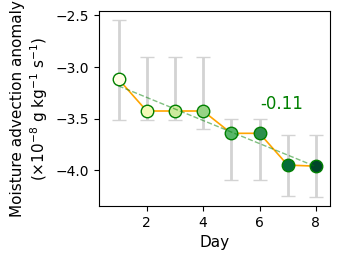

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_MoistAdvection_Days1to8_LinearFit_300dpi.png
Linear fit: slope=-0.111404, intercept=-3.07158  (units after scaling)


In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Propagating_MoistAdvection_Days1to8_LinearFit_300dpi.png")

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s → ×1e8
moist_p50_g = df["moist_p50"].values * 1000.0
moist_p25_g = df["moist_p25"].values * 1000.0
moist_p75_g = df["moist_p75"].values * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# LINEAR FIT (RED DASHED LINE)
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

# ---- error bars + points
for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# ---- connect medians (orange)
ax.plot(days, med, color="orange", linewidth=1.2, zorder=2)

# ---- linear trend line (red dashed)
ax.plot(
    days, fit_y,
    color="green",
    linewidth=1,
    linestyle="--",
    alpha=0.5,
    zorder=4
)

# ---- slope annotation (same style as others)
eq_text = f"{slope:.2g}"
ax.text(
    0.7, 0.57, eq_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    color="green"
)

# ============================================================
# AXES
# ============================================================
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel(
    "Moisture advection anomaly\n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=11
)

ax.set_xlim(0.3, 8.5)
ax.tick_params(labelsize=10)

# ============================================================
# SAVE (300 DPI)
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g}  (units after scaling)")


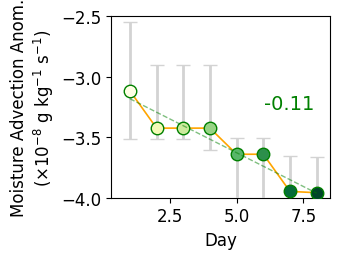

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png
Linear fit: slope=-0.111404, intercept=-3.07158 (after scaling)


In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Propagating_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png")

# FIXED y-axis (same as standing)
Y_TICKS = [-2.5, -3.0, -3.5, -4.0]
Y_LIM = (min(Y_TICKS), max(Y_TICKS))

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s → ×1e8
moist_p50_g = df["moist_p50"].values * 1000.0
moist_p25_g = df["moist_p25"].values * 1000.0
moist_p75_g = df["moist_p75"].values * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# LINEAR FIT
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# connect medians
ax.plot(days, med, color="orange", linewidth=1.2, zorder=2)

# trend line
ax.plot(days, fit_y, color="green", linewidth=1, linestyle="--", alpha=0.5, zorder=4)

# slope text
ax.text(
    0.7, 0.57, f"{slope:.2g}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="green"
)

# ============================================================
# AXES (FIXED NEGATIVE SCALE)
# ============================================================
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel(
    "Moisture Advection Anom.\n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=12
)

ax.set_xlim(0.3, 8.5)

# 🔥 THIS IS THE KEY PART
ax.set_ylim(min(Y_TICKS), max(Y_TICKS))
ax.set_yticks(Y_TICKS)

ax.tick_params(labelsize=12)
ax.grid(False)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0)

# ============================================================
# SAVE
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g} (after scaling)")


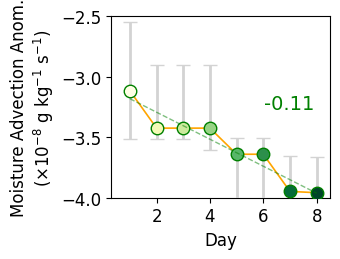

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png
Linear fit: slope=-0.111404, intercept=-3.07158 (after scaling)


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
SCALE = 1e8

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Propagating_MoistAdvection_Days1to8_LinearFit_300dpi_fixedTicks.png")

# FIXED y-axis (same as standing)
Y_TICKS = [-2.5, -3.0, -3.5, -4.0]
Y_LIM = (min(Y_TICKS), max(Y_TICKS))

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================
df = pd.read_excel(path).sort_values("day_count")
df = df[(df["day_count"] >= 1) & (df["day_count"] <= 8)].copy()

days = df["day_count"].values.astype(float)

# ---- moisture advection: kg/kg/s → g/kg/s → ×1e8
moist_p50_g = df["moist_p50"].values * 1000.0
moist_p25_g = df["moist_p25"].values * 1000.0
moist_p75_g = df["moist_p75"].values * 1000.0

med = moist_p50_g * SCALE
q25 = moist_p25_g * SCALE
q75 = moist_p75_g * SCALE

# ============================================================
# LINEAR FIT
# ============================================================
slope, intercept = np.polyfit(days, med, 1)
fit_y = slope * days + intercept

# ============================================================
# COLORMAP
# ============================================================
cmap = plt.cm.YlGn
norm = mpl.colors.Normalize(vmin=days.min(), vmax=days.max())

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.7))

for d, m, lo, hi in zip(days, med, q25, q75):
    c = cmap(norm(d))
    yerr = np.array([[m - lo], [hi - m]])

    ax.errorbar(
        d, m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="green",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# connect medians
ax.plot(days, med, color="orange", linewidth=1.2, zorder=2)

# trend line
ax.plot(days, fit_y, color="green", linewidth=1, linestyle="--", alpha=0.5, zorder=4)

# slope text
ax.text(
    0.7, 0.57, f"{slope:.2g}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="green"
)

# ============================================================
# AXES (FIXED NEGATIVE SCALE)
# ============================================================
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel(
    "Moisture Advection Anom.\n($\\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=12
)

ax.set_xlim(0.3, 8.5)
ax.set_xticks([2, 4, 6, 8])

# THIS IS THE KEY PART
ax.set_ylim(min(Y_TICKS), max(Y_TICKS))
ax.set_yticks(Y_TICKS)

ax.tick_params(labelsize=12)
ax.grid(False)

# transparent background
ax.set_facecolor("none")
fig.patch.set_alpha(0)

# ============================================================
# SAVE
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)
print(f"Linear fit: slope={slope:.6g}, intercept={intercept:.6g} (after scaling)")


In [112]:
import xarray as xr

path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\q_adv_850_daily_anom_1982_2019.nc"

# Read the NetCDF file
ds = xr.open_dataset(path)

# Print dataset summary
print(ds)



<xarray.Dataset> Size: 584MB
Dimensions:         (lat: 73, lon: 144, time: 13879)
Coordinates:
    level           float32 4B ...
  * lat             (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon             (lon) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * time            (time) datetime64[ns] 111kB 1982-01-01 ... 2019-12-31
    dayofyear       (time) int64 111kB ...
Data variables:
    q_adv_850_anom  (time, lat, lon) float32 584MB ...


In [107]:
import xarray as xr
import pandas as pd
import numpy as np

# -----------------------------
# 1. PATHS & SETTINGS
# -----------------------------
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_Z500max.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\hgt_500hPa_1982_2019_daily_anom.nc"
VAR_NAME  = "hgt_500_anom"    # variable name in NetCDF
RADIUS_KM = 1000.0
EARTH_RADIUS_KM = 6371.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def lon_to_0_360(lon_deg):
    return lon_deg % 360.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# -----------------------------
# 3. LOAD NETCDF ONCE
# -----------------------------
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not in dataset: {list(ds.data_vars)}")

field = ds[VAR_NAME]        # (time, lat, lon)
time_da = ds["time"]
lat_da  = ds["lat"]
lon_da  = ds["lon"]

lat_vals = lat_da.values
lon_vals = lon_da.values

# longitude convention
lon_is_0360 = lon_vals.min() >= 0

# 2D grids (in NetCDF's own lon convention)
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# build a lookup: date -> index in time dimension
time_index = pd.to_datetime(time_da.values)
date_to_idx = {t.date(): i for i, t in enumerate(time_index)}

# -----------------------------
# 4. LOAD EXCEL TABLE
# -----------------------------
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# -----------------------------
# 5. LOOP OVER ROWS
# -----------------------------
zmax_vals = []

for idx, row in df.iterrows():
    date_ts = row["Date"]
    if pd.isna(date_ts):
        zmax_vals.append(0.0)
        continue

    key_date = date_ts.date()
    if key_date not in date_to_idx:
        zmax_vals.append(0.0)
        continue

    t_idx = date_to_idx[key_date]
    field_day = field.isel(time=t_idx)   # 2D lat×lon

    center_lat = float(row["Latitude"])
    center_lon = float(row["Longitude"])
    center_lon_used = lon_to_0_360(center_lon) if lon_is_0360 else center_lon

    # distance and mask
    dist_km = haversine_km(center_lat, center_lon_used, lat2d, lon2d)
    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        zmax_vals.append(0.0)
        continue

    vals = field_day.values
    vals_masked = np.where(mask, vals, np.nan)

    if np.all(np.isnan(vals_masked)):
        zmax_vals.append(0.0)
        continue

    vmax = np.nanmax(vals_masked)

    # if max is negative or zero → set 0
    if vmax <= 0:
        zmax_vals.append(0.0)
    else:
        zmax_vals.append(float(vmax))

# -----------------------------
# 6. ADD NEW COLUMN & SAVE
# -----------------------------
df["Z500_max_value_1000km"] = zmax_vals

# keep Date as pure date in Excel
df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_with_Z500max.xlsx


In [3]:
import xarray as xr
import pandas as pd
import numpy as np

# -----------------------------
# 1. PATHS & SETTINGS
# -----------------------------
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_Z500max.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\hgt_500hPa_1982_2019_daily_anom.nc"
VAR_NAME  = "hgt_500_anom"    # variable name in NetCDF
RADIUS_KM = 1000.0
EARTH_RADIUS_KM = 6371.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def lon_to_0_360(lon_deg):
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert 0–360 to -180–180."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# -----------------------------
# 3. LOAD NETCDF ONCE
# -----------------------------
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not in dataset: {list(ds.data_vars)}")

field = ds[VAR_NAME]        # (time, lat, lon)
time_da = ds["time"]
lat_da  = ds["lat"]
lon_da  = ds["lon"]

lat_vals = lat_da.values
lon_vals = lon_da.values

# longitude convention
lon_is_0360 = lon_vals.min() >= 0

# 2D grids (in NetCDF's own lon convention)
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# build a lookup: date -> index in time dimension
time_index = pd.to_datetime(time_da.values)
date_to_idx = {t.date(): i for i, t in enumerate(time_index)}

# -----------------------------
# 4. LOAD EXCEL TABLE
# -----------------------------
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# -----------------------------
# 5. LOOP OVER ROWS
# -----------------------------
zmax_vals = []
zmax_lats = []
zmax_lons = []

for idx, row in df.iterrows():
    date_ts = row["Date"]
    if pd.isna(date_ts):
        zmax_vals.append(0.0)
        zmax_lats.append(np.nan)
        zmax_lons.append(np.nan)
        continue

    key_date = date_ts.date()
    if key_date not in date_to_idx:
        zmax_vals.append(0.0)
        zmax_lats.append(np.nan)
        zmax_lons.append(np.nan)
        continue

    t_idx = date_to_idx[key_date]
    field_day = field.isel(time=t_idx)   # 2D lat×lon

    center_lat = float(row["Latitude"])
    center_lon = float(row["Longitude"])
    center_lon_used = lon_to_0_360(center_lon) if lon_is_0360 else center_lon

    # distance and mask
    dist_km = haversine_km(center_lat, center_lon_used, lat2d, lon2d)
    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        zmax_vals.append(0.0)
        zmax_lats.append(np.nan)
        zmax_lons.append(np.nan)
        continue

    vals = field_day.values
    vals_masked = np.where(mask, vals, np.nan)

    # if everything is NaN inside the mask
    if np.all(np.isnan(vals_masked)):
        zmax_vals.append(0.0)
        zmax_lats.append(np.nan)
        zmax_lons.append(np.nan)
        continue

    vmax = np.nanmax(vals_masked)

    # if max is negative or zero → set 0 and no position
    if vmax <= 0:
        zmax_vals.append(0.0)
        zmax_lats.append(np.nan)
        zmax_lons.append(np.nan)
    else:
        # position of the max inside the 1000 km circle
        flat_idx = np.nanargmax(vals_masked)
        i_lat, i_lon = np.unravel_index(flat_idx, vals_masked.shape)

        lat_max = float(lat_vals[i_lat])
        lon_max = float(lon_vals[i_lon])

        # convert lon back to -180–180 if dataset is 0–360
        if lon_is_0360:
            lon_max_out = lon_to_minus180_180(lon_max)
        else:
            lon_max_out = lon_max

        zmax_vals.append(float(vmax))
        zmax_lats.append(lat_max)
        zmax_lons.append(lon_max_out)

# -----------------------------
# 6. ADD NEW COLUMNS & SAVE
# -----------------------------
df["Z500_max_value_1000km"] = zmax_vals
df["Z500_max_lat_1000km"]   = zmax_lats
df["Z500_max_lon_1000km"]   = zmax_lons

# keep Date as pure date in Excel
df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_with_Z500max.xlsx


In [4]:
import xarray as xr 
import pandas as pd
import numpy as np

# -----------------------------
# 1. PATHS & SETTINGS
# -----------------------------
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_CouplingMax.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\NCEP_coupling_p_daily_anom_1982_2019.nc"
VAR_NAME  = "p_anom"
RADIUS_KM = 100.0
EARTH_RADIUS_KM = 6371.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def lon_to_0_360(lon_deg):
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert 0–360 to -180–180."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# -----------------------------
# 3. LOAD NETCDF ONCE
# -----------------------------
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not in dataset: {list(ds.data_vars)}")

field   = ds[VAR_NAME]        # (time, lat, lon)
time_da = ds["time"]
lat_da  = ds["lat"]
lon_da  = ds["lon"]

lat_vals = lat_da.values
lon_vals = lon_da.values

# lon is definitely 0–360
lon_is_0360 = True

# Precompute meshgrid
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# Date → index lookup
time_index = pd.to_datetime(time_da.values)
date_to_idx = {t.date(): i for i, t in enumerate(time_index)}

# -----------------------------
# 4. LOAD EXCEL DATA
# -----------------------------
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# -----------------------------
# 5. LOOP
# -----------------------------
coupling_vals = []
coupling_lats = []
coupling_lons = []

for idx, row in df.iterrows():
    date_ts = row["Date"]
    if pd.isna(date_ts):
        coupling_vals.append(0.0)
        coupling_lats.append(np.nan)
        coupling_lons.append(np.nan)
        continue

    key_date = date_ts.date()
    if key_date not in date_to_idx:
        coupling_vals.append(0.0)
        coupling_lats.append(np.nan)
        coupling_lons.append(np.nan)
        continue

    t_idx = date_to_idx[key_date]
    field_day = field.isel(time=t_idx)   # 2D (lat, lon)

    center_lat = float(row["Latitude"])
    center_lon = float(row["Longitude"])
    center_lon_used = lon_to_0_360(center_lon)

    # Distance mask
    dist_km = haversine_km(center_lat, center_lon_used, lat2d, lon2d)
    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        coupling_vals.append(0.0)
        coupling_lats.append(np.nan)
        coupling_lons.append(np.nan)
        continue

    vals = field_day.values
    vals_masked = np.where(mask, vals, np.nan)

    if np.all(np.isnan(vals_masked)):
        coupling_vals.append(0.0)
        coupling_lats.append(np.nan)
        coupling_lons.append(np.nan)
        continue

    vmax = np.nanmax(vals_masked)

    # If max is <= 0 → treat as no positive signal
    if vmax <= 0:
        coupling_vals.append(0.0)
        coupling_lats.append(np.nan)
        coupling_lons.append(np.nan)
    else:
        # location of maximum inside mask
        flat_idx = np.nanargmax(vals_masked)
        i_lat, i_lon = np.unravel_index(flat_idx, vals_masked.shape)

        lat_max = float(lat_vals[i_lat])
        lon_max = float(lon_vals[i_lon])

        # convert back to -180–180 for output
        lon_max_out = lon_to_minus180_180(lon_max) if lon_is_0360 else lon_max

        coupling_vals.append(float(vmax))
        coupling_lats.append(lat_max)
        coupling_lons.append(lon_max_out)

# -----------------------------
# 6. SAVE
# -----------------------------
df["Coupling_max_value_100km"] = coupling_vals
df["Coupling_max_lat_100km"]   = coupling_lats
df["Coupling_max_lon_100km"]   = coupling_lons

df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_with_CouplingMax.xlsx


In [5]:
import xarray as xr
import pandas as pd
import numpy as np

# -----------------------------
# 1. PATHS & SETTINGS
# -----------------------------
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_HeatAdvMax.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\T_adv_850_daily_anom_1982_2019.nc"
VAR_NAME  = "T_adv_850_anom"   # or "T_adv_850_day_anom" 
RADIUS_KM = 100.0
EARTH_RADIUS_KM = 6371.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def lon_to_0_360(lon_deg):
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert 0–360 to -180–180."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# -----------------------------
# 3. LOAD NETCDF ONCE
# -----------------------------
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not in dataset: {list(ds.data_vars)}")

field   = ds[VAR_NAME]        # (time, lat, lon)
time_da = ds["time"]
lat_da  = ds["lat"]
lon_da  = ds["lon"]

lat_vals = lat_da.values
lon_vals = lon_da.values

# lon is 0–360 in this file
lon_is_0360 = True

# Precompute meshgrid
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# Date → index lookup
time_index = pd.to_datetime(time_da.values)
date_to_idx = {t.date(): i for i, t in enumerate(time_index)}

# -----------------------------
# 4. LOAD EXCEL DATA
# -----------------------------
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# -----------------------------
# 5. LOOP OVER ROWS
# -----------------------------
heatadv_vals = []
heatadv_lats = []
heatadv_lons = []

for idx, row in df.iterrows():
    date_ts = row["Date"]
    if pd.isna(date_ts):
        heatadv_vals.append(0.0)
        heatadv_lats.append(np.nan)
        heatadv_lons.append(np.nan)
        continue

    key_date = date_ts.date()
    if key_date not in date_to_idx:
        heatadv_vals.append(0.0)
        heatadv_lats.append(np.nan)
        heatadv_lons.append(np.nan)
        continue

    t_idx = date_to_idx[key_date]
    field_day = field.isel(time=t_idx)   # 2D lat×lon

    center_lat = float(row["Latitude"])
    center_lon = float(row["Longitude"])
    center_lon_used = lon_to_0_360(center_lon)

    # Distance mask
    dist_km = haversine_km(center_lat, center_lon_used, lat2d, lon2d)
    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        heatadv_vals.append(0.0)
        heatadv_lats.append(np.nan)
        heatadv_lons.append(np.nan)
        continue

    vals = field_day.values
    vals_masked = np.where(mask, vals, np.nan)

    if np.all(np.isnan(vals_masked)):
        heatadv_vals.append(0.0)
        heatadv_lats.append(np.nan)
        heatadv_lons.append(np.nan)
        continue

    vmax = np.nanmax(vals_masked)

    # If max is <= 0 → treat as no positive signal
    if vmax <= 0:
        heatadv_vals.append(0.0)
        heatadv_lats.append(np.nan)
        heatadv_lons.append(np.nan)
    else:
        # location of maximum inside mask
        flat_idx = np.nanargmax(vals_masked)
        i_lat, i_lon = np.unravel_index(flat_idx, vals_masked.shape)

        lat_max = float(lat_vals[i_lat])
        lon_max = float(lon_vals[i_lon])

        # convert back to -180–180 for output
        lon_max_out = lon_to_minus180_180(lon_max) if lon_is_0360 else lon_max

        heatadv_vals.append(float(vmax))
        heatadv_lats.append(lat_max)
        heatadv_lons.append(lon_max_out)

# -----------------------------
# 6. SAVE
# -----------------------------
df["HeatAdv_max_value_100km"] = heatadv_vals
df["HeatAdv_max_lat_100km"]   = heatadv_lats
df["HeatAdv_max_lon_100km"]   = heatadv_lons

df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_with_HeatAdvMax.xlsx


In [6]:
import xarray as xr
import pandas as pd
import numpy as np

# -----------------------------
# 1. PATHS & SETTINGS
# -----------------------------
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_MoistAdvMin.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\q_adv_850_daily_anom_1982_2019.nc"
VAR_NAME  = "q_adv_850_anom"   # moisture advection anomalies
RADIUS_KM = 100.0
EARTH_RADIUS_KM = 6371.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def lon_to_0_360(lon_deg):
    return lon_deg % 360.0

def lon_to_minus180_180(lon_deg):
    """Convert 0–360 to -180–180."""
    return ((lon_deg + 180.0) % 360.0) - 180.0

def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# -----------------------------
# 3. LOAD NETCDF ONCE
# -----------------------------
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not in dataset: {list(ds.data_vars)}")

field   = ds[VAR_NAME]        # (time, lat, lon)
time_da = ds["time"]
lat_da  = ds["lat"]
lon_da  = ds["lon"]

lat_vals = lat_da.values
lon_vals = lon_da.values

# lon is 0–360
lon_is_0360 = True

# Precompute meshgrid
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# Date → index lookup
time_index = pd.to_datetime(time_da.values)
date_to_idx = {t.date(): i for i, t in enumerate(time_index)}

# -----------------------------
# 4. LOAD EXCEL DATA
# -----------------------------
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# -----------------------------
# 5. LOOP OVER ROWS
# -----------------------------
moistadv_vals = []
moistadv_lats = []
moistadv_lons = []

for idx, row in df.iterrows():
    date_ts = row["Date"]
    if pd.isna(date_ts):
        moistadv_vals.append(0.0)
        moistadv_lats.append(np.nan)
        moistadv_lons.append(np.nan)
        continue

    key_date = date_ts.date()
    if key_date not in date_to_idx:
        moistadv_vals.append(0.0)
        moistadv_lats.append(np.nan)
        moistadv_lons.append(np.nan)
        continue

    t_idx = date_to_idx[key_date]
    field_day = field.isel(time=t_idx)   # 2D lat×lon

    center_lat = float(row["Latitude"])
    center_lon = float(row["Longitude"])
    center_lon_used = lon_to_0_360(center_lon)

    # Distance mask
    dist_km = haversine_km(center_lat, center_lon_used, lat2d, lon2d)
    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        moistadv_vals.append(0.0)
        moistadv_lats.append(np.nan)
        moistadv_lons.append(np.nan)
        continue

    vals = field_day.values
    vals_masked = np.where(mask, vals, np.nan)

    if np.all(np.isnan(vals_masked)):
        moistadv_vals.append(0.0)
        moistadv_lats.append(np.nan)
        moistadv_lons.append(np.nan)
        continue

    # most negative anomaly in radius
    vmin = np.nanmin(vals_masked)

    # if min is >= 0 → treat as no negative signal
    if vmin >= 0:
        moistadv_vals.append(0.0)
        moistadv_lats.append(np.nan)
        moistadv_lons.append(np.nan)
    else:
        # location of minimum inside mask
        flat_idx = np.nanargmin(vals_masked)
        i_lat, i_lon = np.unravel_index(flat_idx, vals_masked.shape)

        lat_min = float(lat_vals[i_lat])
        lon_min = float(lon_vals[i_lon])

        # convert back to -180–180 for output
        lon_min_out = lon_to_minus180_180(lon_min) if lon_is_0360 else lon_min

        moistadv_vals.append(float(vmin))
        moistadv_lats.append(lat_min)
        moistadv_lons.append(lon_min_out)

# -----------------------------
# 6. SAVE
# -----------------------------
df["MoistAdv_min_value_100km"] = moistadv_vals
df["MoistAdv_min_lat_100km"]   = moistadv_lats
df["MoistAdv_min_lon_100km"]   = moistadv_lons

df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_with_MoistAdvMin.xlsx


In [9]:
import pandas as pd
import os

base_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model"

f_z500   = os.path.join(base_dir, "Daily_Summary_Continent_with_Z500max.xlsx")
f_coup   = os.path.join(base_dir, "Daily_Summary_Continent_with_CouplingMax.xlsx")
f_heat   = os.path.join(base_dir, "Daily_Summary_Continent_with_HeatAdvMax.xlsx")
f_moist  = os.path.join(base_dir, "Daily_Summary_Continent_with_MoistAdvMin.xlsx")

# ---- read all, ensure Date is datetime ----
df_z500  = pd.read_excel(f_z500,  parse_dates=["Date"])
df_coup  = pd.read_excel(f_coup,  parse_dates=["Date"])
df_heat  = pd.read_excel(f_heat,  parse_dates=["Date"])
df_moist = pd.read_excel(f_moist, parse_dates=["Date"])

# keep only ID, Date, and the new column from each extra file
df_coup  = df_coup[["Event ID", "Date", "Coupling_max_value_100km"]]
df_heat  = df_heat[["Event ID", "Date", "HeatAdv_max_value_100km"]]
df_moist = df_moist[["Event ID", "Date", "MoistAdv_min_value_100km"]]

# ---- merge step by step on Event ID + Date ----
df_all = df_z500.merge(df_coup,  on=["Event ID", "Date"], how="left")
df_all = df_all.merge(df_heat,  on=["Event ID", "Date"], how="left")
df_all = df_all.merge(df_moist, on=["Event ID", "Date"], how="left")

# make Date just date (no time) for Excel
df_all["Date"] = df_all["Date"].dt.date

out_file = os.path.join(base_dir, "Daily_Summary_Continent_AllVars.xlsx")
df_all.to_excel(out_file, index=False)

print("Saved:", out_file)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars.xlsx


In [8]:
import pandas as pd
import os

base_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model"

f_z500   = os.path.join(base_dir, "Daily_Summary_Continent_with_Z500max.xlsx")
f_coup   = os.path.join(base_dir, "Daily_Summary_Continent_with_CouplingMax.xlsx")
f_heat   = os.path.join(base_dir, "Daily_Summary_Continent_with_HeatAdvMax.xlsx")
f_moist  = os.path.join(base_dir, "Daily_Summary_Continent_with_MoistAdvMin.xlsx")

# ---- read all, ensure Date is datetime ----
df_z500  = pd.read_excel(f_z500,  parse_dates=["Date"])
df_coup  = pd.read_excel(f_coup,  parse_dates=["Date"])
df_heat  = pd.read_excel(f_heat,  parse_dates=["Date"])
df_moist = pd.read_excel(f_moist, parse_dates=["Date"])

# keep only ID, Date, and the new VALUE + POSITION columns from each extra file
df_coup = df_coup[
    [
        "Event ID", "Date",
        "Coupling_max_value_100km",
        "Coupling_max_lat_100km", "Coupling_max_lon_100km"
    ]
]

df_heat = df_heat[
    [
        "Event ID", "Date",
        "HeatAdv_max_value_100km",
        "HeatAdv_max_lat_100km", "HeatAdv_max_lon_100km"
    ]
]

df_moist = df_moist[
    [
        "Event ID", "Date",
        "MoistAdv_min_value_100km",
        "MoistAdv_min_lat_100km", "MoistAdv_min_lon_100km"
    ]
]

# z500 file already has Z500 max value + lat/lon columns
# ---- merge step by step on Event ID + Date ----
df_all = df_z500.merge(df_coup,  on=["Event ID", "Date"], how="left")
df_all = df_all.merge(df_heat,  on=["Event ID", "Date"], how="left")
df_all = df_all.merge(df_moist, on=["Event ID", "Date"], how="left")

# make Date just date (no time) for Excel
df_all["Date"] = df_all["Date"].dt.date

# -----------------------------
# 1) SAVE FULL FILE (values + positions)
# -----------------------------
out_file_all = os.path.join(base_dir, "Daily_Summary_Continent_AllVars.xlsx")
df_all.to_excel(out_file_all, index=False)
print("Saved full file:", out_file_all)

# -----------------------------
# 2) SAVE SEVERITY + LAT/LON POSITIONS TO A SEPARATE FILE
# -----------------------------
pos_cols = [
    "Event ID", "Date",

    # severity (value) columns
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",

    # position columns
    "Z500_max_lat_1000km",  "Z500_max_lon_1000km",
    "Coupling_max_lat_100km", "Coupling_max_lon_100km",
    "HeatAdv_max_lat_100km",  "HeatAdv_max_lon_100km",
    "MoistAdv_min_lat_100km", "MoistAdv_min_lon_100km",
]

# keep only columns that actually exist (safe if names differ slightly)
pos_cols_existing = [c for c in pos_cols if c in df_all.columns]

df_pos = df_all[pos_cols_existing].copy()

out_file_pos = os.path.join(base_dir, "Daily_Summary_Continent_AllPositions.xlsx")
df_pos.to_excel(out_file_pos, index=False)
print("Saved positions + severity file:", out_file_pos)


Saved full file: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars.xlsx
Saved positions + severity file: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllPositions.xlsx


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from math import cos, radians

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------
esa_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Landcover\ESA.nc"
excel_in   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars.xlsx"
excel_out  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_LULC100km.xlsx"

# radius for neighbourhood (km)
RADIUS_KM = 100.0

# --------------------------------------------------------
# 1. LOAD EXCEL
# --------------------------------------------------------
df = pd.read_excel(excel_in)

# Check that these column names match exactly:
# 'Latitude' and 'Longitude' (change here if needed)
lat_col = "Latitude"
lon_col = "Longitude"

# --------------------------------------------------------
# 2. OPEN ESA LAND-COVER (LAZY, WITH CHUNKS)
# --------------------------------------------------------
ds = xr.open_dataset(esa_path, chunks={"lat": 1000, "lon": 1000})
lc = ds["lccs_class"].isel(time=0)   # (lat, lon), uint8

# --------------------------------------------------------
# 3. FUNCTION: DOMINANT CLASS WITHIN 100 km
# --------------------------------------------------------
def dominant_lulc(lat0, lon0, radius_km=RADIUS_KM):
    """
    For a given (lat0, lon0) return the dominant ESA LCCS class
    within radius_km.
    """
    # degrees corresponding to radius
    dlat = radius_km / 111.0
    # avoid division by zero near poles
    dlon = radius_km / (111.0 * max(abs(cos(radians(lat0))), 1e-6))

    lat_min = lat0 - dlat
    lat_max = lat0 + dlat
    lon_min = lon0 - dlon
    lon_max = lon0 + dlon

    # Handle longitude wrap if needed
    # Note: lat in ESA CCI is usually descending (90 -> -90), so use slice(lat_max, lat_min)
    sub = lc.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

    if sub.size == 0:
        return np.nan

    # Build lat/lon grids for distance calculation
    lats2d, lons2d = xr.broadcast(sub["lat"], sub["lon"])
    R_earth = 6371.0  # km

    lat_rad = np.deg2rad(lats2d.values)
    lon_rad = np.deg2rad(lons2d.values)
    lat0r = np.deg2rad(lat0)
    lon0r = np.deg2rad(lon0)

    dlatr = lat_rad - lat0r
    dlonr = lon_rad - lon0r

    a = np.sin(dlatr / 2.0) ** 2 + np.cos(lat0r) * np.cos(lat_rad) * np.sin(dlonr / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    dist_km = R_earth * c

    mask = dist_km <= radius_km
    if not np.any(mask):
        return np.nan

    vals = sub.values[mask]

    # Remove possible NaNs
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return np.nan

    # Dominant class = most frequent value
    uniq, counts = np.unique(vals.astype(np.int64), return_counts=True)
    return int(uniq[counts.argmax()])

# --------------------------------------------------------
# 4. APPLY TO ALL ROWS
# --------------------------------------------------------
dom_classes = []
for idx, row in df.iterrows():
    lat0 = float(row[lat_col])
    lon0 = float(row[lon_col])
    dom = dominant_lulc(lat0, lon0)
    dom_classes.append(dom)
    print(f"Row {idx}: lat={lat0:.2f}, lon={lon0:.2f} -> class {dom}")

df["Dominant_LULC_100km"] = dom_classes

# --------------------------------------------------------
# 5. SAVE OUTPUT
# --------------------------------------------------------
df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


C:\Users\Amitesh\AppData\Local\Temp\ipykernel_6708\2998627548.py:29: UserWarning: Failed to load chunk manager entrypoint dask due to No module named 'xarray.core.daskmanager'. Skipping.
  ds = xr.open_dataset(esa_path, chunks={"lat": 1000, "lon": 1000})
C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


Row 0: lat=-28.00, lon=20.00 -> class 120
Row 1: lat=-30.51, lon=20.84 -> class 150
Row 2: lat=-30.11, lon=21.52 -> class 120
Row 3: lat=-28.84, lon=22.19 -> class 120
Row 4: lat=-28.22, lon=22.69 -> class 120
Row 5: lat=-26.76, lon=23.35 -> class 120
Row 6: lat=-27.86, lon=21.91 -> class 120
Row 7: lat=-29.10, lon=20.00 -> class 120
Row 8: lat=-28.67, lon=20.73 -> class 120
Row 9: lat=-28.00, lon=21.11 -> class 120
Row 10: lat=-28.00, lon=21.13 -> class 120
Row 11: lat=-24.00, lon=21.23 -> class 120
Row 12: lat=-24.96, lon=19.56 -> class 120
Row 13: lat=-26.62, lon=20.98 -> class 120
Row 14: lat=-26.76, lon=21.80 -> class 120
Row 15: lat=-27.24, lon=22.62 -> class 120
Row 16: lat=-26.67, lon=22.41 -> class 120
Row 17: lat=-25.18, lon=22.31 -> class 120
Row 18: lat=-24.00, lon=21.27 -> class 120
Row 19: lat=-27.17, lon=20.80 -> class 120
Row 20: lat=-26.79, lon=20.06 -> class 120
Row 21: lat=-26.67, lon=20.13 -> class 120
Row 22: lat=-26.17, lon=20.06 -> class 120
Row 23: lat=-25.85, l

In [10]:
import pandas as pd

# Load file
path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_LULC100km.xlsx"
df = pd.read_excel(path)

# ------- RECLASSIFICATION DICTIONARY -------
reclass = {
    # Forest
    50: 1, 60: 1, 70: 1, 80: 1, 90: 1, 100: 1,

    # Grassland / Shrubland / Herbaceous
    110: 2, 120: 2, 130: 2, 140: 2, 150: 2, 180: 2,

    # Agriculture
    10: 3, 20: 3, 30: 3, 40: 3,

    # Urban
    190: 4
}

# Assign '0' for classes not in our 4 categories
df['LULC_Category'] = df['Dominant_LULC_100km'].map(reclass).fillna(0).astype(int)

# Save output
out_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_LULC100km_reclass.xlsx"
df.to_excel(out_path, index=False)

print("Done! Saved:", out_path)


Done! Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_LULC100km_reclass.xlsx


In [11]:
import pandas as pd

# Paths
allvars_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars.xlsx"
lulc_path    = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_LULC100km_reclass.xlsx"

out_path     = allvars_path.replace(".xlsx", "_with_LULC.xlsx")

# -------------------------------
# Load files
# -------------------------------
df_all = pd.read_excel(allvars_path)
df_lulc = pd.read_excel(lulc_path)

# Clean date format
df_all["Date"]  = pd.to_datetime(df_all["Date"])
df_lulc["Date"] = pd.to_datetime(df_lulc["Date"])

# -------------------------------
# Merge on Event ID + Date
# -------------------------------
df_merge = pd.merge(
    df_all,
    df_lulc[["Event ID", "Date", "LULC_Category"]],
    on=["Event ID", "Date"],
    how="left"
)

# -------------------------------
# Save output
# -------------------------------
df_merge.to_excel(out_path, index=False)
print("Saved:", out_path)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC.xlsx


In [13]:
import pandas as pd

# Paths
allvars_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars.xlsx"
lulc_path    = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_LULC100km_reclass.xlsx"

out_path     = allvars_path.replace(".xlsx", "_with_LULC.xlsx")

# -------------------------------
# Load files
# -------------------------------
df_all = pd.read_excel(allvars_path)
df_lulc = pd.read_excel(lulc_path)

# Clean date
df_all["Date"]  = pd.to_datetime(df_all["Date"])
df_lulc["Date"] = pd.to_datetime(df_lulc["Date"])

# -------------------------------
# FIX: Shift category from 0–6 → 1–7
# -------------------------------
df_lulc["LULC_Category"] = df_lulc["LULC_Category"] + 1

# -------------------------------
# Merge on Event ID + Date
# -------------------------------
df_merge = pd.merge(
    df_all,
    df_lulc[["Event ID", "Date", "LULC_Category"]],
    on=["Event ID", "Date"],
    how="left"
)

# -------------------------------
# Save output
# -------------------------------
df_merge.to_excel(out_path, index=False)
print("Saved:", out_path)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC.xlsx


In [14]:
import xarray as xr

nc_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\ai_2deg.nc"

# Open the dataset
ds = xr.open_dataset(nc_path)

# Print full dataset summary
print(ds)

# (Optional) print only variable names
print("\nData variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

# (Optional) peek at first few values of each data variable
for v in ds.data_vars:
    print(f"\nPreview of variable: {v}")
    print(ds[v].values)


<xarray.Dataset> Size: 67kB
Dimensions:  (lat: 90, lon: 180)
Coordinates:
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 1kB -179.0 -177.0 -175.0 -173.0 ... 175.0 177.0 179.0
Data variables:
    AI       (lat, lon) float32 65kB ...

Data variables: ['AI']
Coordinates: ['lat', 'lon']

Preview of variable: AI
[[0.6956195  0.70203    0.7333803  ... 0.2424641  0.24919114 0.28586268]
 [0.7352097  0.7694144  0.79174274 ... 0.16704431 0.16244839 0.15592986]
 [0.6032529  0.4880142  0.59500045 ... 0.28740293 0.19624217 0.1263811 ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [15]:
import xarray as xr
import pandas as pd
import numpy as np

# =====================================
# 1. PATHS & SETTINGS
# =====================================
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_AI100km.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\ai_2deg.nc"
VAR_NAME  = "AI"
RADIUS_KM = 100.0            # 100 km radius
EARTH_RADIUS_KM = 6371.0

# =====================================
# 2. HELPER: HAVERSINE DISTANCE (km)
# =====================================
def haversine_km(lat0, lon0, lat2d, lon2d):
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat2_rad = np.deg2rad(lat2d)
    lon2_rad = np.deg2rad(lon2d)

    dlat = lat2_rad - lat0_rad
    dlon = lon2_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad)*np.cos(lat2_rad)*np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# =====================================
# 3. LOAD AI NETCDF (2D FIELD)
# =====================================
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not found in dataset: {list(ds.data_vars)}")

field = ds[VAR_NAME]          # (lat, lon)
lat_da = ds["lat"]
lon_da = ds["lon"]

lat_vals = lat_da.values      # 1D
lon_vals = lon_da.values      # 1D  (-179..179)

# Make 2D grids for distance calculation
lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

# =====================================
# 4. LOAD EXCEL TABLE
# =====================================
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]

# Ensure Date is datetime (keep time for now, make pure date at the end)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# =====================================
# 5. LOOP OVER ROWS AND COMPUTE MEDIAN AI
# =====================================
ai_median_vals = []

for idx, row in df.iterrows():
    try:
        center_lat = float(row["Latitude"])
        center_lon = float(row["Longitude"])
    except Exception:
        ai_median_vals.append(np.nan)
        continue

    # Skip if lat/lon missing
    if np.isnan(center_lat) or np.isnan(center_lon):
        ai_median_vals.append(np.nan)
        continue

    # For this AI grid, longitude is already in -180..180, so no conversion needed
    dist_km = haversine_km(center_lat, center_lon, lat2d, lon2d)

    mask = dist_km <= RADIUS_KM
    if not np.any(mask):
        ai_median_vals.append(np.nan)
        continue

    vals = field.values  # 2D array
    vals_masked = np.where(mask, vals, np.nan)

    if np.all(np.isnan(vals_masked)):
        ai_median_vals.append(np.nan)
    else:
        ai_median_vals.append(float(np.nanmedian(vals_masked)))

# =====================================
# 6. ADD COLUMN & SAVE
# =====================================
df["AI_median_100km"] = ai_median_vals  # median aridity index in 100 km radius

# Make Date a pure date (no time) 
df["Date"] = pd.to_datetime(df["Date"]).dt.date

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC_with_AI100km.xlsx


In [17]:
import xarray as xr
import pandas as pd
import numpy as np

# =========================
# 1. PATHS
# =========================
excel_in  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC.xlsx"
excel_out = excel_in.replace(".xlsx", "_with_AInearest.xlsx")

nc_path   = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\ai_2deg.nc"
VAR_NAME  = "AI"
EARTH_RADIUS_KM = 6371.0

# =========================
# 2. HELPER: HAVERSINE
# =========================
def haversine_km(lat0, lon0, lat_arr, lon_arr):
    """
    lat_arr, lon_arr can be 1D arrays; returns distances (km) to each point.
    """
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)
    lat_rad  = np.deg2rad(lat_arr)
    lon_rad  = np.deg2rad(lon_arr)

    dlat = lat_rad - lat0_rad
    dlon = lon_rad - lon0_rad

    a = np.sin(dlat/2.0)**2 + np.cos(lat0_rad) * np.cos(lat_rad) * np.sin(dlon/2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# =========================
# 3. LOAD AI FIELD
# =========================
ds = xr.open_dataset(nc_path)

if VAR_NAME not in ds.data_vars:
    raise ValueError(f"{VAR_NAME} not found in dataset: {list(ds.data_vars)}")

ai = ds[VAR_NAME].values        # (lat, lon)
lat_vals = ds["lat"].values     # 90 values
lon_vals = ds["lon"].values     # 180 values

# treat AI == 0 or NaN as "no aridity value"
valid_mask = (~np.isnan(ai)) & (ai != 0)
valid_ai   = ai[valid_mask]

# coordinates of all valid grid cells
valid_i, valid_j = np.where(valid_mask)
valid_lat = lat_vals[valid_i]
valid_lon = lon_vals[valid_j]

# =========================
# 4. LOAD EXCEL
# =========================
df = pd.read_excel(excel_in)
df.columns = [c.strip() for c in df.columns]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# =========================
# 5. ASSIGN AI VALUE FOR EACH ROW
# =========================
ai_vals = []

for _, row in df.iterrows():
    try:
        lat0 = float(row["Latitude"])
        lon0 = float(row["Longitude"])
    except Exception:
        ai_vals.append(np.nan)
        continue

    if np.isnan(lat0) or np.isnan(lon0):
        ai_vals.append(np.nan)
        continue

    # --- 1) index of nearest grid cell in the 2° grid ---
    i = np.argmin(np.abs(lat_vals - lat0))
    j = np.argmin(np.abs(lon_vals - lon0))
    val = ai[i, j]

    # if that grid cell has a valid AI, use it
    if not np.isnan(val) and val != 0:
        ai_vals.append(float(val))
        continue

    # --- 2) fallback: nearest *valid* grid cell anywhere ---
    dists = haversine_km(lat0, lon0, valid_lat, valid_lon)
    k = np.argmin(dists)
    ai_vals.append(float(valid_ai[k]))

# =========================
# 6. SAVE
# =========================
df["AI_nearest"] = ai_vals
df["Date"] = pd.to_datetime(df["Date"]).dt.date  # keep date tidy

df.to_excel(excel_out, index=False)
print("Saved:", excel_out)


Saved: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC_with_AInearest.xlsx


In [1]:
import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import xgboost as xgb

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC_with_AI100km.xlsx"
base_dir   = os.path.dirname(excel_path)

metrics_out_path   = os.path.join(base_dir, "XGB_TotalSeverity_CV_metrics.xlsx")
pred_out_path      = os.path.join(base_dir, "XGB_TotalSeverity_CV_predictions.xlsx")
feat_imp_out_path  = os.path.join(base_dir, "XGB_TotalSeverity_feature_importance.xlsx")
model_out_path     = os.path.join(base_dir, "XGB_TotalSeverity_model.pkl")

# ------------------------------------------------------------
# 2. READ DATA
# ------------------------------------------------------------
df = pd.read_excel(excel_path, parse_dates=["Date"])

required_cols = [
    "Event ID",
    "Date",
    "Total Severity",
    "Latitude",
    "Longitude",
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "LULC_Category",
    "AI_median_100km"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values(["Event ID", "Date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. CREATE ΔSeverity AND LAG FEATURES
# ------------------------------------------------------------
df["Severity_lag1"]  = df.groupby("Event ID")["Total Severity"].shift(1)
df["Severity_lag3"]  = df.groupby("Event ID")["Total Severity"].shift(3)
df["Delta_Severity"] = df["Total Severity"] - df["Severity_lag1"]

# Predictor lags for climate variables
lag_vars = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km"
]

for v in lag_vars:
    df[f"{v}_lag1"] = df.groupby("Event ID")[v].shift(1)
    df[f"{v}_lag3"] = df.groupby("Event ID")[v].shift(3)

# ------------------------------------------------------------
# 4. DROP ROWS WITH NaN (from lags)
# ------------------------------------------------------------
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 5. EVENT-WISE NORMALIZATION
# ------------------------------------------------------------
scale_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

df_scaled = df.copy()

for eid, group in df.groupby("Event ID"):
    scaler = StandardScaler()
    df_scaled.loc[group.index, scale_cols] = scaler.fit_transform(df.loc[group.index, scale_cols])

df = df_scaled.copy()

# ------------------------------------------------------------
# 6. BUILD FEATURE MATRIX (X) AND TARGET (y)
# ------------------------------------------------------------
feature_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
    "Latitude",
    "Longitude"
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

# One-hot encode LULC
df["LULC_Category"] = df["LULC_Category"].astype(int).astype("category")
df = pd.get_dummies(df, columns=["LULC_Category"], drop_first=True)

# Add LULC columns to feature list
feature_cols = feature_cols + [c for c in df.columns if c.startswith("LULC_Category_")]

X = df[feature_cols].values
y = df["Total Severity"].values
groups = df["Event ID"].values

# ------------------------------------------------------------
# 7. CROSS-VALIDATION (10-fold GroupKFold)
# ------------------------------------------------------------
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)

xgb_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "objective": "reg:squarederror",
    "random_state": 42,
}

fold_results = []
cv_pred = pd.DataFrame({
    "Event_ID": df["Event ID"],
    "Date": df["Date"],
    "Severity_obs": y,
    "Severity_pred": np.nan,
    "fold": np.nan
})

fold_idx = 1

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    y_mean = np.mean(y_test)
    nse = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_mean)**2)

    fold_results.append({
        "fold": fold_idx,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NSE": nse,
        "n_test_samples": len(test_idx)
    })

    cv_pred.loc[test_idx, "fold"] = fold_idx
    cv_pred.loc[test_idx, "Severity_pred"] = y_pred

    print(f"Fold {fold_idx}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}, NSE={nse:.3f}")
    fold_idx += 1
print("\n====================")
print("   FOLD RESULTS")
print("====================\n")

for r in fold_results:
    print(
        f"Fold {r['fold']:2d} | "
        f"n={r['n_test_samples']:4d} | "
        f"RMSE={r['RMSE']:.3f} | "
        f"MAE={r['MAE']:.3f} | "
        f"R²={r['R2']:.3f} | "
        f"NSE={r['NSE']:.3f}"
    )

# --- SUMMARY ---
rmse_mean = np.mean([r["RMSE"] for r in fold_results])
mae_mean  = np.mean([r["MAE"]  for r in fold_results])
r2_mean   = np.mean([r["R2"]   for r in fold_results])
nse_mean  = np.mean([r["NSE"]  for r in fold_results])

rmse_std = np.std([r["RMSE"] for r in fold_results])
mae_std  = np.std([r["MAE"]  for r in fold_results])
r2_std   = np.std([r["R2"]   for r in fold_results])
nse_std  = np.std([r["NSE"]  for r in fold_results])

print("\n====================")
print("  SUMMARY (MEAN ± STD)")
print("====================")
print(f"RMSE : {rmse_mean:.3f} ± {rmse_std:.3f}")
print(f"MAE  : {mae_mean:.3f} ± {mae_std:.3f}")
print(f"R²   : {r2_mean:.3f} ± {r2_std:.3f}")
print(f"NSE  : {nse_mean:.3f} ± {nse_std:.3f}")
print("====================\n")

  
# ------------------------------------------------------------
# 8. SAVE CV METRICS
# ------------------------------------------------------------
results_df = pd.DataFrame(fold_results)
results_df.to_excel(metrics_out_path, index=False)
print("\nSaved metrics:", metrics_out_path)

# ------------------------------------------------------------
# 9. SAVE CV PREDICTIONS
# ------------------------------------------------------------
cv_pred.to_excel(pred_out_path, index=False)
print("Saved predictions:", pred_out_path)

# ------------------------------------------------------------
# 10. TRAIN FINAL MODEL ON ALL DATA
# ------------------------------------------------------------
final_model = xgb.XGBRegressor(**xgb_params)
final_model.fit(X, y)
joblib.dump(final_model, model_out_path)
print("Saved final model:", model_out_path)

# ------------------------------------------------------------
# 11. FEATURE IMPORTANCE
# ------------------------------------------------------------
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.to_excel(feat_imp_out_path, index=False)
print("Saved feature importance:", feat_imp_out_path)


C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Fold 1: RMSE=50.879, MAE=27.607, R2=0.474, NSE=0.474
Fold 2: RMSE=32.072, MAE=20.205, R2=0.607, NSE=0.607
Fold 3: RMSE=36.452, MAE=23.075, R2=0.506, NSE=0.506
Fold 4: RMSE=33.518, MAE=21.401, R2=0.563, NSE=0.563
Fold 5: RMSE=32.400, MAE=22.238, R2=0.295, NSE=0.295
Fold 6: RMSE=42.271, MAE=24.520, R2=0.463, NSE=0.463
Fold 7: RMSE=44.003, MAE=28.451, R2=0.507, NSE=0.507
Fold 8: RMSE=44.642, MAE=25.762, R2=0.487, NSE=0.487
Fold 9: RMSE=39.212, MAE=24.028, R2=0.554, NSE=0.554
Fold 10: RMSE=42.664, MAE=25.223, R2=0.486, NSE=0.486

   FOLD RESULTS

Fold  1 | n=2203 | RMSE=50.879 | MAE=27.607 | R²=0.474 | NSE=0.474
Fold  2 | n=2203 | RMSE=32.072 | MAE=20.205 | R²=0.607 | NSE=0.607
Fold  3 | n=2203 | RMSE=36.452 | MAE=23.075 | R²=0.506 | NSE=0.506
Fold  4 | n=2203 | RMSE=33.518 | MAE=21.401 | R²=0.563 | NSE=0.563
Fold  5 | n=2203 | RMSE=32.400 | MAE=22.238 | R²=0.295 | NSE=0.295
Fold  6 | n=2203 | RMSE=42.271 | MAE=24.520 | R²=0.463 | NSE=0.463
Fold  7 | n=2203 | RMSE=44.003 | MAE=28.451 | R²=

In [2]:
import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import xgboost as xgb

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC_with_AI100km.xlsx"
base_dir   = os.path.dirname(excel_path)

cv_metrics_out_path    = os.path.join(base_dir, "XGB_TotalSeverity_CV_metrics.xlsx")
cv_pred_out_path       = os.path.join(base_dir, "XGB_TotalSeverity_CV_predictions.xlsx")
test_metrics_out_path  = os.path.join(base_dir, "XGB_TotalSeverity_Test_metrics.xlsx")
test_pred_out_path     = os.path.join(base_dir, "XGB_TotalSeverity_Test_predictions.xlsx")
feat_imp_out_path      = os.path.join(base_dir, "XGB_TotalSeverity_feature_importance.xlsx")
model_out_path         = os.path.join(base_dir, "XGB_TotalSeverity_model.pkl")

# ------------------------------------------------------------
# 2. READ DATA
# ------------------------------------------------------------
df = pd.read_excel(excel_path, parse_dates=["Date"])

required_cols = [
    "Event ID",
    "Date",
    "Total Severity",
    "Latitude",
    "Longitude",
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "LULC_Category",
    "AI_median_100km"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values(["Event ID", "Date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. CREATE ΔSeverity AND LAG FEATURES
# ------------------------------------------------------------
df["Severity_lag1"]  = df.groupby("Event ID")["Total Severity"].shift(1)
df["Severity_lag3"]  = df.groupby("Event ID")["Total Severity"].shift(3)
df["Delta_Severity"] = df["Total Severity"] - df["Severity_lag1"]

lag_vars = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km"
]

for v in lag_vars:
    df[f"{v}_lag1"] = df.groupby("Event ID")[v].shift(1)
    df[f"{v}_lag3"] = df.groupby("Event ID")[v].shift(3)

# ------------------------------------------------------------
# 4. DROP ROWS WITH NaNs (from lags)
# ------------------------------------------------------------
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 5. EVENT-WISE NORMALIZATION
# ------------------------------------------------------------
scale_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

df_scaled = df.copy()

for eid, group in df.groupby("Event ID"):
    scaler = StandardScaler()
    df_scaled.loc[group.index, scale_cols] = scaler.fit_transform(df.loc[group.index, scale_cols])

df = df_scaled.copy()

# ------------------------------------------------------------
# 6. BUILD FEATURE MATRIX (X) AND TARGET (y)
# ------------------------------------------------------------
feature_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
    "Latitude",
    "Longitude"
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

df["LULC_Category"] = df["LULC_Category"].astype(int).astype("category")
df = pd.get_dummies(df, columns=["LULC_Category"], drop_first=True)

feature_cols = feature_cols + [c for c in df.columns if c.startswith("LULC_Category_")]

X       = df[feature_cols].values
y       = df["Total Severity"].values
events  = df["Event ID"].values
dates   = df["Date"].values

# ------------------------------------------------------------
# 7. SPLIT 70% TRAIN EVENTS / 30% TEST EVENTS
# ------------------------------------------------------------
unique_events = np.unique(events)
rng = np.random.RandomState(42)
rng.shuffle(unique_events)

n_train_events = int(0.7 * len(unique_events))
train_events   = unique_events[:n_train_events]
test_events    = unique_events[n_train_events:]

train_mask = np.isin(events, train_events)
test_mask  = np.isin(events, test_events)

X_train, y_train, events_train, dates_train = X[train_mask], y[train_mask], events[train_mask], dates[train_mask]
X_test,  y_test,  events_test,  dates_test  = X[test_mask],  y[test_mask],  events[test_mask],  dates[test_mask]

print(f"Train events: {len(train_events)}, Test events: {len(test_events)}")
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ------------------------------------------------------------
# 8. 10-FOLD GROUPKFold CV ON TRAIN SET ONLY
# ------------------------------------------------------------
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)

xgb_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "objective": "reg:squarederror",
    "random_state": 42,
}

fold_results = []
cv_pred = pd.DataFrame({
    "Event_ID": events_train,
    "Date": dates_train,
    "Severity_obs": y_train,
    "Severity_pred": np.nan,
    "fold": np.nan
})

fold_idx = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=events_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)

    rmse = math.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    y_mean = np.mean(y_val)
    nse = 1 - np.sum((y_val - y_val_pred)**2) / np.sum((y_val - y_mean)**2)

    fold_results.append({
        "fold": fold_idx,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NSE": nse,
        "n_val_samples": len(val_idx)
    })

    cv_pred.loc[val_idx, "fold"] = fold_idx
    cv_pred.loc[val_idx, "Severity_pred"] = y_val_pred

    print(f"CV Fold {fold_idx}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}, NSE={nse:.3f}")
    fold_idx += 1

print("\n====================")
print("   TRAIN CV FOLD RESULTS")
print("====================\n")

for r in fold_results:
    print(
        f"Fold {r['fold']:2d} | "
        f"n={r['n_val_samples']:4d} | "
        f"RMSE={r['RMSE']:.3f} | "
        f"MAE={r['MAE']:.3f} | "
        f"R²={r['R2']:.3f} | "
        f"NSE={r['NSE']:.3f}"
    )

rmse_mean = np.mean([r["RMSE"] for r in fold_results])
mae_mean  = np.mean([r["MAE"]  for r in fold_results])
r2_mean   = np.mean([r["R2"]   for r in fold_results])
nse_mean  = np.mean([r["NSE"]  for r in fold_results])

rmse_std = np.std([r["RMSE"] for r in fold_results])
mae_std  = np.std([r["MAE"]  for r in fold_results])
r2_std   = np.std([r["R2"]   for r in fold_results])
nse_std  = np.std([r["NSE"]  for r in fold_results])

print("\n====================")
print("  TRAIN CV SUMMARY (MEAN ± STD)")
print("====================")
print(f"RMSE : {rmse_mean:.3f} ± {rmse_std:.3f}")
print(f"MAE  : {mae_mean:.3f} ± {mae_std:.3f}")
print(f"R²   : {r2_mean:.3f} ± {r2_std:.3f}")
print(f"NSE  : {nse_mean:.3f} ± {nse_std:.3f}")
print("====================\n")

# ------------------------------------------------------------
# 9. SAVE TRAIN CV METRICS & PREDICTIONS
# ------------------------------------------------------------
cv_results_df = pd.DataFrame(fold_results)
cv_results_df.to_excel(cv_metrics_out_path, index=False)
print("Saved train CV metrics:", cv_metrics_out_path)

# ------------------------------------------------------------
# 10. TRAIN FINAL MODEL ON FULL TRAINING SET
# ------------------------------------------------------------
final_model = xgb.XGBRegressor(**xgb_params)
final_model.fit(X_train, y_train)
joblib.dump(final_model, model_out_path)
print("Saved final model (trained on 70% train):", model_out_path)

# ------------------------------------------------------------
# 11. EVALUATE ON HELD-OUT TEST SET (30%)
# ------------------------------------------------------------
y_test_pred = final_model.predict(X_test)

test_rmse = math.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)
y_test_mean = np.mean(y_test)
test_nse = 1 - np.sum((y_test - y_test_pred)**2) / np.sum((y_test - y_test_mean)**2)

print("\n====================")
print("   TEST SET RESULTS (30%)")
print("====================")
print(f"Test RMSE = {test_rmse:.3f}")
print(f"Test MAE  = {test_mae:.3f}")
print(f"Test R²   = {test_r2:.3f}")
print(f"Test NSE  = {test_nse:.3f}")
print("====================\n")

# Save test metrics
test_metrics_df = pd.DataFrame([{
    "RMSE": test_rmse,
    "MAE": test_mae,
    "R2":  test_r2,
    "NSE": test_nse,
    "n_test_samples": len(y_test)
}])
test_metrics_df.to_excel(test_metrics_out_path, index=False)
print("Saved test metrics:", test_metrics_out_path)

# Save test predictions
test_pred_df = pd.DataFrame({
    "Event_ID": events_test,
    "Date": dates_test,
    "Severity_obs": y_test,
    "Severity_pred": y_test_pred
})
test_pred_df.to_excel(test_pred_out_path, index=False)
print("Saved test predictions:", test_pred_out_path)

# ------------------------------------------------------------
# 12. FEATURE IMPORTANCE FROM FINAL MODEL
# ------------------------------------------------------------
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.to_excel(feat_imp_out_path, index=False)
print("Saved feature importance:", feat_imp_out_path)

# ------------------------------------------------------------
# 12. SHAP ANALYSIS
# ------------------------------------------------------------
import shap

# Initialize SHAP explainer for XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# 12A. SHAP SUMMARY PLOT 
shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)

import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_summary.png"), dpi=300, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 12B. SHAP BAR PLOT (MEAN ABSOLUTE IMPORTANCE)
# ------------------------------------------------------------
shap.summary_plot(shap_values, X, feature_names=feature_cols,
                  plot_type="bar", show=False)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_importance_bar.png"), dpi=300, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# 12C. SAVE SHAP VALUES TO EXCEL (OPTIONAL)
# ------------------------------------------------------------
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_df.to_excel(os.path.join(base_dir, "XGB_SHAP_values.xlsx"), index=False)

print("SHAP plots and values saved.")



Train events: 1705, Test events: 732
Train samples: 15124, Test samples: 6904
CV Fold 1: RMSE=63.686, MAE=35.518, R2=0.382, NSE=0.382
CV Fold 2: RMSE=35.796, MAE=20.614, R2=0.525, NSE=0.525
CV Fold 3: RMSE=34.146, MAE=20.529, R2=0.576, NSE=0.576
CV Fold 4: RMSE=39.950, MAE=23.775, R2=0.279, NSE=0.279
CV Fold 5: RMSE=53.596, MAE=33.480, R2=0.440, NSE=0.440
CV Fold 6: RMSE=38.096, MAE=24.797, R2=0.437, NSE=0.437
CV Fold 7: RMSE=42.404, MAE=27.621, R2=0.549, NSE=0.549
CV Fold 8: RMSE=36.026, MAE=24.359, R2=0.567, NSE=0.567
CV Fold 9: RMSE=59.543, MAE=34.786, R2=0.385, NSE=0.385
CV Fold 10: RMSE=32.966, MAE=20.590, R2=0.456, NSE=0.456

   TRAIN CV FOLD RESULTS

Fold  1 | n=1513 | RMSE=63.686 | MAE=35.518 | R²=0.382 | NSE=0.382
Fold  2 | n=1513 | RMSE=35.796 | MAE=20.614 | R²=0.525 | NSE=0.525
Fold  3 | n=1513 | RMSE=34.146 | MAE=20.529 | R²=0.576 | NSE=0.576
Fold  4 | n=1513 | RMSE=39.950 | MAE=23.775 | R²=0.279 | NSE=0.279
Fold  5 | n=1512 | RMSE=53.596 | MAE=33.480 | R²=0.440 | NSE=0.440

In [23]:
import os
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import xgboost as xgb

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
excel_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Variables\Model\Daily_Summary_Continent_AllVars_with_LULC_with_AI100km.xlsx"
base_dir   = os.path.dirname(excel_path)

cv_metrics_out_path    = os.path.join(base_dir, "XGB_TotalSeverity_CV_metrics.xlsx")
cv_pred_out_path       = os.path.join(base_dir, "XGB_TotalSeverity_CV_predictions.xlsx")
test_metrics_out_path  = os.path.join(base_dir, "XGB_TotalSeverity_Test_metrics.xlsx")
test_pred_out_path     = os.path.join(base_dir, "XGB_TotalSeverity_Test_predictions.xlsx")
feat_imp_out_path      = os.path.join(base_dir, "XGB_TotalSeverity_feature_importance.xlsx")
model_out_path         = os.path.join(base_dir, "XGB_TotalSeverity_model.pkl")

# ------------------------------------------------------------
# 2. READ DATA
# ------------------------------------------------------------
df = pd.read_excel(excel_path, parse_dates=["Date"])

required_cols = [
    "Event ID",
    "Date",
    "Total Severity",
    "Latitude",
    "Longitude",
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "LULC_Category",
    "AI_median_100km"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values(["Event ID", "Date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. CREATE ΔSeverity AND LAG FEATURES
# ------------------------------------------------------------
df["Severity_lag1"]  = df.groupby("Event ID")["Total Severity"].shift(1)
df["Severity_lag3"]  = df.groupby("Event ID")["Total Severity"].shift(3)
df["Delta_Severity"] = df["Total Severity"] - df["Severity_lag1"]

lag_vars = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km"
]

for v in lag_vars:
    df[f"{v}_lag1"] = df.groupby("Event ID")[v].shift(1)
    df[f"{v}_lag3"] = df.groupby("Event ID")[v].shift(3)

# ------------------------------------------------------------
# 4. DROP ROWS WITH NaNs (from lags)
# ------------------------------------------------------------
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 5. EVENT-WISE NORMALIZATION
# ------------------------------------------------------------
scale_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

df_scaled = df.copy()

for eid, group in df.groupby("Event ID"):
    scaler = StandardScaler()
    df_scaled.loc[group.index, scale_cols] = scaler.fit_transform(
        df.loc[group.index, scale_cols]
    )

df = df_scaled.copy()

# ------------------------------------------------------------
# 6. BUILD FEATURE MATRIX (X) AND TARGET (y)
# ------------------------------------------------------------
feature_cols = [
    "Z500_max_value_1000km",
    "Coupling_max_value_100km",
    "HeatAdv_max_value_100km",
    "MoistAdv_min_value_100km",
    "AI_median_100km",
    "Severity_lag1",
    "Severity_lag3",
    "Delta_Severity",
    "Latitude",
    "Longitude"
] + [f"{v}_lag1" for v in lag_vars] + [f"{v}_lag3" for v in lag_vars]

# --- IMPORTANT CHANGE: KEEP ALL 4 LULC CLASSES (NO DROP) ---
df["LULC_Category"] = df["LULC_Category"].astype(int).astype("category")
df = pd.get_dummies(df, columns=["LULC_Category"], drop_first=False)

feature_cols = feature_cols + [c for c in df.columns if c.startswith("LULC_Category_")]

X       = df[feature_cols].values
y       = df["Total Severity"].values
events  = df["Event ID"].values
dates   = df["Date"].values

# ------------------------------------------------------------
# 7. SPLIT 70% TRAIN EVENTS / 30% TEST EVENTS
# ------------------------------------------------------------
unique_events = np.unique(events)
rng = np.random.RandomState(42)
rng.shuffle(unique_events)

n_train_events = int(0.7 * len(unique_events))
train_events   = unique_events[:n_train_events]
test_events    = unique_events[n_train_events:]

train_mask = np.isin(events, train_events)
test_mask  = np.isin(events, test_events)

X_train, y_train, events_train, dates_train = (
    X[train_mask], y[train_mask], events[train_mask], dates[train_mask]
)
X_test,  y_test,  events_test,  dates_test  = (
    X[test_mask],  y[test_mask],  events[test_mask],  dates[test_mask]
)

print(f"Train events: {len(train_events)}, Test events: {len(test_events)}")
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ------------------------------------------------------------
# 8. 10-FOLD GROUPKFold CV ON TRAIN SET ONLY
# ------------------------------------------------------------
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)

xgb_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "objective": "reg:squarederror",
    "random_state": 42,
}

fold_results = []
cv_pred = pd.DataFrame({
    "Event_ID": events_train,
    "Date": dates_train,
    "Severity_obs": y_train,
    "Severity_pred": np.nan,
    "fold": np.nan
})

fold_idx = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=events_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)

    rmse = math.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    y_mean = np.mean(y_val)
    nse = 1 - np.sum((y_val - y_val_pred)**2) / np.sum((y_val - y_mean)**2)

    fold_results.append({
        "fold": fold_idx,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NSE": nse,
        "n_val_samples": len(val_idx)
    })

    cv_pred.loc[val_idx, "fold"] = fold_idx
    cv_pred.loc[val_idx, "Severity_pred"] = y_val_pred

    print(f"CV Fold {fold_idx}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}, NSE={nse:.3f}")
    fold_idx += 1

print("\n====================")
print("   TRAIN CV FOLD RESULTS")
print("====================\n")

for r in fold_results:
    print(
        f"Fold {r['fold']:2d} | "
        f"n={r['n_val_samples']:4d} | "
        f"RMSE={r['RMSE']:.3f} | "
        f"MAE={r['MAE']:.3f} | "
        f"R²={r['R2']:.3f} | "
    )

rmse_mean = np.mean([r["RMSE"] for r in fold_results])
mae_mean  = np.mean([r["MAE"]  for r in fold_results])
r2_mean   = np.mean([r["R2"]   for r in fold_results])
nse_mean  = np.mean([r["NSE"]  for r in fold_results])

rmse_std = np.std([r["RMSE"] for r in fold_results])
mae_std  = np.std([r["MAE"]  for r in fold_results])
r2_std   = np.std([r["R2"]   for r in fold_results])
nse_std  = np.std([r["NSE"]  for r in fold_results])

print("\n====================")
print("  TRAIN CV SUMMARY (MEAN ± STD)")
print("====================")
print(f"RMSE : {rmse_mean:.3f} ± {rmse_std:.3f}")
print(f"MAE  : {mae_mean:.3f} ± {mae_std:.3f}")
print(f"R²   : {r2_mean:.3f} ± {r2_std:.3f}")
print("====================\n")

# ------------------------------------------------------------
# 9. SAVE TRAIN CV METRICS & PREDICTIONS
# ------------------------------------------------------------
cv_results_df = pd.DataFrame(fold_results)
cv_results_df.to_excel(cv_metrics_out_path, index=False)
print("Saved train CV metrics:", cv_metrics_out_path)

# ------------------------------------------------------------
# 10. TRAIN FINAL MODEL ON FULL TRAINING SET
# ------------------------------------------------------------
final_model = xgb.XGBRegressor(**xgb_params)
final_model.fit(X_train, y_train)
joblib.dump(final_model, model_out_path)
print("Saved final model (trained on 70% train):", model_out_path)

# ------------------------------------------------------------
# 11. EVALUATE ON HELD-OUT TEST SET (30%)
# ------------------------------------------------------------
y_test_pred = final_model.predict(X_test)

test_rmse = math.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)
y_test_mean = np.mean(y_test)
test_nse = 1 - np.sum((y_test - y_test_pred)**2) / np.sum((y_test - y_test_mean)**2)

print("\n====================")
print("   TEST SET RESULTS (30%)")
print("====================")
print(f"Test RMSE = {test_rmse:.3f}")
print(f"Test MAE  = {test_mae:.3f}")
print(f"Test R²   = {test_r2:.3f}")
print("====================\n")

# Save test metrics
test_metrics_df = pd.DataFrame([{
    "RMSE": test_rmse,
    "MAE": test_mae,
    "R2":  test_r2,
    "n_test_samples": len(y_test)
}])
test_metrics_df.to_excel(test_metrics_out_path, index=False)
print("Saved test metrics:", test_metrics_out_path)

# Save test predictions
test_pred_df = pd.DataFrame({
    "Event_ID": events_test,
    "Date": dates_test,
    "Severity_obs": y_test,
    "Severity_pred": y_test_pred
})
test_pred_df.to_excel(test_pred_out_path, index=False)
print("Saved test predictions:", test_pred_out_path)

# ------------------------------------------------------------
# 12. FEATURE IMPORTANCE FROM FINAL MODEL
# ------------------------------------------------------------
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.to_excel(feat_imp_out_path, index=False)
print("Saved feature importance:", feat_imp_out_path)

# ------------------------------------------------------------
# 13. SHAP ANALYSIS
# ------------------------------------------------------------
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_model)
# SHAP on all samples (standardized features, including lat/lon and all 4 LULC dummies)
shap_values = explainer.shap_values(X)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_summary.png"), dpi=300, bbox_inches="tight")
plt.close()

# Bar plot (mean |SHAP|)
shap.summary_plot(shap_values, X, feature_names=feature_cols,
                  plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_importance_bar.png"), dpi=300, bbox_inches="tight")
plt.close()

# Save raw SHAP values
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_df.to_excel(os.path.join(base_dir, "XGB_SHAP_values.xlsx"), index=False)

print("SHAP plots and values saved.")


Train events: 1705, Test events: 732
Train samples: 15124, Test samples: 6904
CV Fold 1: RMSE=64.203, MAE=35.454, R2=0.371, NSE=0.371
CV Fold 2: RMSE=35.636, MAE=20.426, R2=0.529, NSE=0.529
CV Fold 3: RMSE=33.780, MAE=20.516, R2=0.585, NSE=0.585
CV Fold 4: RMSE=39.985, MAE=23.743, R2=0.278, NSE=0.278
CV Fold 5: RMSE=53.034, MAE=33.290, R2=0.452, NSE=0.452
CV Fold 6: RMSE=37.345, MAE=24.391, R2=0.459, NSE=0.459
CV Fold 7: RMSE=42.392, MAE=27.693, R2=0.549, NSE=0.549
CV Fold 8: RMSE=36.022, MAE=24.487, R2=0.567, NSE=0.567
CV Fold 9: RMSE=59.516, MAE=34.749, R2=0.386, NSE=0.386
CV Fold 10: RMSE=33.694, MAE=20.938, R2=0.432, NSE=0.432

   TRAIN CV FOLD RESULTS

Fold  1 | n=1513 | RMSE=64.203 | MAE=35.454 | R²=0.371 | 
Fold  2 | n=1513 | RMSE=35.636 | MAE=20.426 | R²=0.529 | 
Fold  3 | n=1513 | RMSE=33.780 | MAE=20.516 | R²=0.585 | 
Fold  4 | n=1513 | RMSE=39.985 | MAE=23.743 | R²=0.278 | 
Fold  5 | n=1512 | RMSE=53.034 | MAE=33.290 | R²=0.452 | 
Fold  6 | n=1512 | RMSE=37.345 | MAE=24.391 

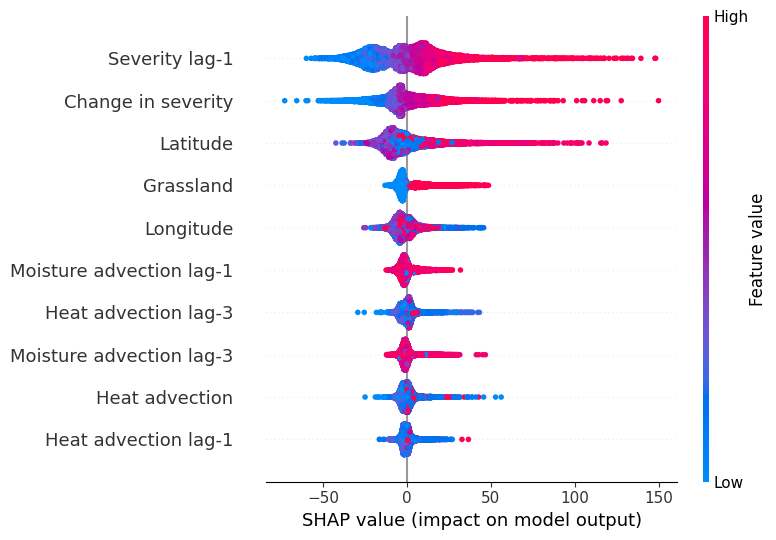

SHAP plots (top 10) and values with pretty labels saved.


In [24]:
# ------------------------------------------------------------
# 13. SHAP ANALYSIS WITH NICE LABELS
# ------------------------------------------------------------
import shap
import matplotlib.pyplot as plt

# Use training data for SHAP (recommended)
X_shap = X_train

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# ---- pretty names for features ----
pretty_names_map = {
    "Severity_lag1": "Severity lag-1",
    "Severity_lag3": "Severity lag-3",
    "Delta_Severity": "Change in severity",
    "Latitude": "Latitude",
    "Longitude": "Longitude",

    "Z500_max_value_1000km": "Z500 (500 hPa, 0–1000 km)",
    "Z500_max_value_1000km_lag1": "Z500 lag-1",
    "Z500_max_value_1000km_lag3": "Z500 lag-3",

    "HeatAdv_max_value_100km": "Heat advection",
    "HeatAdv_max_value_100km_lag1": "Heat advection lag-1",
    "HeatAdv_max_value_100km_lag3": "Heat advection lag-3",

    "MoistAdv_min_value_100km": "Moisture advection",
    "MoistAdv_min_value_100km_lag1": "Moisture advection lag-1",
    "MoistAdv_min_value_100km_lag3": "Moisture advection lag-3",

    "Coupling_max_value_100km": "Land–atmosphere coupling",
    "Coupling_max_value_100km_lag1": "Coupling lag-1",
    "Coupling_max_value_100km_lag3": "Coupling lag-3",

    "AI_median_100km": "Aridity index",
    "AI_median_100km_lag1": "Aridity index lag-1",
    "AI_median_100km_lag3": "Aridity index lag-3",

    "LULC_Category_1": "LULC class 1",
    "LULC_Category_2": "Grassland",
    "LULC_Category_3": "LULC class 3",
    "LULC_Category_4": "LULC class 4",
}

# build label list in the same order as feature_cols
pretty_feature_names = [pretty_names_map.get(f, f) for f in feature_cols]

# --------- SHAP beeswarm: top 10 features ---------
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=pretty_feature_names,
    max_display=10,   # only 10 most important features
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_summary_top10.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# --------- SHAP bar plot (same labels) ---------
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=pretty_feature_names,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "XGB_SHAP_importance_bar_top10.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# --------- save SHAP values with pretty column names ---------
shap_df = pd.DataFrame(shap_values, columns=pretty_feature_names)
shap_df.to_excel(os.path.join(base_dir, "XGB_SHAP_values_top10labels.xlsx"),
                 index=False)

print("SHAP plots (top 10) and values with pretty labels saved.")


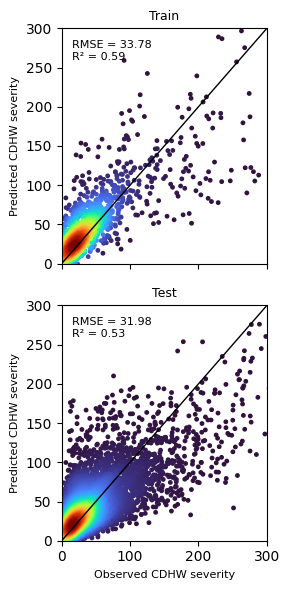

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- 1. get train data from best CV fold ----------
best_fold = cv_results_df.sort_values("R2", ascending=False).iloc[0]["fold"]
train_df  = cv_pred[cv_pred["fold"] == best_fold].copy()

train_obs  = train_df["Severity_obs"].values
train_pred = train_df["Severity_pred"].values

# test data
test_obs  = y_test
test_pred = y_test_pred

# ---------- 2. helper functions ----------
def kde_scatter(ax, x, y):
    """Smooth KDE-colored scatter."""
    xy  = np.vstack([x, y])
    kde = gaussian_kde(xy)(xy)
    idx = kde.argsort()
    x, y, kde = x[idx], y[idx], kde[idx]
    sc = ax.scatter(x, y, c=kde, s=6, cmap='turbo')
    return sc

def metrics(obs, pred):
    rmse = math.sqrt(mean_squared_error(obs, pred))
    r2   = r2_score(obs, pred)
    mae  = mean_absolute_error(obs, pred)
    return rmse, r2, mae

# ---------- 3. plotting ----------
fig, axes = plt.subplots(2, 1, figsize=(3, 6), sharex=True, sharey=True)

# common axis limits
xmin, xmax = 0, 300
ymin, ymax = 0, 300

# ---- TRAIN ----
ax = axes[0]
kde_scatter(ax, train_obs, train_pred)

rmse, r2, mae = metrics(train_obs, train_pred)
ax.plot([xmin, xmax], [xmin, xmax], 'k-', lw=1)

ax.text(0.05, 0.95,
        f"RMSE = {rmse:.2f}\nR² = {r2:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        va="top", ha="left")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Train", fontsize=9)
ax.set_ylabel("Predicted CDHW severity", fontsize=8)

# ---- TEST ----
ax = axes[1]
kde_scatter(ax, test_obs, test_pred)

rmse, r2, mae = metrics(test_obs, test_pred)
ax.plot([xmin, xmax], [xmin, xmax], 'k-', lw=1)

ax.text(0.05, 0.95,
        f"RMSE = {rmse:.2f}\nR² = {r2:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        va="top", ha="left")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Test", fontsize=9)
ax.set_xlabel("Observed CDHW severity", fontsize=8)
ax.set_ylabel("Predicted CDHW severity", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "CDHW_Severity_KDE_Train_Test_MAE.png"),
            dpi=300, bbox_inches="tight")
plt.show()


Total events in cluster 1: 182
Kept with directions SE or E: 89


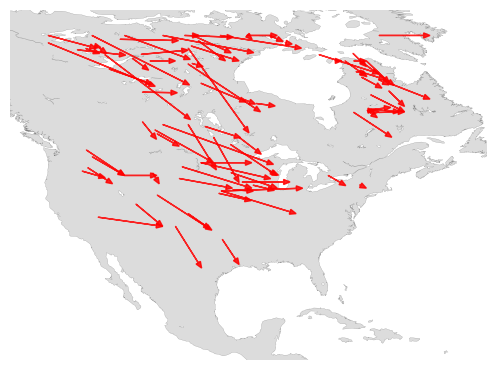

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ======== LOAD FILE ========
file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx"
df = pd.read_excel(file)

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

direction_col = "direction8" if "direction8" in df.columns else "direction4"

# ======== FILTER ========
df = df[df["cluster"] == 1].copy()
df[direction_col] = df[direction_col].astype(str).str.strip().str.upper()

wanted_dirs = ["SE", "E"]
df_keep = df[df[direction_col].isin(wanted_dirs)].copy()

print("Total events in cluster 1:", len(df))
print("Kept with directions SE or E:", len(df_keep))

# ======== PLOT ========
fig, ax = plt.subplots(figsize=(6.5, 3.8))


m = Basemap(
    projection="cyl",
    llcrnrlon=-130, urcrnrlon=-55,   # <- more zoomed out to include Alaska/Greenland side
    llcrnrlat=15,    urcrnrlat=70,
    resolution="l",
    ax=ax
)

# --- Ocean white + land gray (like the 2nd image)
m.drawmapboundary(fill_color="white", linewidth=0)      # no border, white background/ocean
m.fillcontinents(color="gainsboro", lake_color="white")   # gray land, white lakes

# --- subtle coastlines
m.drawcoastlines(linewidth=0.15, color="gray")

# --- arrows: strong red, bigger heads
arrow_color = "red"

for _, row in df_keep.iterrows():
    slon = row["starting longitude"]
    slat = row["starting latitude"]
    elon = row["ending longitude"]
    elat = row["ending latitude"]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    ax.arrow(
        xs, ys, xe - xs, ye - ys,
        length_includes_head=True,
        head_width=0.8,      # bigger arrow head (match 2nd image)
        head_length=1.0,
        linewidth=1.0,       # thicker arrow line
        color=arrow_color,
        alpha=0.85,
        zorder=5
    )

# --- remove plot frame/axes completely
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\NA_SE_vs_E_style2.png",
    dpi=300, transparent=True, bbox_inches="tight"
)
plt.show()


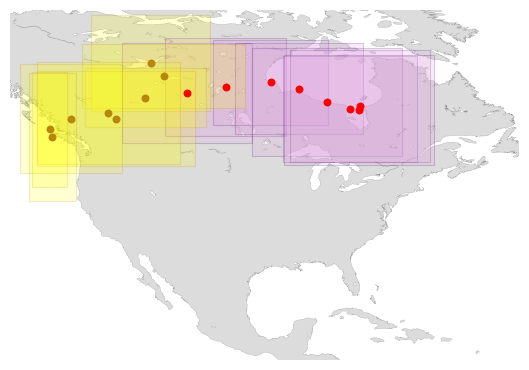

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Cluster0_and_Cluster1_MeanStd_300dpi.png


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Cluster_0_mean_std.xlsx"
mean_file1 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Cluster_1_mean_std.xlsx"

out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Cluster0_and_Cluster1_MeanStd_300dpi.png")

# ============================================================
# 1) READ DATA (CLUSTER 0 + CLUSTER 1)
# ============================================================
df0 = pd.read_excel(mean_file0)
df0 = df0[df0["cluster"] == 0].copy().sort_values("lead_day")

df1 = pd.read_excel(mean_file1)
df1 = df1[df1["cluster"] == 1].copy().sort_values("lead_day")

# ============================================================
# 2) BASEMAP (ONE PLOT FOR BOTH)
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 3.8))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=15,   urcrnrlat=70,
    resolution="l",
    ax=ax
)

m.drawmapboundary(fill_color="white", linewidth=0)
m.fillcontinents(color="gainsboro", lake_color="white")
m.drawcoastlines(linewidth=0.15, color="gray")
ax.set_axis_off()

# ============================================================
# 3) HELPER: PLOT BOXES + POINTS
#    (REMOVE lead_day = 9 and 10)
# ============================================================
def plot_cluster(df, box_face, box_edge, point_color,
                 shrink_factor=0.8, skip_day0=True,
                 point_size=22, box_alpha=0.10, box_lw=0.8):

    lead = df["lead_day"].values
    mlat = df["mean_lat"].values
    mlon = df["mean_lon"].values
    slat = df["std_lat"].values
    slon = df["std_lon"].values

    # ---- boxes
    for ld, lon_c, lat_c, dlon, dlat in zip(lead, mlon, mlat, slon, slat):

        if skip_day0 and ld == 0:
            continue
        if ld in (9, 10):   # <<< REMOVE day 9 & 10
            continue
        if np.isnan(lon_c) or np.isnan(lat_c) or np.isnan(dlon) or np.isnan(dlat):
            continue

        dlon_s = dlon * shrink_factor
        dlat_s = dlat * shrink_factor

        rect = Rectangle(
            (lon_c - dlon_s, lat_c - dlat_s),
            2 * dlon_s,
            2 * dlat_s,
            facecolor=box_face,
            alpha=box_alpha,
            edgecolor=box_edge,
            linewidth=box_lw,
            zorder=2
        )
        ax.add_patch(rect)

    # ---- points
    mask = np.ones_like(lead, dtype=bool)

    if skip_day0:
        mask &= (lead != 0)

    mask &= (~np.isin(lead, [9, 10]))   # <<< REMOVE day 9 & 10

    m.scatter(
        mlon[mask],
        mlat[mask],
        s=point_size,
        c=point_color,
        zorder=10
    )

# ============================================================
# 4) PLOT BOTH CLUSTERS ON SAME MAP
# ============================================================

# Cluster 0 (standing)
plot_cluster(
    df0,
    box_face="plum",
    box_edge="indigo",
    point_color="red",
    shrink_factor=0.9,
    skip_day0=True,
    point_size=22,
    box_alpha=0.20,
    box_lw=0.8
)

# Cluster 1 (propagating)
plot_cluster(
    df1,
    box_face="yellow",
    box_edge="darkgoldenrod",
    point_color="darkgoldenrod",
    shrink_factor=0.9,
    skip_day0=True,
    point_size=22,
    box_alpha=0.18,
    box_lw=0.8
)

# ============================================================
# 5) SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


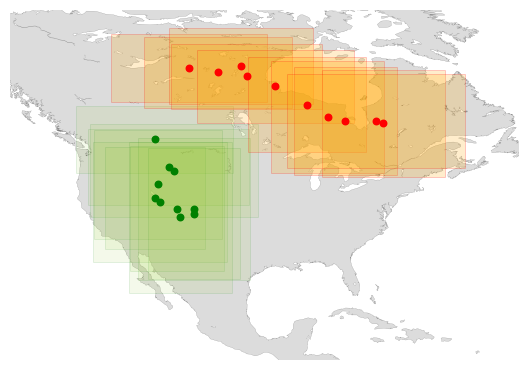

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\CouplingP_Cluster0_Cluster1_Combined_300dpi.png


In [80]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\CouplingP_Cluster_0_mean_std.xlsx"
mean_file1 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\CouplingP_Cluster_1_mean_std.xlsx"

out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "CouplingP_Cluster0_Cluster1_Combined_300dpi.png")

# ============================================================
# READ DATA
# ============================================================
df0 = pd.read_excel(mean_file0)
df0 = df0[df0["cluster"] == 0].copy().sort_values("lead_day")

df1 = pd.read_excel(mean_file1)
df1 = df1[df1["cluster"] == 1].copy().sort_values("lead_day")

# ============================================================
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 3.8))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=15,   urcrnrlat=70,
    resolution="l",
    ax=ax
)

m.drawmapboundary(fill_color="white", linewidth=0)
m.fillcontinents(color="gainsboro", lake_color="white")
m.drawcoastlines(linewidth=0.15, color="gray")
ax.set_axis_off()

# ============================================================
# HELPER FUNCTION
# ============================================================
def plot_cluster(df, box_face, box_edge, point_color,
                 shrink_factor=0.8, skip_day0=True,
                 point_size=22, box_alpha=0.85, box_lw=0.7):

    lead = df["lead_day"].values
    mlat = df["mean_lat"].values
    mlon = df["mean_lon"].values
    slat = df["std_lat"].values
    slon = df["std_lon"].values

    # --- uncertainty boxes
    for ld, lon, lat, dlon, dlat in zip(lead, mlon, mlat, slon, slat):
        if skip_day0 and ld == 0:
            continue
        if np.isnan(lon) or np.isnan(lat) or np.isnan(dlon) or np.isnan(dlat):
            continue

        rect = Rectangle(
            (lon - dlon * shrink_factor, lat - dlat * shrink_factor),
            2 * dlon * shrink_factor,
            2 * dlat * shrink_factor,
            facecolor=box_face,
            edgecolor=box_edge,
            alpha=box_alpha,
            linewidth=box_lw,
            zorder=2
        )
        ax.add_patch(rect)

    # --- mean points
    if skip_day0:
        m.scatter(mlon[1:], mlat[1:], s=point_size, c=point_color, zorder=10)
    else:
        m.scatter(mlon, mlat, s=point_size, c=point_color, zorder=10)

# ============================================================
# PLOT BOTH CLUSTERS
# ============================================================

# Cluster 0 → ORANGE
plot_cluster(
    df0,
    box_face="yellowgreen",
    box_edge="green",
    point_color="green",
    shrink_factor=0.8,
    box_alpha=0.10
)

# Cluster 1 → YELLOW
plot_cluster(
    df1,
    box_face="orange",
    box_edge="red",
    point_color="red",
    shrink_factor=0.9,
    box_alpha=0.2
)

# ============================================================
# SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


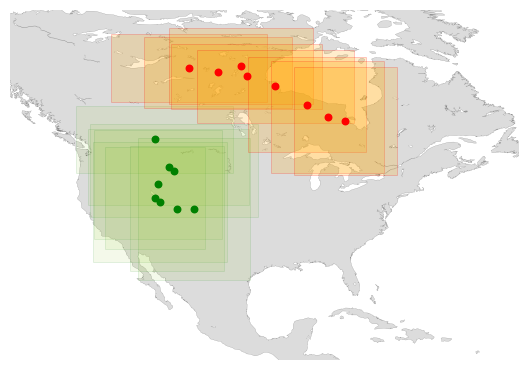

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\CouplingP_Cluster0_Cluster1_Combined_300dpi.png


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\CouplingP_Cluster_0_mean_std.xlsx"
mean_file1 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\CouplingP_Cluster_1_mean_std.xlsx"

out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "CouplingP_Cluster0_Cluster1_Combined_300dpi.png")

# ============================================================
# SETTINGS (KEEP ONLY lead_day = 1..8)
# ============================================================
DAY_MIN = 1
DAY_MAX = 8
SKIP_DAY0 = True

# ============================================================
# READ DATA
# ============================================================
df0 = pd.read_excel(mean_file0)
df0 = df0[df0["cluster"] == 0].copy().sort_values("lead_day").reset_index(drop=True)

df1 = pd.read_excel(mean_file1)
df1 = df1[df1["cluster"] == 1].copy().sort_values("lead_day").reset_index(drop=True)

# ============================================================
# BASEMAP
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 3.8))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=15,   urcrnrlat=70,
    resolution="l",
    ax=ax
)

m.drawmapboundary(fill_color="white", linewidth=0)
m.fillcontinents(color="gainsboro", lake_color="white")
m.drawcoastlines(linewidth=0.15, color="gray")
ax.set_axis_off()

# ============================================================
# HELPER FUNCTION (BOXES + POINTS) ONLY DAYS 1..8
# ============================================================
def plot_cluster(df, box_face, box_edge, point_color,
                 shrink_factor=0.8, skip_day0=True,
                 point_size=22, box_alpha=0.85, box_lw=0.7,
                 day_min=1, day_max=8):

    lead = df["lead_day"].values
    mlat = df["mean_lat"].values
    mlon = df["mean_lon"].values
    slat = df["std_lat"].values
    slon = df["std_lon"].values

    # ---- keep only desired days
    mask = (lead >= day_min) & (lead <= day_max)
    if skip_day0:
        mask &= (lead != 0)

    # --- uncertainty boxes (only desired days)
    for ld, lon, lat, dlon, dlat, keep in zip(lead, mlon, mlat, slon, slat, mask):
        if not keep:
            continue
        if np.isnan(lon) or np.isnan(lat) or np.isnan(dlon) or np.isnan(dlat):
            continue

        rect = Rectangle(
            (lon - dlon * shrink_factor, lat - dlat * shrink_factor),
            2 * dlon * shrink_factor,
            2 * dlat * shrink_factor,
            facecolor=box_face,
            edgecolor=box_edge,
            alpha=box_alpha,
            linewidth=box_lw,
            zorder=2
        )
        ax.add_patch(rect)

    # --- mean points (only desired days)
    x = mlon[mask]
    y = mlat[mask]

    ok = (~np.isnan(x)) & (~np.isnan(y))
    m.scatter(x[ok], y[ok], s=point_size, c=point_color, zorder=10)

# ============================================================
# PLOT BOTH CLUSTERS
# ============================================================

# Cluster 0
plot_cluster(
    df0,
    box_face="yellowgreen",
    box_edge="green",
    point_color="green",
    shrink_factor=0.8,
    box_alpha=0.10,
    box_lw=0.7,
    skip_day0=SKIP_DAY0,
    day_min=DAY_MIN,
    day_max=DAY_MAX
)

# Cluster 1
plot_cluster(
    df1,
    box_face="orange",
    box_edge="red",
    point_color="red",
    shrink_factor=0.9,
    box_alpha=0.20,
    box_lw=0.7,
    skip_day0=SKIP_DAY0,
    day_min=DAY_MIN,
    day_max=DAY_MAX
)

# ============================================================
# SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


In [192]:
import pandas as pd

SCALE = 1e8

# ============================================================
# FILE PATHS (4 FILES)
# ============================================================
standing_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
prop_path     = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"

# ============================================================
# READ DATA
# ============================================================
st = pd.read_excel(standing_path)
pr = pd.read_excel(prop_path)

# Keep ONLY Day 1 & Day 2
st = st[st["day_count"].isin([1, 2])].set_index("day_count")
pr = pr[pr["day_count"].isin([1, 2])].set_index("day_count")

# ============================================================
# DAY-2 − DAY-1 (STANDING)
# ============================================================
standing_heat_diff = (st.loc[2, "heat_p50"] - st.loc[1, "heat_p50"]) * SCALE
standing_moist_diff = (st.loc[2, "moist_p50"] - st.loc[1, "moist_p50"]) * 1000 * SCALE

# ============================================================
# DAY-2 − DAY-1 (PROPAGATING)
# ============================================================
prop_heat_diff = (pr.loc[2, "heat_p50"] - pr.loc[1, "heat_p50"]) * SCALE
prop_moist_diff = (pr.loc[2, "moist_p50"] - pr.loc[1, "moist_p50"]) * 1000 * SCALE

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n===== DAY-2 − DAY-1 DIFFERENCES =====\n")

print("STANDING CASE:")
print(f"  Heat advection difference     : {standing_heat_diff:.3f} ×10⁻⁸ K s⁻¹")
print(f"  Moisture advection difference : {standing_moist_diff:.3f} ×10⁻⁸ g kg⁻¹ s⁻¹\n")

print("PROPAGATING CASE:")
print(f"  Heat advection difference     : {prop_heat_diff:.3f} ×10⁻⁸ K s⁻¹")
print(f"  Moisture advection difference : {prop_moist_diff:.3f} ×10⁻⁸ g kg⁻¹ s⁻¹")



===== DAY-2 − DAY-1 DIFFERENCES =====

STANDING CASE:
  Heat advection difference     : 0.464 ×10⁻⁸ K s⁻¹
  Moisture advection difference : 0.019 ×10⁻⁸ g kg⁻¹ s⁻¹

PROPAGATING CASE:
  Heat advection difference     : -0.012 ×10⁻⁸ K s⁻¹
  Moisture advection difference : -0.308 ×10⁻⁸ g kg⁻¹ s⁻¹


In [191]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance (km)"""
    R = 6371.0  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(math.radians,
                                 [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (math.sin(dlat / 2)**2 +
         math.cos(lat1) * math.cos(lat2) *
         math.sin(dlon / 2)**2)

    c = 2 * math.asin(math.sqrt(a))
    return R * c


# =====================================================
# CASE 1: Point-1 ↔ Point-2
# =====================================================
case1_p1 = (61.25, -116.25)
case1_p2 = (61.6666666666667, -112.916666666667)

dist_case1 = haversine_distance(
    case1_p1[0], case1_p1[1],
    case1_p2[0], case1_p2[1]
)

print("CASE 1")
print(f"Point 1: {case1_p1}")
print(f"Point 2: {case1_p2}")
print(f"Distance: {dist_case1:.2f} km\n")


# =====================================================
# CASE 2: Point-1 ↔ Point-2
# =====================================================
case2_p1 = (59.0277777777778, -110.833333333333)
case2_p2 = (56.9444444444444, -107.222222222222)

dist_case2 = haversine_distance(
    case2_p1[0], case2_p1[1],
    case2_p2[0], case2_p2[1]
)

print("CASE 2")
print(f"Point 1: {case2_p1}")
print(f"Point 2: {case2_p2}")
print(f"Distance: {dist_case2:.2f} km")


CASE 1
Point 1: (61.25, -116.25)
Point 2: (61.6666666666667, -112.916666666667)
Distance: 183.03 km

CASE 2
Point 1: (59.0277777777778, -110.833333333333)
Point 2: (56.9444444444444, -107.222222222222)
Distance: 314.52 km
